# Channel Combinations with 6 Channels from LOO Test



## Imports

In [1]:
%pip install -q numpy pandas scikit-learn matplotlib torch

import os, re
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.model_selection import GroupShuffleSplit, LeaveOneGroupOut

# Run the mvnx_file_reader.ipynb to load MVNX files
%run mvnx_file_reader.ipynb


Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Segment labels: ['Pelvis', 'L5', 'L3', 'T12', 'T8', 'Neck', 'Head', 'RightShoulder', 'RightUpperArm', 'RightForeArm', 'RightHand', 'LeftShoulder', 'LeftUpperArm', 'LeftForeArm', 'LeftHand', 'RightUpperLeg', 'RightLowerLeg', 'RightFoot', 'RightToe', 'LeftUpperLeg', 'LeftLowerLeg', 'LeftFoot', 'LeftToe']
Segment IDs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
RightHand positions (first 5 frames): [[0.000326, -0.7332, 1.53858], [0.007659, -0.732989, 1.535369], [0.007659, -0.732989, 1.535369], [5.256316, 1.154359, 0.728047], [5.256684, 1.155001, 0.728414]]
normal
Data types: ['time', 'index', 'tc', 'ms', 'type', 'orientation', 'position', 'velocity', 'acceleration', 'angularVelocity', 'angularAcceleration', 'contacts', 'sensorFreeAcceleration'

### Globals

In [ ]:
# 10 ADL selection
TASK_TO_LABEL = { # U-Limb dataset has 30 total, we're only using 10 of them for this project
    11: "lift_suitcase_to_floor",
    12: "drink_from_glass",
    13: "answer_phone",
    16: "eat_apple",
    20: "use_key_unlock",
    21: "pour_water",
    23: "brush_teeth",
    24: "open_laptop",
    28: "open_door",
    29: "place_ball_in_basket",
}

ALLOWED_TASKS = set(TASK_TO_LABEL.keys())

LEFT_LIMB_SEGS  = ["LeftUpperArm", "LeftForeArm", "LeftHand", "LeftShoulder"]
RIGHT_LIMB_SEGS = ["RightUpperArm", "RightForeArm", "RightHand", "RightShoulder"]

def segments_for_tested_limb(limb: str):
    limb = str(limb).upper()
    return LEFT_LIMB_SEGS if limb == "L" else RIGHT_LIMB_SEGS

# You'll have to change the DATA_ROOT variable to point to where you have the data stored on your computer.
# The notebook should be in the same folder as the data, so a relative path should work.
DATA_ROOT = "ULF_in_ADL"
# DATA_ROOT = "D:/UZH_data/ULF_in_ADL"

CHANNELS = [ # change this to change which channels are used for the model
    "velocity",
    "angularVelocity",
    "jointAngle",
    "jointAngleXZY",
    "acceleration",
    "sensorFreeAcceleration",
]

WIN_LEN_S = 4.0  # seconds
STEP_S = 0.5     # seconds

# Sweep settings kept only for optional later use; they are not used by the single-run baseline cell.
SWEEP_WINDOW_LENGTHS = [WIN_LEN_S]
SWEEP_STEP_SIZES = [STEP_S]
MIN_OVERLAP_FRACTION = 0.50

# Cache settings
CACHE_DIR = "cached_datasets"
USE_DATASET_CACHE = True
FORCE_REBUILD_DATASET = False

# Result saving
RESULTS_DIR = "experiment_results"
RESULTS_BASENAME = "channel_combo_ablation"

# Training settings
BATCH_SIZE_TRAIN = 128
BATCH_SIZE_EVAL = 256
EPOCHS = 20
LR = 1e-4
WEIGHT_DECAY = 1e-4
DROPOUT = 0.2
KERNEL_SIZE = 5
TCN_CHANNELS = (64, 64, 128, 128)

# Early stopping
EARLY_STOPPING_PATIENCE = 5
EARLY_STOPPING_MIN_DELTA = 0.002
VAL_SIZE = 0.20
RANDOM_STATE = 42

# LOSO evaluation settings
LOSO_MAX_FOLDS = None  # Set to an integer like 4 for a quick pilot run, or keep None for all subjects
PLOT_FIRST_FOLD_CURVES = True
SAVE_PER_FOLD_CSV = True


### File Helpers

Helper functions to find files, parse task from filename, and extract per-segment vectors

In [3]:
# Helper functions to find and parse MVNX files
def iter_mvnx_files(root: str):
    for r, _, files in os.walk(root):
        for fn in files:
            if fn.lower().endswith(".mvnx"):
                yield os.path.join(r, fn)

# Parses participant, task, limb, and rep from filename
def parse_meta_from_filename(filepath: str):
    """
    Expected example: H01_T01_L1.mvnx OR P02_T15_R3.mvnx
    Returns dict: participant, task(int), limb('L'/'R'), rep(int)
    """
    base = os.path.basename(filepath)

    m = re.match(r"^(?P<participant>[A-Za-z]\d{2})_T(?P<task>\d{2})_(?P<limb>[LRlr])(?P<rep>\d)\.mvnx$", base)
    if not m:
        return None

    participant = m.group("participant")
    task = int(m.group("task"))
    limb = m.group("limb").upper()
    rep = int(m.group("rep"))
    return {"participant": participant, "task": task, "limb": limb, "rep": rep}


# Functions to extract frame rate and channel data from MVNX dicts
def get_frame_rate_hz(mvnx_dict) -> float:
    # MVNX stores it on subject
    fr = mvnx_dict["mvnx"]["subject"].get("frameRate", None)
    if fr is None:
        raise ValueError("frameRate not found in mvnx['mvnx']['subject']")
    return float(fr)

def _as_list(x):
    if isinstance(x, list):
        return x
    if x is None:
        return []
    return [x]

def build_segment_index_map(mvnx_dict):
    segments = _as_list(mvnx_dict["mvnx"]["subject"]["segments"]["segment"])
    return {seg["label"]: i for i, seg in enumerate(segments)}

def build_sensor_index_map(mvnx_dict):
    sensors = _as_list(mvnx_dict["mvnx"]["subject"]["sensors"]["sensor"])
    return {sensor["label"]: i for i, sensor in enumerate(sensors)}

def build_joint_index_map(mvnx_dict):
    joints = _as_list(mvnx_dict["mvnx"]["subject"]["joints"]["joint"])
    return {joint["label"]: i for i, joint in enumerate(joints)}

SEGMENT_CHANNEL_SPECS = {
    "orientation": (build_segment_index_map, 4),
    "position": (build_segment_index_map, 3),
    "velocity": (build_segment_index_map, 3),
    "acceleration": (build_segment_index_map, 3),
    "angularVelocity": (build_segment_index_map, 3),
    "angularAcceleration": (build_segment_index_map, 3),
}

SENSOR_CHANNEL_SPECS = {
    "sensorFreeAcceleration": (build_sensor_index_map, 3),
    "sensorMagneticField": (build_sensor_index_map, 3),
    "sensorOrientation": (build_sensor_index_map, 4),
}

# For joint channels we map each tested segment to the most relevant joint on that limb.
JOINT_CHANNEL_SPECS = {
    "jointAngle": 3,
    "jointAngleXZY": 3,
}

LEFT_SEGMENT_TO_JOINT = {
    "LeftShoulder": "jLeftT4Shoulder",
    "LeftUpperArm": "jLeftShoulder",
    "LeftForeArm": "jLeftElbow",
    "LeftHand": "jLeftWrist",
}

RIGHT_SEGMENT_TO_JOINT = {
    "RightShoulder": "jRightT4Shoulder",
    "RightUpperArm": "jRightShoulder",
    "RightForeArm": "jRightElbow",
    "RightHand": "jRightWrist",
}

def get_segment_joint_label(segment_label: str, limb: str) -> str:
    limb = str(limb).upper()
    mapping = LEFT_SEGMENT_TO_JOINT if limb == "L" else RIGHT_SEGMENT_TO_JOINT
    if segment_label not in mapping:
        raise KeyError(f"No joint mapping defined for segment '{segment_label}' on limb '{limb}'.")
    return mapping[segment_label]

def _slice_labeled_vector(mvnx_dict, frame_dict, channel: str, label: str, index_builder, components: int) -> np.ndarray:
    label_map = index_builder(mvnx_dict)
    if label not in label_map:
        raise KeyError(f"Label '{label}' not found for channel '{channel}'. Available labels include: {list(label_map)[:8]} ...")

    vec = frame_dict.get(channel, None)
    if vec is None:
        raise KeyError(f"Channel '{channel}' not found in this frame.")

    arr = np.asarray(vec, dtype=np.float32).ravel()
    idx = label_map[label]
    start = components * idx
    end = start + components

    if end > arr.size:
        raise ValueError(
            f"Channel '{channel}' with label '{label}' expected slice [{start}:{end}] "
            f"but frame only has {arr.size} values."
        )
    return arr[start:end]

def get_channel_vector(mvnx_dict, frame_dict, segment_label: str, channel: str, limb: str) -> np.ndarray:
    """
    Channel-aware extractor.

    Uses:
    - segment indexing for segment-level channels
    - sensor indexing for sensor-level channels
    - joint indexing for joint-angle channels
    """
    if channel in SEGMENT_CHANNEL_SPECS:
        index_builder, components = SEGMENT_CHANNEL_SPECS[channel]
        return _slice_labeled_vector(mvnx_dict, frame_dict, channel, segment_label, index_builder, components)

    if channel in SENSOR_CHANNEL_SPECS:
        index_builder, components = SENSOR_CHANNEL_SPECS[channel]
        return _slice_labeled_vector(mvnx_dict, frame_dict, channel, segment_label, index_builder, components)

    if channel in JOINT_CHANNEL_SPECS:
        joint_label = get_segment_joint_label(segment_label, limb)
        components = JOINT_CHANNEL_SPECS[channel]
        return _slice_labeled_vector(mvnx_dict, frame_dict, channel, joint_label, build_joint_index_map, components)

    raise KeyError(
        f"Unsupported channel '{channel}'. Add it to SEGMENT_CHANNEL_SPECS, "
        f"SENSOR_CHANNEL_SPECS, or JOINT_CHANNEL_SPECS."
    )

# Only keep frames where type="normal" (some files have "calibration" frames at the start that we want to ignore)
def only_normal_frames(mvnx: dict) -> list[dict]:
    frames = mvnx["mvnx"]["subject"]["frames"]["frame"]
    if isinstance(frames, dict):
        frames = [frames]
    return [fr for fr in frames if str(fr.get("type", "")).lower() == "normal"]

# Generator for start/end indices of sliding windows over N samples
def window_indices(n_samples: int, win_len: int, step: int):
    s = 0
    while s + win_len <= n_samples:
        yield s, s + win_len
        s += step


In [4]:
# quick test
sample_paths = list(iter_mvnx_files(DATA_ROOT))[:5]
print("Found files (sample):")
for p in sample_paths:
    print(" ", os.path.basename(p), parse_meta_from_filename(p))

Found files (sample):
  P17_T02_L3.mvnx {'participant': 'P17', 'task': 2, 'limb': 'L', 'rep': 3}
  P17_T24_L2.mvnx {'participant': 'P17', 'task': 24, 'limb': 'L', 'rep': 2}
  P17_T28_R3.mvnx {'participant': 'P17', 'task': 28, 'limb': 'R', 'rep': 3}
  P17_T26_L1.mvnx {'participant': 'P17', 'task': 26, 'limb': 'L', 'rep': 1}
  P17_T01_L3.mvnx {'participant': 'P17', 'task': 1, 'limb': 'L', 'rep': 3}


Helpers for mvnx frame/channel extractions

In [5]:
# Build windows for one file, returning X_win (num_windows, win_len, num_channels), y_win (num_windows,), g_win (num_windows,)
def windows_file_cnn(filepath: str, win_len_s, step_s, channels=None):

    if channels is None:
        channels = CHANNELS

    meta = parse_meta_from_filename(filepath)
    if meta is None or meta["task"] not in ALLOWED_TASKS:
        return None

    mvnx = load_mvnx(filepath)
    frames = only_normal_frames(mvnx)
    if len(frames) < 10:
        return None

    frame_rate = float(mvnx["mvnx"]["subject"].get("frameRate", 0))
    win_len = max(int(round(win_len_s * frame_rate)), 5)
    step = max(int(round(step_s * frame_rate)), 1)

    segments = segments_for_tested_limb(meta["limb"])
    N = len(frames)

    # Precompute channel arrays for each segment. The feature width depends on channel type:
    # xyz channels -> 3, quaternion channels -> 4.
    data = {}
    feature_dims = {}
    for seg in segments:
        for ch in channels:
            first_vec = get_channel_vector(mvnx, frames[0], seg, ch, meta["limb"])
            D = int(np.asarray(first_vec).size)
            arr = np.zeros((N, D), dtype=np.float32)
            arr[0] = first_vec
            for i in range(1, N):
                arr[i] = get_channel_vector(mvnx, frames[i], seg, ch, meta["limb"])
            data[(ch, seg)] = arr
            feature_dims[(ch, seg)] = D

    X_win, y_win, g_win = [], [], []
    for a, b in window_indices(N, win_len, step):
        cols = []
        for seg in segments:
            for ch in channels:
                cols.append(data[(ch, seg)][a:b])   # (T,D)
        Xw = np.concatenate(cols, axis=1)          # (T, C_total)
        X_win.append(Xw)
        y_win.append(TASK_TO_LABEL[meta["task"]])
        g_win.append(meta["participant"])

    if not X_win:
        return None

    return np.stack(X_win, axis=0), np.array(y_win), np.array(g_win)


## Building Dataset
Building a fixed post-window-study dataset for the all-channel baseline at 4.0 s window and 0.5 s step.


In [6]:
# Dataset caching helpers
def _safe_name(txt: str) -> str:
    txt = str(txt)
    txt = re.sub(r"[^A-Za-z0-9_.-]+", "-", txt)
    return txt.strip("-") or "default"

def make_dataset_cache_path(root: str, channels, win_len_s: float, step_s: float, allowed_tasks=None, cache_dir: str = CACHE_DIR):
    os.makedirs(cache_dir, exist_ok=True)

    root_name = _safe_name(os.path.basename(os.path.normpath(root)) or "dataset")
    channel_name = _safe_name("_".join(channels))
    task_name = "alltasks" if allowed_tasks is None else _safe_name("-".join(map(str, sorted(allowed_tasks))))

    filename = (
        f"dataset_{root_name}"
        f"__ch-{channel_name}"
        f"__win-{win_len_s:g}s"
        f"__step-{step_s:g}s"
        f"__tasks-{task_name}.npz"
    )
    return os.path.join(cache_dir, filename)

# Build the full dataset by iterating over all files and concatenating results
def build_dataset(root: str, win_len_s, step_s, channels=None):
    if channels is None:
        channels = CHANNELS

    X_list, y_list, g_list = [], [], []
    kept = 0
    skipped = 0

    for fp in iter_mvnx_files(root):
        meta = parse_meta_from_filename(fp)
        if meta is None:
            continue
        if meta["task"] not in ALLOWED_TASKS:
            continue

        try:
            out = windows_file_cnn(fp, win_len_s=win_len_s, step_s=step_s, channels=channels)
        except Exception as e:
            skipped += 1
            print(f"Skipping {os.path.basename(fp)} due to extraction/build error: {e}")
            continue

        if out is None:
            skipped += 1
            continue

        Xw, yw, gw = out
        X_list.append(Xw)
        y_list.append(yw)
        g_list.append(gw)
        kept += 1

    if not X_list:
        raise RuntimeError("No windows were built. Check parsing/task filters/DATA_ROOT.")

    X = np.concatenate(X_list, axis=0)   # (N, T, C)
    y = np.concatenate(y_list, axis=0)   # (N,)
    g = np.concatenate(g_list, axis=0)   # (N,)

    print(f"Kept files: {kept} | Skipped files (allowed but failed): {skipped}")
    print("X:", X.shape, "y:", y.shape, "groups:", g.shape)

    return X, y, g

def load_or_build_dataset(root: str, win_len_s, step_s, channels, use_cache=True, force_rebuild=False):
    cache_path = make_dataset_cache_path(
        root=root,
        channels=channels,
        win_len_s=win_len_s,
        step_s=step_s,
        allowed_tasks=ALLOWED_TASKS,
        cache_dir=CACHE_DIR,
    )

    if use_cache and os.path.exists(cache_path) and not force_rebuild:
        print(f"Loading cached dataset from: {cache_path}")
        cached = np.load(cache_path, allow_pickle=True)
        X = cached["X"]
        y = cached["y"]
        g = cached["groups"]
        return X, y, g, cache_path

    print("No cached dataset found. Building dataset from MVNX files...")
    X, y, g = build_dataset(root, win_len_s=win_len_s, step_s=step_s, channels=channels)

    if use_cache:
        np.savez_compressed(
            cache_path,
            X=X.astype(np.float32),
            y=y,
            groups=g,
            channels=np.array(channels, dtype=object),
            win_len_s=np.array([win_len_s], dtype=np.float32),
            step_s=np.array([step_s], dtype=np.float32),
        )
        print(f"Saved dataset cache to: {cache_path}")

    return X, y, g, cache_path

def summarize_dataset(X, y, groups, prefix="All-11-channel run"):
    print(f"{prefix} dataset loaded.")
    print("Dataset shape:", X.shape)
    print("Unique subjects:", len(set(groups)))
    vals, cnts = np.unique(y, return_counts=True)
    print("Class counts:", dict(zip(vals, cnts)))
    print("Example window shape (T,C):", X[0].shape)


### Normalization

Different normalization from SVM

In [7]:
# IMPORTANT:
# Do NOT normalize before LOSO splitting. That would let the held-out subject
# influence scaling. Instead, fit normalization on the training fold only and
# apply it to val/test inside each fold.

def fit_channel_zscore(X: np.ndarray, eps: float = 1e-8):
    """
    Fit one global z-score per feature channel using TRAINING WINDOWS ONLY.

    X: (N, T, C)
    Returns:
        mu: (C,)
        sd: (C,)
    """
    pooled = X.reshape(-1, X.shape[-1]).astype(np.float32)
    mu = pooled.mean(axis=0)
    sd = pooled.std(axis=0)
    sd = np.maximum(sd, eps)
    return mu, sd

def apply_channel_zscore(X: np.ndarray, mu: np.ndarray, sd: np.ndarray) -> np.ndarray:
    """Apply pre-fit channel-wise z-score to (N, T, C)."""
    return ((X.astype(np.float32) - mu) / sd).astype(np.float32)

print("Normalization helpers defined.")
print("Dataset arrays (X, y, groups) are loaded later inside run_windowing_study()")
print("via load_or_build_dataset(...), one window/step configuration at a time.")


Normalization helpers defined.
Dataset arrays (X, y, groups) are loaded later inside run_windowing_study()
via load_or_build_dataset(...), one window/step configuration at a time.


### Note on dataset creation and caching


This notebook evaluates all non-empty combinations of the six channels identified as informative in the preceding leave-one-channel-out study. The window length and step size are fixed at 4.0 s and 0.5 s.

With six candidate channels, 63 channel combinations are evaluated in total, ranging from single-channel models to the full six-channel model. Each channel combination is evaluated independently using the same LOSO TCN framework.


## Train and Evaluate



Train/test split by subject and encode labels

In [8]:
from sklearn.model_selection import GroupShuffleSplit, LeaveOneGroupOut
import hashlib
from collections import defaultdict
from itertools import product
from datetime import datetime

def encode_labels(y: np.ndarray):
    labels = sorted(list(set(y)))
    lab2i = {lab:i for i, lab in enumerate(labels)}
    i2lab = {i:lab for lab,i in lab2i.items()}
    y_i = np.array([lab2i[v] for v in y], dtype=np.int64)
    return labels, lab2i, i2lab, y_i

def make_grouped_train_val_split(groups_train: np.ndarray, val_size: float = VAL_SIZE, random_state: int = RANDOM_STATE):
    """
    Creates a validation split using training subjects only.
    This is used INSIDE each LOSO fold for early stopping.
    """
    unique_subjects = np.unique(groups_train)

    if len(unique_subjects) < 2:
        raise ValueError("Need at least 2 training subjects to create a validation split.")

    if len(unique_subjects) == 2:
        # Fallback: keep one subject for train and one for validation
        val_subject = unique_subjects[-1]
        val_idx = np.where(groups_train == val_subject)[0]
        train_idx = np.where(groups_train != val_subject)[0]
        return train_idx, val_idx

    gss_val = GroupShuffleSplit(n_splits=1, test_size=val_size, random_state=random_state)
    train_idx, val_idx = next(gss_val.split(np.zeros(len(groups_train)), groups=groups_train))
    return train_idx, val_idx

def hash_array(a: np.ndarray) -> str:
    h = hashlib.md5()
    h.update(a.tobytes())
    return h.hexdigest()

def report_split_integrity(name_a, X_a, g_a, idx_a, name_b, X_b, g_b, idx_b):
    overlap = set(g_a) & set(g_b)
    if overlap:
        print(f"WARNING: Subject(s) in both {name_a} and {name_b}: {overlap}")
    else:
        print(f"No subject overlap detected between {name_a} and {name_b}.")

    hashes_a = {hash_array(X_a[i]): idx_a[i] for i in range(len(X_a))}
    hashes_b = {hash_array(X_b[i]): idx_b[i] for i in range(len(X_b))}
    common = set(hashes_a.keys()) & set(hashes_b.keys())
    print(f"Identical windows in {name_a}/{name_b}: {len(common)}")
    if common:
        for h in list(common)[:5]:
            print(f"Example identical window - {name_a} idx: {hashes_a[h]} | {name_b} idx: {hashes_b[h]}")

def build_loso_splits(X, y_i, groups, max_folds=None):
    logo = LeaveOneGroupOut()
    all_loso_splits = list(logo.split(X, y_i, groups=groups))
    if max_folds is not None:
        all_loso_splits = all_loso_splits[:max_folds]
    return all_loso_splits

def window_overlap_fraction(win_len_s: float, step_s: float) -> float:
    return 1.0 - (step_s / win_len_s)

def is_valid_window_step_combo(win_len_s: float, step_s: float, min_overlap_fraction: float = MIN_OVERLAP_FRACTION) -> bool:
    if step_s <= 0 or win_len_s <= 0:
        return False
    if step_s > win_len_s:
        return False
    return window_overlap_fraction(win_len_s, step_s) >= min_overlap_fraction

def make_windowing_grid(window_lengths=None, step_sizes=None, min_overlap_fraction: float = MIN_OVERLAP_FRACTION):
    window_lengths = SWEEP_WINDOW_LENGTHS if window_lengths is None else window_lengths
    step_sizes = SWEEP_STEP_SIZES if step_sizes is None else step_sizes

    combos = []
    for win_len_s, step_s in product(window_lengths, step_sizes):
        overlap = window_overlap_fraction(win_len_s, step_s)
        if is_valid_window_step_combo(win_len_s, step_s, min_overlap_fraction=min_overlap_fraction):
            combos.append({
                "win_len_s": float(win_len_s),
                "step_s": float(step_s),
                "overlap_fraction": float(overlap),
            })
        else:
            print(f"Skipping invalid combo: win={win_len_s}, step={step_s}, overlap={overlap:.3f}")
    return combos

def ensure_results_dir(results_dir: str = RESULTS_DIR):
    os.makedirs(results_dir, exist_ok=True)
    return results_dir

def make_results_stem(study_name: str, win_len_s: float, step_s: float, results_dir: str = RESULTS_DIR):
    ensure_results_dir(results_dir)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    study_name = _safe_name(study_name)
    return os.path.join(results_dir, f"{study_name}__win-{win_len_s:g}s__step-{step_s:g}s__{timestamp}")


Simple TCN dataset and model


In [9]:
import copy
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
import matplotlib.pyplot as plt

class WindowDataset(Dataset):
    def __init__(self, X, y_int):
        # Convert (N, T, C) -> (N, C, T) for Conv1d
        self.X = torch.tensor(np.transpose(X, (0, 2, 1)), dtype=torch.float32)
        self.y = torch.tensor(y_int, dtype=torch.long)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class Chomp1d(nn.Module):
    """
    Removes the extra right-side padding so the convolution is causal:
    output[t] depends only on x[:t].
    """
    def __init__(self, chomp_size):
        super().__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        if self.chomp_size == 0:
            return x
        return x[:, :, :-self.chomp_size].contiguous()

class TemporalBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation, dropout=0.2):
        super().__init__()
        padding = (kernel_size - 1) * dilation  # causal

        self.net = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size,
                      padding=padding, dilation=dilation),
            Chomp1d(padding),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Conv1d(out_channels, out_channels, kernel_size,
                      padding=padding, dilation=dilation),
            Chomp1d(padding),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        self.downsample = nn.Conv1d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else None
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.net(x)
        res = x if self.downsample is None else self.downsample(x)
        return self.relu(out + res)

class SimpleTCN(nn.Module):
    def __init__(self, in_channels, n_classes, channels=TCN_CHANNELS, kernel_size=KERNEL_SIZE, dropout=DROPOUT):
        super().__init__()

        layers = []
        prev_channels = in_channels
        for i, out_channels in enumerate(channels):
            dilation = 2 ** i
            layers.append(
                TemporalBlock(
                    in_channels=prev_channels,
                    out_channels=out_channels,
                    kernel_size=kernel_size,
                    dilation=dilation,
                    dropout=dropout,
                )
            )
            prev_channels = out_channels

        self.tcn = nn.Sequential(*layers)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Linear(prev_channels, n_classes)

    def forward(self, x):
        z = self.tcn(x)
        z = self.pool(z).squeeze(-1)
        return self.classifier(z)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

def make_loaders(X_train, y_train_i, X_val, y_val_i, X_test, y_test_i):
    train_ds = WindowDataset(X_train, y_train_i)
    val_ds   = WindowDataset(X_val, y_val_i)
    test_ds  = WindowDataset(X_test, y_test_i)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE_TRAIN, shuffle=True, drop_last=False)
    val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE_EVAL, shuffle=False, drop_last=False)
    test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE_EVAL, shuffle=False, drop_last=False)

    return train_ds, val_ds, test_ds, train_loader, val_loader, test_loader

def build_model_and_training_objects(in_channels: int, y_train_i: np.ndarray):
    model = SimpleTCN(
        in_channels=in_channels,
        n_classes=len(labels),
    ).to(device)

    counts = np.bincount(y_train_i, minlength=len(labels)).astype(np.float32)
    w = counts.sum() / (counts + 1e-6)
    w = w / w.mean()
    criterion = nn.CrossEntropyLoss(weight=torch.tensor(w, dtype=torch.float32).to(device))
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    return model, criterion, optimizer

def eval_model(model, loader):
    model.eval()
    ys, ps = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            logits = model(xb)
            pred = torch.argmax(logits, dim=1).cpu().numpy()
            ps.append(pred)
            ys.append(yb.numpy())
    y_true = np.concatenate(ys)
    y_pred = np.concatenate(ps)
    return y_true, y_pred

def run_eval_loss_acc(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    ys, ps = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * xb.size(0)

            pred = torch.argmax(logits, dim=1)
            ys.append(yb.cpu().numpy())
            ps.append(pred.cpu().numpy())

    y_true = np.concatenate(ys)
    y_pred = np.concatenate(ps)
    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(y_true, y_pred)
    return avg_loss, acc

print("TCN classes and helper functions are ready.")


Using device: cuda
TCN classes and helper functions are ready.


### Train and evaluate


####################################################################################################
RUNNING CHANNEL COMBINATION SWEEP
Fixed window length: 4s
Fixed step size: 0.5s
Candidate channels (6): ['velocity', 'angularVelocity', 'jointAngle', 'jointAngleXZY', 'acceleration', 'sensorFreeAcceleration']
Combination sizes: 1 to 6
Total combinations to run: 63

Channel combo run 1/63
Using 1 channel(s): ['velocity']
No cached dataset found. Building dataset from MVNX files...
Kept files: 1420 | Skipped files (allowed but failed): 88
X: (14521, 240, 12) y: (14521,) groups: (14521,)
Saved dataset cache to: cached_datasets/dataset_ULF_in_ADL__ch-velocity__win-4s__step-0.5s__tasks-11-12-13-16-20-21-23-24-28-29.npz
Channel combo (1): velocity dataset loaded.
Dataset shape: (14521, 240, 12)
Unique subjects: 25
Class counts: {np.str_('answer_phone'): np.int64(883), np.str_('brush_teeth'): np.int64(1313), np.str_('drink_from_glass'): np.int64(1148), np.str_('eat_apple'): np.int64(580), np.

,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
0,1,H01,4.0,0.5,0.875,10981,2987,553,19,5,15,0.738868,0.837251,0.814618
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,11,0.699145,0.808271,0.762021
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,20,0.749847,0.913349,0.906805
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,20,0.746487,0.927007,0.827251
4,5,H05,4.0,0.5,0.875,10888,3274,359,19,5,20,0.757178,0.782730,0.725076
5,6,P02,4.0,0.5,0.875,10563,3274,684,19,5,14,0.718082,0.821637,0.823388
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,17,0.749847,0.902375,0.853865
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,16,0.723580,0.861940,0.845029
8,9,P05,4.0,0.5,0.875,9883,3274,1364,19,5,17,0.744655,0.323314,0.315587
9,10,P06,4.0,0.5,0.875,9883,3758,880,19,5,17,0.650878,0.729545,0.716957



LOSO SUMMARY
Overall window-level accuracy: 0.7360
Overall window-level macro F1: 0.7101
Mean fold accuracy: 0.7706 ± 0.1642
Mean fold macro F1: 0.7296 ± 0.1764

Per-fold results:


,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,20,0.746487,0.927007,0.827251
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,20,0.749847,0.913349,0.906805
23,24,P29,4.0,0.5,0.875,10705,3408,408,19,5,16,0.656397,0.911765,0.940269
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,17,0.749847,0.902375,0.853865
16,17,P19,4.0,0.5,0.875,10184,4093,244,19,5,16,0.654532,0.901639,0.648499
18,19,P21,4.0,0.5,0.875,10500,3525,496,19,5,10,0.604255,0.899194,0.893914
12,13,P10,4.0,0.5,0.875,10012,4093,416,19,5,18,0.634498,0.867788,0.877737
21,22,P25,4.0,0.5,0.875,10625,3408,488,19,5,20,0.638791,0.864754,0.868741
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,16,0.723580,0.861940,0.845029
20,21,P24,4.0,0.5,0.875,10512,3408,601,19,5,18,0.653756,0.848586,0.801139



Classification report across all LOSO test folds:
                        precision    recall  f1-score   support

          answer_phone      0.759     0.627     0.687       883
           brush_teeth      0.735     0.621     0.673      1313
      drink_from_glass      0.723     0.770     0.746      1148
             eat_apple      0.730     0.559     0.633       580
lift_suitcase_to_floor      0.891     0.792     0.838       917
             open_door      0.559     0.823     0.666       485
           open_laptop      0.806     0.821     0.813      2781
  place_ball_in_basket      0.729     0.715     0.722       467
            pour_water      0.825     0.756     0.789      4606
        use_key_unlock      0.449     0.660     0.535      1341

              accuracy                          0.736     14521
             macro avg      0.720     0.714     0.710     14521
          weighted avg      0.755     0.736     0.741     14521



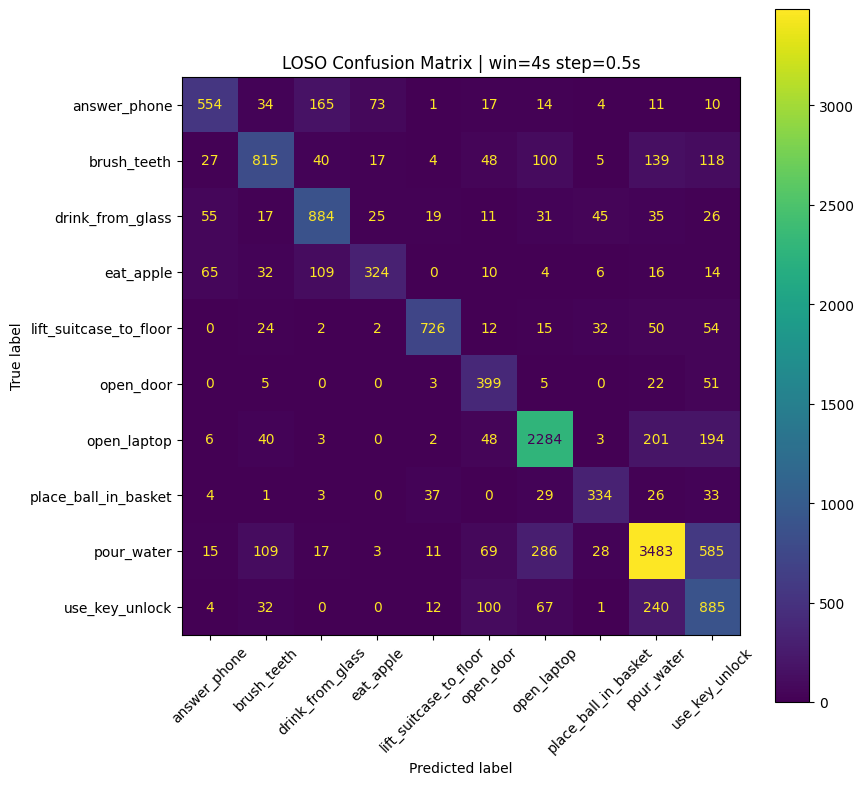

Saved summary CSV: experiment_results/channel_combo_ablation__combo__n-1__velocity__win-4s__step-0.5s__20260403_162911__summary.csv
Saved per-fold CSV: experiment_results/channel_combo_ablation__combo__n-1__velocity__win-4s__step-0.5s__20260403_162911__folds.csv

Channel combo run 2/63
Using 1 channel(s): ['angularVelocity']
No cached dataset found. Building dataset from MVNX files...
Kept files: 1420 | Skipped files (allowed but failed): 88
X: (14521, 240, 12) y: (14521,) groups: (14521,)
Saved dataset cache to: cached_datasets/dataset_ULF_in_ADL__ch-angularVelocity__win-4s__step-0.5s__tasks-11-12-13-16-20-21-23-24-28-29.npz
Channel combo (1): angularVelocity dataset loaded.
Dataset shape: (14521, 240, 12)
Unique subjects: 25
Class counts: {np.str_('answer_phone'): np.int64(883), np.str_('brush_teeth'): np.int64(1313), np.str_('drink_from_glass'): np.int64(1148), np.str_('eat_apple'): np.int64(580), np.str_('lift_suitcase_to_floor'): np.int64(917), np.str_('open_door'): np.int64(485),

,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
0,1,H01,4.0,0.5,0.875,10981,2987,553,19,5,20,0.819886,0.860759,0.828751
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,13,0.791998,0.962406,0.952181
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,20,0.824985,0.955504,0.946356
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,16,0.789859,0.963504,0.948840
4,5,H05,4.0,0.5,0.875,10888,3274,359,19,5,17,0.823152,0.732591,0.815201
5,6,P02,4.0,0.5,0.875,10563,3274,684,19,5,14,0.810018,0.799708,0.811206
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,17,0.805742,0.952507,0.941596
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,20,0.802688,0.938433,0.918749
8,9,P05,4.0,0.5,0.875,9883,3274,1364,19,5,19,0.831399,0.483871,0.506716
9,10,P06,4.0,0.5,0.875,9883,3758,880,19,5,14,0.740553,0.780682,0.738238



LOSO SUMMARY
Overall window-level accuracy: 0.7984
Overall window-level macro F1: 0.7859
Mean fold accuracy: 0.8341 ± 0.1323
Mean fold macro F1: 0.8072 ± 0.1481

Per-fold results:


,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
12,13,P10,4.0,0.5,0.875,10012,4093,416,19,5,20,0.692646,0.995192,0.994158
16,17,P19,4.0,0.5,0.875,10184,4093,244,19,5,17,0.703885,0.983607,0.878964
23,24,P29,4.0,0.5,0.875,10705,3408,408,19,5,17,0.742664,0.977941,0.986231
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,16,0.789859,0.963504,0.948840
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,13,0.791998,0.962406,0.952181
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,20,0.824985,0.955504,0.946356
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,17,0.805742,0.952507,0.941596
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,20,0.802688,0.938433,0.918749
21,22,P25,4.0,0.5,0.875,10625,3408,488,19,5,20,0.717136,0.903689,0.906905
18,19,P21,4.0,0.5,0.875,10500,3525,496,19,5,20,0.726241,0.897177,0.832792



Classification report across all LOSO test folds:
                        precision    recall  f1-score   support

          answer_phone      0.809     0.826     0.817       883
           brush_teeth      0.774     0.628     0.694      1313
      drink_from_glass      0.801     0.917     0.855      1148
             eat_apple      0.856     0.800     0.827       580
lift_suitcase_to_floor      0.838     0.785     0.811       917
             open_door      0.833     0.678     0.748       485
           open_laptop      0.787     0.869     0.826      2781
  place_ball_in_basket      0.826     0.762     0.793       467
            pour_water      0.847     0.819     0.833      4606
        use_key_unlock      0.623     0.691     0.655      1341

              accuracy                          0.798     14521
             macro avg      0.799     0.778     0.786     14521
          weighted avg      0.801     0.798     0.798     14521



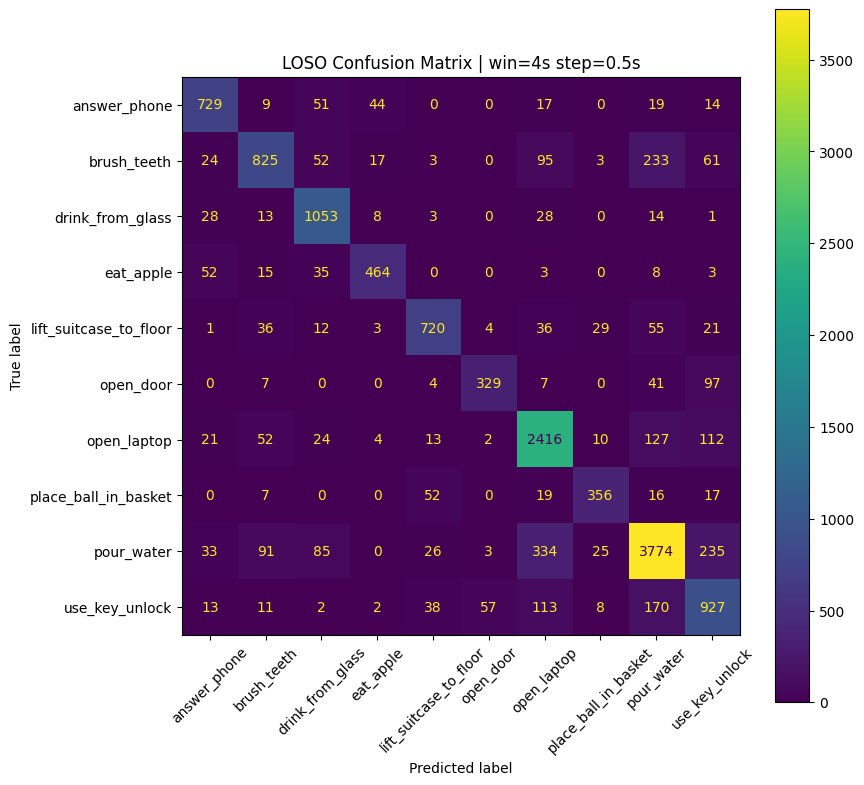

Saved summary CSV: experiment_results/channel_combo_ablation__combo__n-1__angularVelocity__win-4s__step-0.5s__20260403_164753__summary.csv
Saved per-fold CSV: experiment_results/channel_combo_ablation__combo__n-1__angularVelocity__win-4s__step-0.5s__20260403_164753__folds.csv

Channel combo run 3/63
Using 1 channel(s): ['jointAngle']
No cached dataset found. Building dataset from MVNX files...
Kept files: 1420 | Skipped files (allowed but failed): 88
X: (14521, 240, 12) y: (14521,) groups: (14521,)
Saved dataset cache to: cached_datasets/dataset_ULF_in_ADL__ch-jointAngle__win-4s__step-0.5s__tasks-11-12-13-16-20-21-23-24-28-29.npz
Channel combo (1): jointAngle dataset loaded.
Dataset shape: (14521, 240, 12)
Unique subjects: 25
Class counts: {np.str_('answer_phone'): np.int64(883), np.str_('brush_teeth'): np.int64(1313), np.str_('drink_from_glass'): np.int64(1148), np.str_('eat_apple'): np.int64(580), np.str_('lift_suitcase_to_floor'): np.int64(917), np.str_('open_door'): np.int64(485), 

,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
0,1,H01,4.0,0.5,0.875,10981,2987,553,19,5,8,0.576163,0.739602,0.716301
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,8,0.599267,0.849624,0.784026
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,9,0.573916,0.854801,0.773845
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,9,0.603238,0.875912,0.684121
4,5,H05,4.0,0.5,0.875,10888,3274,359,19,5,9,0.614233,0.559889,0.640817
5,6,P02,4.0,0.5,0.875,10563,3274,684,19,5,8,0.593464,0.652047,0.685143
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,7,0.610568,0.912929,0.833039
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,7,0.579414,0.746269,0.723533
8,9,P05,4.0,0.5,0.875,9883,3274,1364,19,5,7,0.561698,0.258798,0.213687
9,10,P06,4.0,0.5,0.875,9883,3758,880,19,5,14,0.519425,0.376136,0.368942



LOSO SUMMARY
Overall window-level accuracy: 0.6379
Overall window-level macro F1: 0.6092
Mean fold accuracy: 0.6857 ± 0.1858
Mean fold macro F1: 0.6359 ± 0.1717

Per-fold results:


,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
12,13,P10,4.0,0.5,0.875,10012,4093,416,19,5,7,0.481554,0.937500,0.886580
16,17,P19,4.0,0.5,0.875,10184,4093,244,19,5,9,0.479844,0.922131,0.763365
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,7,0.610568,0.912929,0.833039
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,9,0.603238,0.875912,0.684121
23,24,P29,4.0,0.5,0.875,10705,3408,408,19,5,14,0.541960,0.872549,0.831300
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,9,0.573916,0.854801,0.773845
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,8,0.599267,0.849624,0.784026
20,21,P24,4.0,0.5,0.875,10512,3408,601,19,5,17,0.566315,0.813644,0.682248
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,7,0.579414,0.746269,0.723533
0,1,H01,4.0,0.5,0.875,10981,2987,553,19,5,8,0.576163,0.739602,0.716301



Classification report across all LOSO test folds:
                        precision    recall  f1-score   support

          answer_phone      0.813     0.764     0.788       883
           brush_teeth      0.456     0.430     0.443      1313
      drink_from_glass      0.557     0.627     0.590      1148
             eat_apple      0.590     0.676     0.630       580
lift_suitcase_to_floor      0.699     0.749     0.723       917
             open_door      0.501     0.520     0.510       485
           open_laptop      0.688     0.616     0.650      2781
  place_ball_in_basket      0.402     0.788     0.532       467
            pour_water      0.777     0.693     0.733      4606
        use_key_unlock      0.468     0.521     0.493      1341

              accuracy                          0.638     14521
             macro avg      0.595     0.638     0.609     14521
          weighted avg      0.653     0.638     0.642     14521



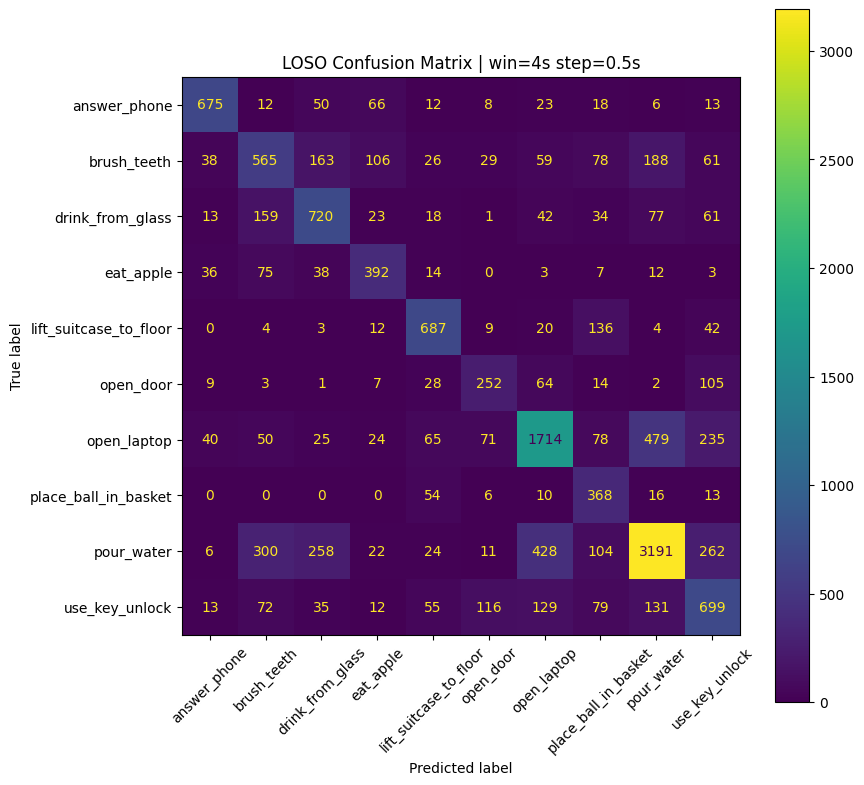

Saved summary CSV: experiment_results/channel_combo_ablation__combo__n-1__jointAngle__win-4s__step-0.5s__20260403_170253__summary.csv
Saved per-fold CSV: experiment_results/channel_combo_ablation__combo__n-1__jointAngle__win-4s__step-0.5s__20260403_170253__folds.csv

Channel combo run 4/63
Using 1 channel(s): ['jointAngleXZY']
No cached dataset found. Building dataset from MVNX files...
Kept files: 1420 | Skipped files (allowed but failed): 88
X: (14521, 240, 12) y: (14521,) groups: (14521,)
Saved dataset cache to: cached_datasets/dataset_ULF_in_ADL__ch-jointAngleXZY__win-4s__step-0.5s__tasks-11-12-13-16-20-21-23-24-28-29.npz
Channel combo (1): jointAngleXZY dataset loaded.
Dataset shape: (14521, 240, 12)
Unique subjects: 25
Class counts: {np.str_('answer_phone'): np.int64(883), np.str_('brush_teeth'): np.int64(1313), np.str_('drink_from_glass'): np.int64(1148), np.str_('eat_apple'): np.int64(580), np.str_('lift_suitcase_to_floor'): np.int64(917), np.str_('open_door'): np.int64(485), n

,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
0,1,H01,4.0,0.5,0.875,10981,2987,553,19,5,7,0.584198,0.535262,0.534406
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,10,0.605070,0.639098,0.611156
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,8,0.571778,0.737705,0.631561
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,9,0.606292,0.788321,0.587532
4,5,H05,4.0,0.5,0.875,10888,3274,359,19,5,8,0.623091,0.715877,0.664394
5,6,P02,4.0,0.5,0.875,10563,3274,684,19,5,16,0.599572,0.500000,0.519712
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,15,0.602932,0.881266,0.826439
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,9,0.573610,0.792910,0.769882
8,9,P05,4.0,0.5,0.875,9883,3274,1364,19,5,12,0.572083,0.280792,0.239834
9,10,P06,4.0,0.5,0.875,9883,3758,880,19,5,14,0.519691,0.290909,0.274666



LOSO SUMMARY
Overall window-level accuracy: 0.5900
Overall window-level macro F1: 0.5604
Mean fold accuracy: 0.6399 ± 0.1744
Mean fold macro F1: 0.5772 ± 0.1702

Per-fold results:


,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
12,13,P10,4.0,0.5,0.875,10012,4093,416,19,5,9,0.457122,0.937500,0.925067
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,15,0.602932,0.881266,0.826439
16,17,P19,4.0,0.5,0.875,10184,4093,244,19,5,8,0.469582,0.856557,0.693750
23,24,P29,4.0,0.5,0.875,10705,3408,408,19,5,15,0.519953,0.850490,0.790687
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,9,0.573610,0.792910,0.769882
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,9,0.606292,0.788321,0.587532
21,22,P25,4.0,0.5,0.875,10625,3408,488,19,5,13,0.523181,0.739754,0.688122
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,8,0.571778,0.737705,0.631561
18,19,P21,4.0,0.5,0.875,10500,3525,496,19,5,17,0.470922,0.727823,0.730006
4,5,H05,4.0,0.5,0.875,10888,3274,359,19,5,8,0.623091,0.715877,0.664394



Classification report across all LOSO test folds:
                        precision    recall  f1-score   support

          answer_phone      0.750     0.690     0.719       883
           brush_teeth      0.387     0.439     0.411      1313
      drink_from_glass      0.597     0.544     0.569      1148
             eat_apple      0.405     0.522     0.456       580
lift_suitcase_to_floor      0.732     0.726     0.729       917
             open_door      0.501     0.458     0.478       485
           open_laptop      0.596     0.590     0.593      2781
  place_ball_in_basket      0.468     0.634     0.538       467
            pour_water      0.782     0.649     0.709      4606
        use_key_unlock      0.345     0.479     0.401      1341

              accuracy                          0.590     14521
             macro avg      0.556     0.573     0.560     14521
          weighted avg      0.616     0.590     0.599     14521



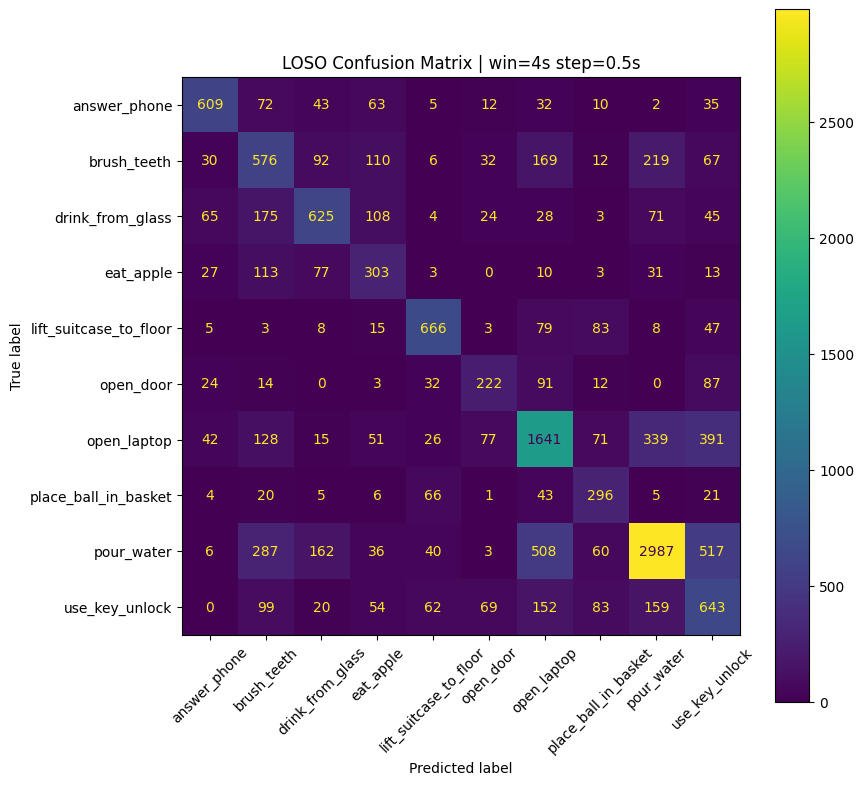

Saved summary CSV: experiment_results/channel_combo_ablation__combo__n-1__jointAngleXZY__win-4s__step-0.5s__20260403_171805__summary.csv
Saved per-fold CSV: experiment_results/channel_combo_ablation__combo__n-1__jointAngleXZY__win-4s__step-0.5s__20260403_171805__folds.csv

Channel combo run 5/63
Using 1 channel(s): ['acceleration']
No cached dataset found. Building dataset from MVNX files...
Kept files: 1420 | Skipped files (allowed but failed): 88
X: (14521, 240, 12) y: (14521,) groups: (14521,)
Saved dataset cache to: cached_datasets/dataset_ULF_in_ADL__ch-acceleration__win-4s__step-0.5s__tasks-11-12-13-16-20-21-23-24-28-29.npz
Channel combo (1): acceleration dataset loaded.
Dataset shape: (14521, 240, 12)
Unique subjects: 25
Class counts: {np.str_('answer_phone'): np.int64(883), np.str_('brush_teeth'): np.int64(1313), np.str_('drink_from_glass'): np.int64(1148), np.str_('eat_apple'): np.int64(580), np.str_('lift_suitcase_to_floor'): np.int64(917), np.str_('open_door'): np.int64(485)

,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
0,1,H01,4.0,0.5,0.875,10981,2987,553,19,5,20,0.728825,0.786618,0.755087
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,20,0.697618,0.921053,0.946422
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,20,0.759621,0.960187,0.967856
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,20,0.702810,0.959854,0.897928
4,5,H05,4.0,0.5,0.875,10888,3274,359,19,5,20,0.742822,0.796657,0.871192
5,6,P02,4.0,0.5,0.875,10563,3274,684,19,5,13,0.668296,0.612573,0.545614
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,19,0.725107,0.736148,0.673998
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,15,0.663714,0.785448,0.754002
8,9,P05,4.0,0.5,0.875,9883,3274,1364,19,5,20,0.709224,0.428886,0.339445
9,10,P06,4.0,0.5,0.875,9883,3758,880,19,5,14,0.613890,0.576136,0.510610



LOSO SUMMARY
Overall window-level accuracy: 0.7136
Overall window-level macro F1: 0.6770
Mean fold accuracy: 0.7478 ± 0.1552
Mean fold macro F1: 0.7001 ± 0.1838

Per-fold results:


,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,20,0.759621,0.960187,0.967856
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,20,0.702810,0.959854,0.897928
18,19,P21,4.0,0.5,0.875,10500,3525,496,19,5,19,0.652199,0.921371,0.904672
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,20,0.697618,0.921053,0.946422
12,13,P10,4.0,0.5,0.875,10012,4093,416,19,5,20,0.607867,0.903846,0.887475
16,17,P19,4.0,0.5,0.875,10184,4093,244,19,5,20,0.630100,0.881148,0.686131
21,22,P25,4.0,0.5,0.875,10625,3408,488,19,5,17,0.671362,0.875000,0.854219
23,24,P29,4.0,0.5,0.875,10705,3408,408,19,5,20,0.705986,0.850490,0.832039
20,21,P24,4.0,0.5,0.875,10512,3408,601,19,5,20,0.639085,0.826955,0.779989
4,5,H05,4.0,0.5,0.875,10888,3274,359,19,5,20,0.742822,0.796657,0.871192



Classification report across all LOSO test folds:
                        precision    recall  f1-score   support

          answer_phone      0.781     0.546     0.643       883
           brush_teeth      0.712     0.549     0.620      1313
      drink_from_glass      0.573     0.770     0.657      1148
             eat_apple      0.723     0.486     0.581       580
lift_suitcase_to_floor      0.782     0.688     0.732       917
             open_door      0.714     0.680     0.697       485
           open_laptop      0.784     0.788     0.786      2781
  place_ball_in_basket      0.725     0.734     0.730       467
            pour_water      0.733     0.822     0.775      4606
        use_key_unlock      0.568     0.532     0.550      1341

              accuracy                          0.714     14521
             macro avg      0.710     0.660     0.677     14521
          weighted avg      0.718     0.714     0.710     14521



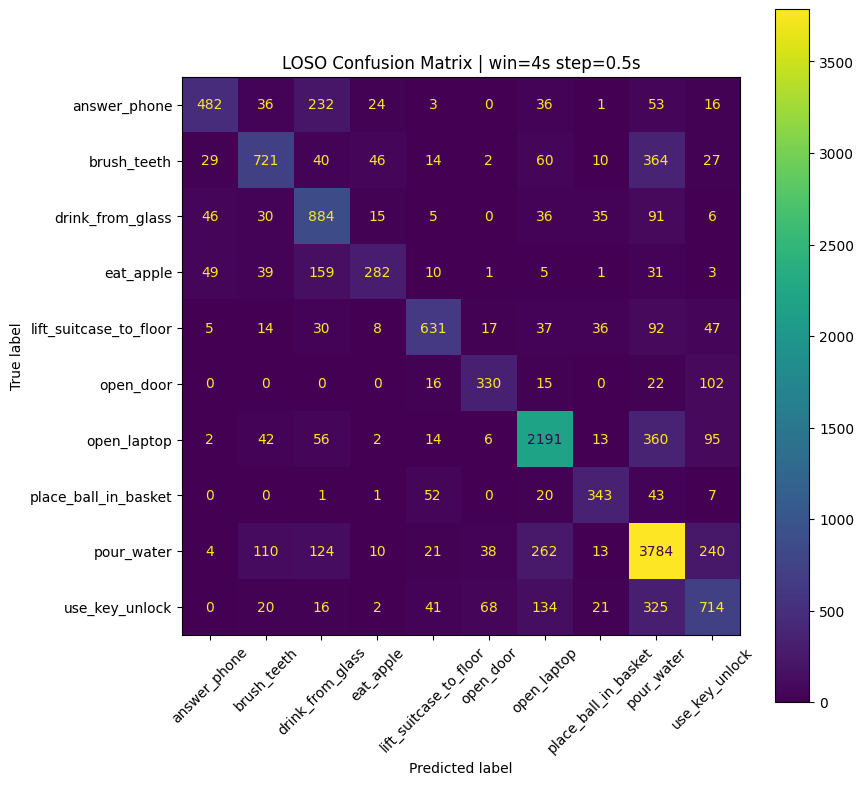

Saved summary CSV: experiment_results/channel_combo_ablation__combo__n-1__acceleration__win-4s__step-0.5s__20260403_173728__summary.csv
Saved per-fold CSV: experiment_results/channel_combo_ablation__combo__n-1__acceleration__win-4s__step-0.5s__20260403_173728__folds.csv

Channel combo run 6/63
Using 1 channel(s): ['sensorFreeAcceleration']
No cached dataset found. Building dataset from MVNX files...
Kept files: 1420 | Skipped files (allowed but failed): 88
X: (14521, 240, 12) y: (14521,) groups: (14521,)
Saved dataset cache to: cached_datasets/dataset_ULF_in_ADL__ch-sensorFreeAcceleration__win-4s__step-0.5s__tasks-11-12-13-16-20-21-23-24-28-29.npz
Channel combo (1): sensorFreeAcceleration dataset loaded.
Dataset shape: (14521, 240, 12)
Unique subjects: 25
Class counts: {np.str_('answer_phone'): np.int64(883), np.str_('brush_teeth'): np.int64(1313), np.str_('drink_from_glass'): np.int64(1148), np.str_('eat_apple'): np.int64(580), np.str_('lift_suitcase_to_floor'): np.int64(917), np.str_

,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
0,1,H01,4.0,0.5,0.875,10981,2987,553,19,5,18,0.752929,0.819168,0.733701
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,20,0.763897,0.872180,0.841067
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,18,0.734881,0.908665,0.900100
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,15,0.742517,0.901460,0.801502
4,5,H05,4.0,0.5,0.875,10888,3274,359,19,5,20,0.726329,0.682451,0.713762
5,6,P02,4.0,0.5,0.875,10563,3274,684,19,5,16,0.711668,0.741228,0.738756
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,18,0.722358,0.852243,0.799621
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,20,0.733048,0.910448,0.886568
8,9,P05,4.0,0.5,0.875,9883,3274,1364,19,5,12,0.717471,0.423754,0.405313
9,10,P06,4.0,0.5,0.875,9883,3758,880,19,5,20,0.658329,0.737500,0.729292



LOSO SUMMARY
Overall window-level accuracy: 0.7522
Overall window-level macro F1: 0.7282
Mean fold accuracy: 0.7825 ± 0.1377
Mean fold macro F1: 0.7441 ± 0.1548

Per-fold results:


,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
20,21,P24,4.0,0.5,0.875,10512,3408,601,19,5,20,0.719190,0.920133,0.901349
21,22,P25,4.0,0.5,0.875,10625,3408,488,19,5,20,0.721244,0.918033,0.910994
23,24,P29,4.0,0.5,0.875,10705,3408,408,19,5,19,0.704225,0.911765,0.924070
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,20,0.733048,0.910448,0.886568
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,18,0.734881,0.908665,0.900100
18,19,P21,4.0,0.5,0.875,10500,3525,496,19,5,20,0.697305,0.907258,0.840716
16,17,P19,4.0,0.5,0.875,10184,4093,244,19,5,14,0.637918,0.905738,0.866010
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,15,0.742517,0.901460,0.801502
12,13,P10,4.0,0.5,0.875,10012,4093,416,19,5,20,0.670902,0.901442,0.895808
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,20,0.763897,0.872180,0.841067



Classification report across all LOSO test folds:
                        precision    recall  f1-score   support

          answer_phone      0.769     0.564     0.651       883
           brush_teeth      0.746     0.657     0.699      1313
      drink_from_glass      0.639     0.787     0.705      1148
             eat_apple      0.654     0.590     0.620       580
lift_suitcase_to_floor      0.859     0.761     0.807       917
             open_door      0.890     0.685     0.774       485
           open_laptop      0.832     0.838     0.835      2781
  place_ball_in_basket      0.809     0.754     0.780       467
            pour_water      0.758     0.810     0.783      4606
        use_key_unlock      0.608     0.650     0.628      1341

              accuracy                          0.752     14521
             macro avg      0.756     0.710     0.728     14521
          weighted avg      0.757     0.752     0.752     14521



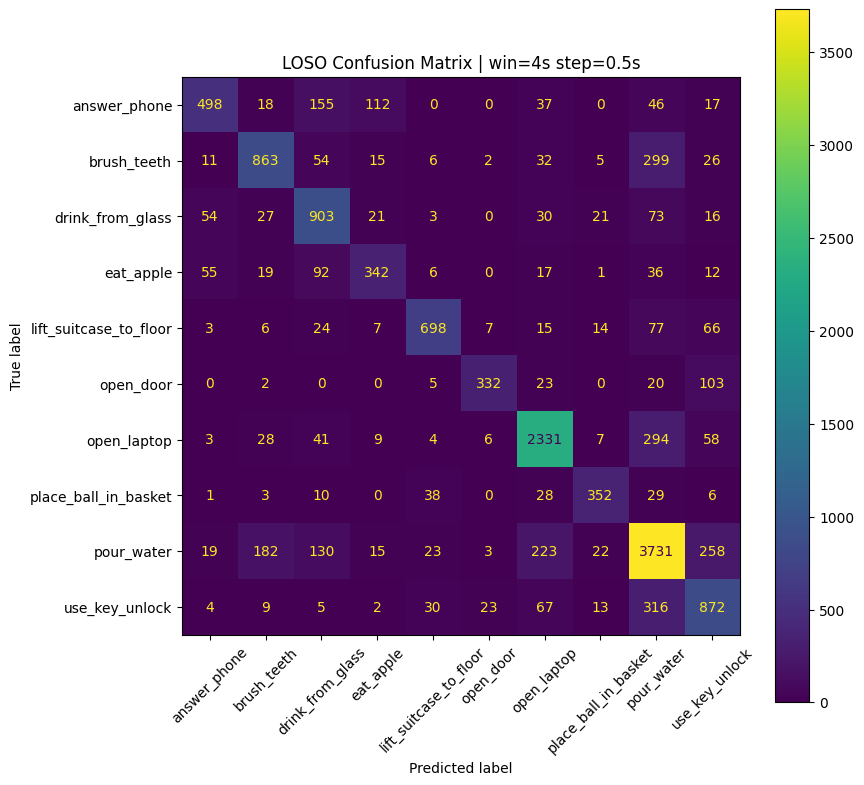

Saved summary CSV: experiment_results/channel_combo_ablation__combo__n-1__sensorFreeAcceleration__win-4s__step-0.5s__20260403_175655__summary.csv
Saved per-fold CSV: experiment_results/channel_combo_ablation__combo__n-1__sensorFreeAcceleration__win-4s__step-0.5s__20260403_175655__folds.csv

Channel combo run 7/63
Using 2 channel(s): ['velocity', 'angularVelocity']
No cached dataset found. Building dataset from MVNX files...
Kept files: 1420 | Skipped files (allowed but failed): 88
X: (14521, 240, 24) y: (14521,) groups: (14521,)
Saved dataset cache to: cached_datasets/dataset_ULF_in_ADL__ch-velocity_angularVelocity__win-4s__step-0.5s__tasks-11-12-13-16-20-21-23-24-28-29.npz
Channel combo (2): velocity + angularVelocity dataset loaded.
Dataset shape: (14521, 240, 24)
Unique subjects: 25
Class counts: {np.str_('answer_phone'): np.int64(883), np.str_('brush_teeth'): np.int64(1313), np.str_('drink_from_glass'): np.int64(1148), np.str_('eat_apple'): np.int64(580), np.str_('lift_suitcase_to_

,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
0,1,H01,4.0,0.5,0.875,10981,2987,553,19,5,19,0.824908,0.855335,0.814347
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,18,0.810018,0.921053,0.919667
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,20,0.825901,0.967213,0.972072
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,14,0.782224,0.974453,0.938566
4,5,H05,4.0,0.5,0.875,10888,3274,359,19,5,14,0.796885,0.793872,0.807258
5,6,P02,4.0,0.5,0.875,10563,3274,684,19,5,17,0.821625,0.922515,0.919542
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,20,0.832926,0.923483,0.913817
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,20,0.843616,0.951493,0.946139
8,9,P05,4.0,0.5,0.875,9883,3274,1364,19,5,20,0.805437,0.467742,0.414885
9,10,P06,4.0,0.5,0.875,9883,3758,880,19,5,20,0.678552,0.792045,0.801280



LOSO SUMMARY
Overall window-level accuracy: 0.8006
Overall window-level macro F1: 0.7952
Mean fold accuracy: 0.8319 ± 0.1534
Mean fold macro F1: 0.8057 ± 0.1837

Per-fold results:


,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
12,13,P10,4.0,0.5,0.875,10012,4093,416,19,5,19,0.677742,0.978365,0.973904
23,24,P29,4.0,0.5,0.875,10705,3408,408,19,5,11,0.701291,0.977941,0.966313
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,14,0.782224,0.974453,0.938566
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,20,0.825901,0.967213,0.972072
16,17,P19,4.0,0.5,0.875,10184,4093,244,19,5,17,0.675299,0.967213,0.823800
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,20,0.843616,0.951493,0.946139
21,22,P25,4.0,0.5,0.875,10625,3408,488,19,5,17,0.707160,0.934426,0.942903
18,19,P21,4.0,0.5,0.875,10500,3525,496,19,5,11,0.670638,0.931452,0.920291
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,20,0.832926,0.923483,0.913817
5,6,P02,4.0,0.5,0.875,10563,3274,684,19,5,17,0.821625,0.922515,0.919542



Classification report across all LOSO test folds:
                        precision    recall  f1-score   support

          answer_phone      0.932     0.804     0.863       883
           brush_teeth      0.815     0.596     0.688      1313
      drink_from_glass      0.821     0.877     0.848      1148
             eat_apple      0.881     0.776     0.825       580
lift_suitcase_to_floor      0.898     0.826     0.860       917
             open_door      0.855     0.720     0.782       485
           open_laptop      0.775     0.867     0.818      2781
  place_ball_in_basket      0.822     0.771     0.796       467
            pour_water      0.835     0.835     0.835      4606
        use_key_unlock      0.577     0.712     0.638      1341

              accuracy                          0.801     14521
             macro avg      0.821     0.778     0.795     14521
          weighted avg      0.809     0.801     0.801     14521



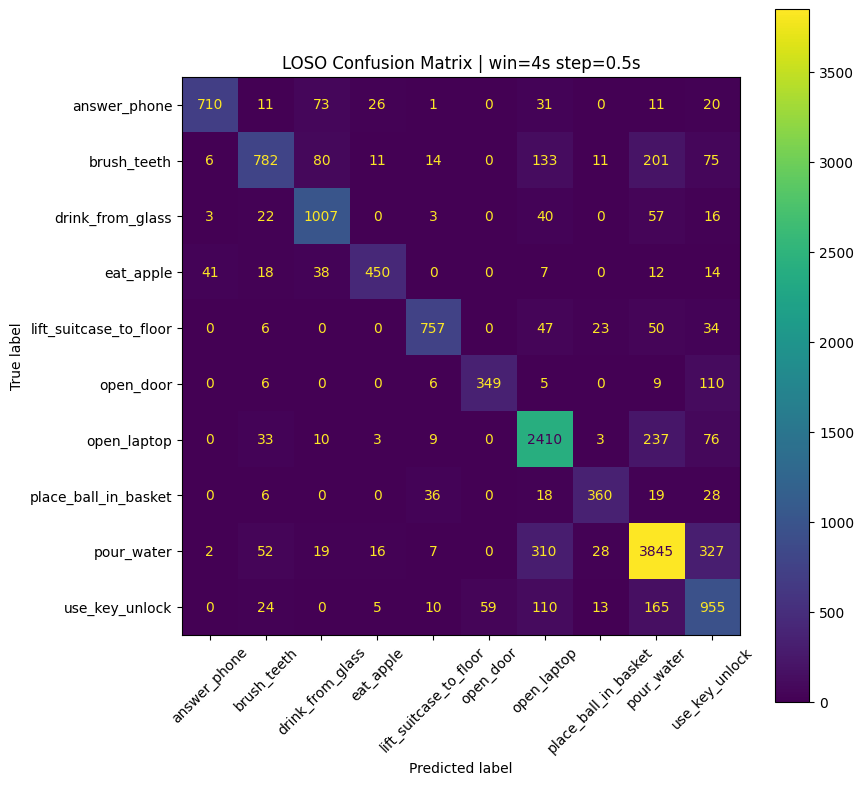

Saved summary CSV: experiment_results/channel_combo_ablation__combo__n-2__velocity-angularVelocity__win-4s__step-0.5s__20260403_181652__summary.csv
Saved per-fold CSV: experiment_results/channel_combo_ablation__combo__n-2__velocity-angularVelocity__win-4s__step-0.5s__20260403_181652__folds.csv

Channel combo run 8/63
Using 2 channel(s): ['velocity', 'jointAngle']
No cached dataset found. Building dataset from MVNX files...
Kept files: 1420 | Skipped files (allowed but failed): 88
X: (14521, 240, 24) y: (14521,) groups: (14521,)
Saved dataset cache to: cached_datasets/dataset_ULF_in_ADL__ch-velocity_jointAngle__win-4s__step-0.5s__tasks-11-12-13-16-20-21-23-24-28-29.npz
Channel combo (2): velocity + jointAngle dataset loaded.
Dataset shape: (14521, 240, 24)
Unique subjects: 25
Class counts: {np.str_('answer_phone'): np.int64(883), np.str_('brush_teeth'): np.int64(1313), np.str_('drink_from_glass'): np.int64(1148), np.str_('eat_apple'): np.int64(580), np.str_('lift_suitcase_to_floor'): np

,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
0,1,H01,4.0,0.5,0.875,10981,2987,553,19,5,9,0.615333,0.781193,0.712081
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,8,0.638057,0.921053,0.936002
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,8,0.640195,0.925059,0.894617
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,8,0.661271,0.945255,0.766225
4,5,H05,4.0,0.5,0.875,10888,3274,359,19,5,13,0.641417,0.791086,0.797411
5,6,P02,4.0,0.5,0.875,10563,3274,684,19,5,8,0.672266,0.846491,0.855954
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,13,0.686927,0.923483,0.929743
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,15,0.655467,0.929104,0.925066
8,9,P05,4.0,0.5,0.875,9883,3274,1364,19,5,10,0.644166,0.309384,0.363447
9,10,P06,4.0,0.5,0.875,9883,3758,880,19,5,9,0.558542,0.422727,0.424893



LOSO SUMMARY
Overall window-level accuracy: 0.7143
Overall window-level macro F1: 0.7034
Mean fold accuracy: 0.7664 ± 0.1712
Mean fold macro F1: 0.7368 ± 0.1685

Per-fold results:


,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
12,13,P10,4.0,0.5,0.875,10012,4093,416,19,5,10,0.586856,0.951923,0.943043
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,8,0.661271,0.945255,0.766225
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,15,0.655467,0.929104,0.925066
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,8,0.640195,0.925059,0.894617
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,13,0.686927,0.923483,0.929743
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,8,0.638057,0.921053,0.936002
23,24,P29,4.0,0.5,0.875,10705,3408,408,19,5,13,0.593603,0.904412,0.876499
20,21,P24,4.0,0.5,0.875,10512,3408,601,19,5,14,0.583920,0.898502,0.821381
16,17,P19,4.0,0.5,0.875,10184,4093,244,19,5,9,0.552162,0.885246,0.878233
21,22,P25,4.0,0.5,0.875,10625,3408,488,19,5,8,0.577758,0.877049,0.861911



Classification report across all LOSO test folds:
                        precision    recall  f1-score   support

          answer_phone      0.857     0.733     0.790       883
           brush_teeth      0.555     0.555     0.555      1313
      drink_from_glass      0.720     0.718     0.719      1148
             eat_apple      0.624     0.724     0.670       580
lift_suitcase_to_floor      0.814     0.869     0.841       917
             open_door      0.687     0.637     0.661       485
           open_laptop      0.819     0.751     0.783      2781
  place_ball_in_basket      0.779     0.717     0.747       467
            pour_water      0.831     0.729     0.777      4606
        use_key_unlock      0.396     0.645     0.491      1341

              accuracy                          0.714     14521
             macro avg      0.708     0.708     0.703     14521
          weighted avg      0.740     0.714     0.723     14521



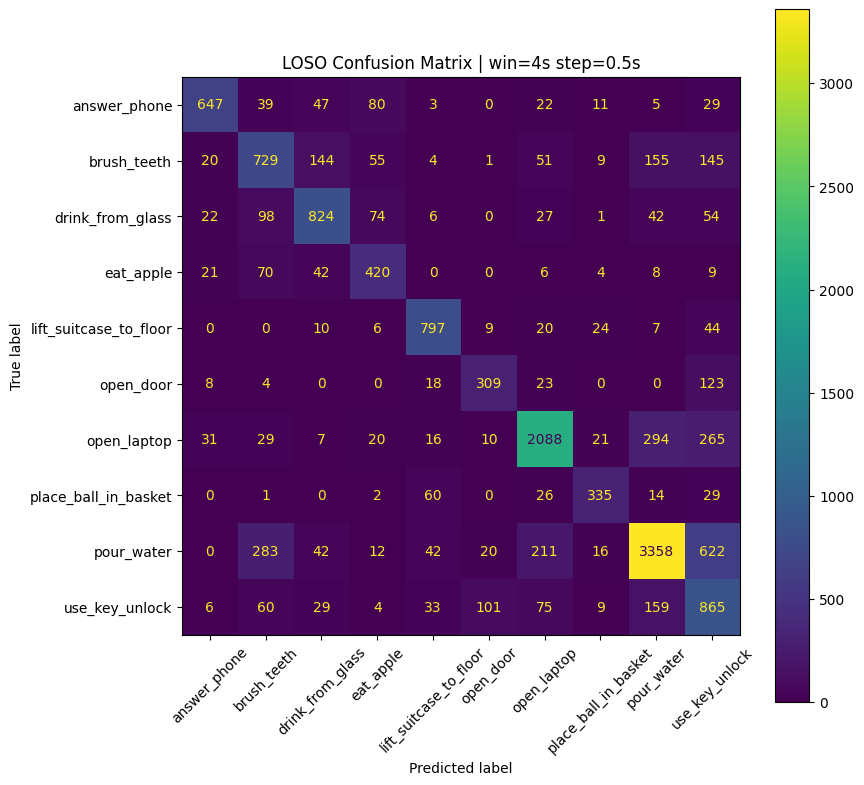

Saved summary CSV: experiment_results/channel_combo_ablation__combo__n-2__velocity-jointAngle__win-4s__step-0.5s__20260403_183236__summary.csv
Saved per-fold CSV: experiment_results/channel_combo_ablation__combo__n-2__velocity-jointAngle__win-4s__step-0.5s__20260403_183236__folds.csv

Channel combo run 9/63
Using 2 channel(s): ['velocity', 'jointAngleXZY']
No cached dataset found. Building dataset from MVNX files...
Kept files: 1420 | Skipped files (allowed but failed): 88
X: (14521, 240, 24) y: (14521,) groups: (14521,)
Saved dataset cache to: cached_datasets/dataset_ULF_in_ADL__ch-velocity_jointAngleXZY__win-4s__step-0.5s__tasks-11-12-13-16-20-21-23-24-28-29.npz
Channel combo (2): velocity + jointAngleXZY dataset loaded.
Dataset shape: (14521, 240, 24)
Unique subjects: 25
Class counts: {np.str_('answer_phone'): np.int64(883), np.str_('brush_teeth'): np.int64(1313), np.str_('drink_from_glass'): np.int64(1148), np.str_('eat_apple'): np.int64(580), np.str_('lift_suitcase_to_floor'): np.

,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
0,1,H01,4.0,0.5,0.875,10981,2987,553,19,5,10,0.644459,0.819168,0.808626
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,13,0.671961,0.909774,0.926303
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,12,0.611484,0.971897,0.952092
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,12,0.668907,0.864964,0.734644
4,5,H05,4.0,0.5,0.875,10888,3274,359,19,5,12,0.641417,0.799443,0.782127
5,6,P02,4.0,0.5,0.875,10563,3274,684,19,5,13,0.653024,0.687135,0.640705
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,17,0.645693,0.965699,0.957219
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,9,0.649359,0.882463,0.877003
8,9,P05,4.0,0.5,0.875,9883,3274,1364,19,5,11,0.635919,0.289589,0.270505
9,10,P06,4.0,0.5,0.875,9883,3758,880,19,5,7,0.562001,0.354545,0.313257



LOSO SUMMARY
Overall window-level accuracy: 0.6715
Overall window-level macro F1: 0.6387
Mean fold accuracy: 0.7309 ± 0.1957
Mean fold macro F1: 0.6919 ± 0.2042

Per-fold results:


,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
12,13,P10,4.0,0.5,0.875,10012,4093,416,19,5,19,0.546299,0.978365,0.972760
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,12,0.611484,0.971897,0.952092
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,17,0.645693,0.965699,0.957219
16,17,P19,4.0,0.5,0.875,10184,4093,244,19,5,17,0.555094,0.934426,0.971276
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,13,0.671961,0.909774,0.926303
23,24,P29,4.0,0.5,0.875,10705,3408,408,19,5,20,0.614437,0.909314,0.855862
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,9,0.649359,0.882463,0.877003
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,12,0.668907,0.864964,0.734644
21,22,P25,4.0,0.5,0.875,10625,3408,488,19,5,18,0.662559,0.860656,0.793606
0,1,H01,4.0,0.5,0.875,10981,2987,553,19,5,10,0.644459,0.819168,0.808626



Classification report across all LOSO test folds:
                        precision    recall  f1-score   support

          answer_phone      0.818     0.734     0.774       883
           brush_teeth      0.479     0.522     0.500      1313
      drink_from_glass      0.721     0.687     0.704      1148
             eat_apple      0.519     0.564     0.540       580
lift_suitcase_to_floor      0.701     0.784     0.740       917
             open_door      0.578     0.565     0.571       485
           open_laptop      0.767     0.731     0.748      2781
  place_ball_in_basket      0.539     0.660     0.593       467
            pour_water      0.768     0.709     0.737      4606
        use_key_unlock      0.440     0.525     0.479      1341

              accuracy                          0.672     14521
             macro avg      0.633     0.648     0.639     14521
          weighted avg      0.683     0.672     0.676     14521



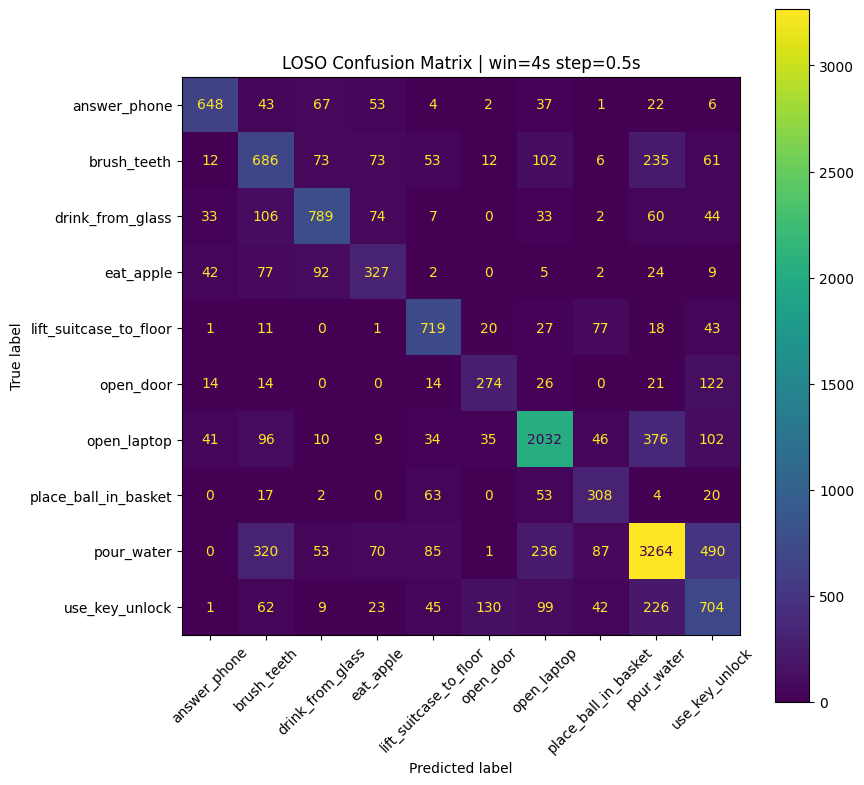

Saved summary CSV: experiment_results/channel_combo_ablation__combo__n-2__velocity-jointAngleXZY__win-4s__step-0.5s__20260403_185029__summary.csv
Saved per-fold CSV: experiment_results/channel_combo_ablation__combo__n-2__velocity-jointAngleXZY__win-4s__step-0.5s__20260403_185029__folds.csv

Channel combo run 10/63
Using 2 channel(s): ['velocity', 'acceleration']
No cached dataset found. Building dataset from MVNX files...
Kept files: 1420 | Skipped files (allowed but failed): 88
X: (14521, 240, 24) y: (14521,) groups: (14521,)
Saved dataset cache to: cached_datasets/dataset_ULF_in_ADL__ch-velocity_acceleration__win-4s__step-0.5s__tasks-11-12-13-16-20-21-23-24-28-29.npz
Channel combo (2): velocity + acceleration dataset loaded.
Dataset shape: (14521, 240, 24)
Unique subjects: 25
Class counts: {np.str_('answer_phone'): np.int64(883), np.str_('brush_teeth'): np.int64(1313), np.str_('drink_from_glass'): np.int64(1148), np.str_('eat_apple'): np.int64(580), np.str_('lift_suitcase_to_floor'):

,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
0,1,H01,4.0,0.5,0.875,10981,2987,553,19,5,18,0.765651,0.806510,0.704914
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,15,0.752596,0.834586,0.805942
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,19,0.772755,0.969555,0.965094
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,12,0.744044,0.948905,0.821939
4,5,H05,4.0,0.5,0.875,10888,3274,359,19,5,16,0.739768,0.802228,0.857526
5,6,P02,4.0,0.5,0.875,10563,3274,684,19,5,20,0.774893,0.732456,0.717289
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,20,0.756567,0.886544,0.849935
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,20,0.750153,0.856343,0.848110
8,9,P05,4.0,0.5,0.875,9883,3274,1364,19,5,20,0.762676,0.382698,0.379048
9,10,P06,4.0,0.5,0.875,9883,3758,880,19,5,10,0.618680,0.638636,0.557573



LOSO SUMMARY
Overall window-level accuracy: 0.7432
Overall window-level macro F1: 0.7191
Mean fold accuracy: 0.7762 ± 0.1655
Mean fold macro F1: 0.7321 ± 0.1787

Per-fold results:


,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,19,0.772755,0.969555,0.965094
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,12,0.744044,0.948905,0.821939
23,24,P29,4.0,0.5,0.875,10705,3408,408,19,5,20,0.691021,0.931373,0.956267
16,17,P19,4.0,0.5,0.875,10184,4093,244,19,5,20,0.655509,0.926230,0.680050
12,13,P10,4.0,0.5,0.875,10012,4093,416,19,5,16,0.644026,0.915865,0.922514
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,20,0.756567,0.886544,0.849935
20,21,P24,4.0,0.5,0.875,10512,3408,601,19,5,20,0.703052,0.885191,0.842065
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,20,0.750153,0.856343,0.848110
18,19,P21,4.0,0.5,0.875,10500,3525,496,19,5,20,0.680851,0.854839,0.827924
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,15,0.752596,0.834586,0.805942



Classification report across all LOSO test folds:
                        precision    recall  f1-score   support

          answer_phone      0.745     0.608     0.670       883
           brush_teeth      0.764     0.618     0.683      1313
      drink_from_glass      0.623     0.813     0.705      1148
             eat_apple      0.603     0.491     0.541       580
lift_suitcase_to_floor      0.935     0.794     0.858       917
             open_door      0.813     0.689     0.746       485
           open_laptop      0.808     0.834     0.821      2781
  place_ball_in_basket      0.838     0.767     0.801       467
            pour_water      0.833     0.765     0.798      4606
        use_key_unlock      0.469     0.718     0.567      1341

              accuracy                          0.743     14521
             macro avg      0.743     0.710     0.719     14521
          weighted avg      0.763     0.743     0.747     14521



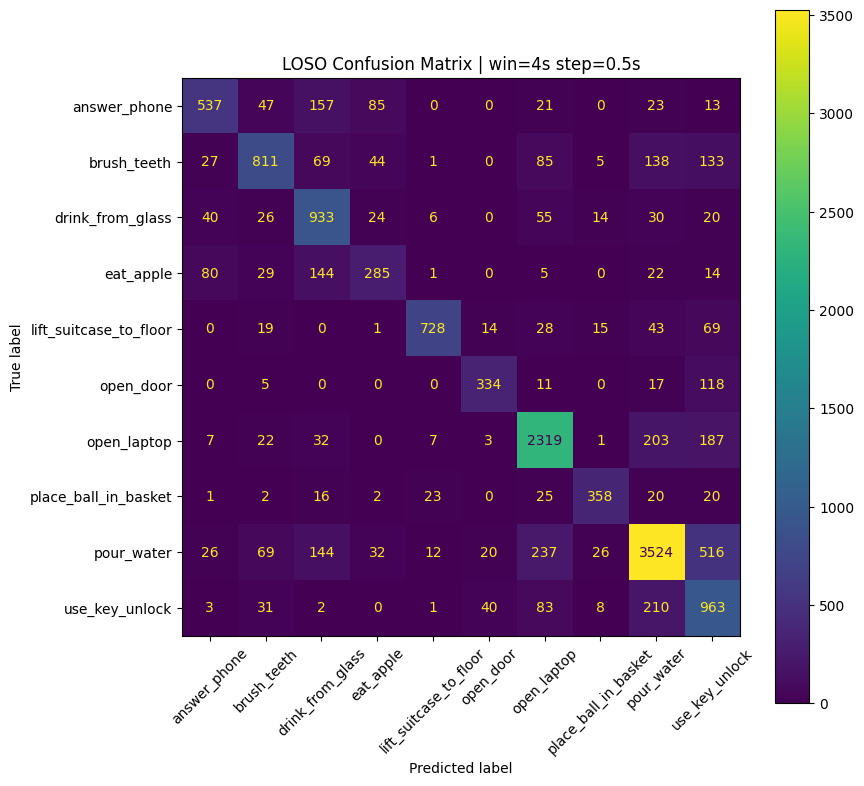

Saved summary CSV: experiment_results/channel_combo_ablation__combo__n-2__velocity-acceleration__win-4s__step-0.5s__20260403_191017__summary.csv
Saved per-fold CSV: experiment_results/channel_combo_ablation__combo__n-2__velocity-acceleration__win-4s__step-0.5s__20260403_191017__folds.csv

Channel combo run 11/63
Using 2 channel(s): ['velocity', 'sensorFreeAcceleration']
No cached dataset found. Building dataset from MVNX files...
Kept files: 1420 | Skipped files (allowed but failed): 88
X: (14521, 240, 24) y: (14521,) groups: (14521,)
Saved dataset cache to: cached_datasets/dataset_ULF_in_ADL__ch-velocity_sensorFreeAcceleration__win-4s__step-0.5s__tasks-11-12-13-16-20-21-23-24-28-29.npz
Channel combo (2): velocity + sensorFreeAcceleration dataset loaded.
Dataset shape: (14521, 240, 24)
Unique subjects: 25
Class counts: {np.str_('answer_phone'): np.int64(883), np.str_('brush_teeth'): np.int64(1313), np.str_('drink_from_glass'): np.int64(1148), np.str_('eat_apple'): np.int64(580), np.str

,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
0,1,H01,4.0,0.5,0.875,10981,2987,553,19,5,20,0.770003,0.801085,0.767809
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,20,0.797801,0.909774,0.902286
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,18,0.782834,0.969555,0.964252
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,19,0.736714,0.937956,0.910975
4,5,H05,4.0,0.5,0.875,10888,3274,359,19,5,20,0.755956,0.799443,0.806720
5,6,P02,4.0,0.5,0.875,10563,3274,684,19,5,12,0.752596,0.758772,0.735147
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,20,0.767868,0.907652,0.856116
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,18,0.768479,0.833955,0.814772
8,9,P05,4.0,0.5,0.875,9883,3274,1364,19,5,20,0.812767,0.446481,0.396787
9,10,P06,4.0,0.5,0.875,9883,3758,880,19,5,16,0.653539,0.739773,0.730385



LOSO SUMMARY
Overall window-level accuracy: 0.7728
Overall window-level macro F1: 0.7435
Mean fold accuracy: 0.8037 ± 0.1457
Mean fold macro F1: 0.7653 ± 0.1741

Per-fold results:


,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
16,17,P19,4.0,0.5,0.875,10184,4093,244,19,5,19,0.660396,0.971311,0.853397
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,18,0.782834,0.969555,0.964252
21,22,P25,4.0,0.5,0.875,10625,3408,488,19,5,20,0.701291,0.952869,0.955384
23,24,P29,4.0,0.5,0.875,10705,3408,408,19,5,20,0.718310,0.946078,0.942510
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,19,0.736714,0.937956,0.910975
20,21,P24,4.0,0.5,0.875,10512,3408,601,19,5,20,0.703052,0.923461,0.893957
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,20,0.797801,0.909774,0.902286
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,20,0.767868,0.907652,0.856116
12,13,P10,4.0,0.5,0.875,10012,4093,416,19,5,12,0.642316,0.884615,0.873158
18,19,P21,4.0,0.5,0.875,10500,3525,496,19,5,20,0.650213,0.877016,0.858262



Classification report across all LOSO test folds:
                        precision    recall  f1-score   support

          answer_phone      0.715     0.649     0.681       883
           brush_teeth      0.709     0.621     0.662      1313
      drink_from_glass      0.717     0.775     0.745      1148
             eat_apple      0.676     0.569     0.618       580
lift_suitcase_to_floor      0.922     0.792     0.852       917
             open_door      0.831     0.709     0.765       485
           open_laptop      0.832     0.841     0.837      2781
  place_ball_in_basket      0.895     0.747     0.814       467
            pour_water      0.807     0.856     0.831      4606
        use_key_unlock      0.587     0.680     0.630      1341

              accuracy                          0.773     14521
             macro avg      0.769     0.724     0.743     14521
          weighted avg      0.776     0.773     0.772     14521



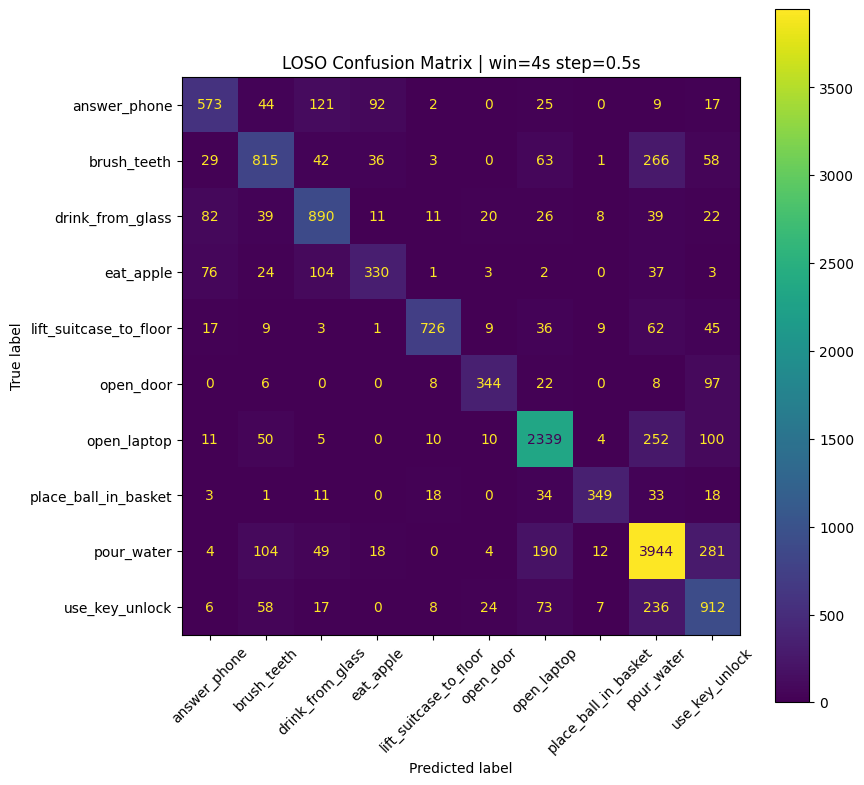

Saved summary CSV: experiment_results/channel_combo_ablation__combo__n-2__velocity-sensorFreeAcceleration__win-4s__step-0.5s__20260403_193047__summary.csv
Saved per-fold CSV: experiment_results/channel_combo_ablation__combo__n-2__velocity-sensorFreeAcceleration__win-4s__step-0.5s__20260403_193047__folds.csv

Channel combo run 12/63
Using 2 channel(s): ['angularVelocity', 'jointAngle']
No cached dataset found. Building dataset from MVNX files...
Kept files: 1420 | Skipped files (allowed but failed): 88
X: (14521, 240, 24) y: (14521,) groups: (14521,)
Saved dataset cache to: cached_datasets/dataset_ULF_in_ADL__ch-angularVelocity_jointAngle__win-4s__step-0.5s__tasks-11-12-13-16-20-21-23-24-28-29.npz
Channel combo (2): angularVelocity + jointAngle dataset loaded.
Dataset shape: (14521, 240, 24)
Unique subjects: 25
Class counts: {np.str_('answer_phone'): np.int64(883), np.str_('brush_teeth'): np.int64(1313), np.str_('drink_from_glass'): np.int64(1148), np.str_('eat_apple'): np.int64(580), n

,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
0,1,H01,4.0,0.5,0.875,10981,2987,553,19,5,14,0.671912,0.676311,0.676524
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,15,0.683873,0.936090,0.931167
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,8,0.661881,0.838407,0.785582
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,8,0.658827,0.916058,0.843289
4,5,H05,4.0,0.5,0.875,10888,3274,359,19,5,9,0.681124,0.724234,0.732601
5,6,P02,4.0,0.5,0.875,10563,3274,684,19,5,12,0.696396,0.764620,0.784416
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,11,0.697007,0.931398,0.874963
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,15,0.683873,0.822761,0.808198
8,9,P05,4.0,0.5,0.875,9883,3274,1364,19,5,12,0.636530,0.258065,0.267787
9,10,P06,4.0,0.5,0.875,9883,3758,880,19,5,19,0.554284,0.422727,0.467952



LOSO SUMMARY
Overall window-level accuracy: 0.6933
Overall window-level macro F1: 0.6802
Mean fold accuracy: 0.7454 ± 0.1855
Mean fold macro F1: 0.7147 ± 0.1773

Per-fold results:


,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
12,13,P10,4.0,0.5,0.875,10012,4093,416,19,5,12,0.542389,0.980769,0.982966
16,17,P19,4.0,0.5,0.875,10184,4093,244,19,5,11,0.537992,0.938525,0.805088
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,15,0.683873,0.936090,0.931167
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,11,0.697007,0.931398,0.874963
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,8,0.658827,0.916058,0.843289
23,24,P29,4.0,0.5,0.875,10705,3408,408,19,5,20,0.636737,0.914216,0.894692
13,14,P12,4.0,0.5,0.875,9687,4093,741,19,5,8,0.575128,0.896086,0.878510
14,15,P16,4.0,0.5,0.875,9822,4093,606,19,5,15,0.595895,0.876238,0.788342
20,21,P24,4.0,0.5,0.875,10512,3408,601,19,5,13,0.577758,0.841930,0.783230
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,8,0.661881,0.838407,0.785582



Classification report across all LOSO test folds:
                        precision    recall  f1-score   support

          answer_phone      0.870     0.817     0.842       883
           brush_teeth      0.619     0.551     0.583      1313
      drink_from_glass      0.631     0.743     0.682      1148
             eat_apple      0.688     0.698     0.693       580
lift_suitcase_to_floor      0.767     0.756     0.762       917
             open_door      0.470     0.682     0.556       485
           open_laptop      0.697     0.698     0.698      2781
  place_ball_in_basket      0.626     0.805     0.704       467
            pour_water      0.836     0.700     0.762      4606
        use_key_unlock      0.461     0.595     0.519      1341

              accuracy                          0.693     14521
             macro avg      0.666     0.705     0.680     14521
          weighted avg      0.712     0.693     0.698     14521



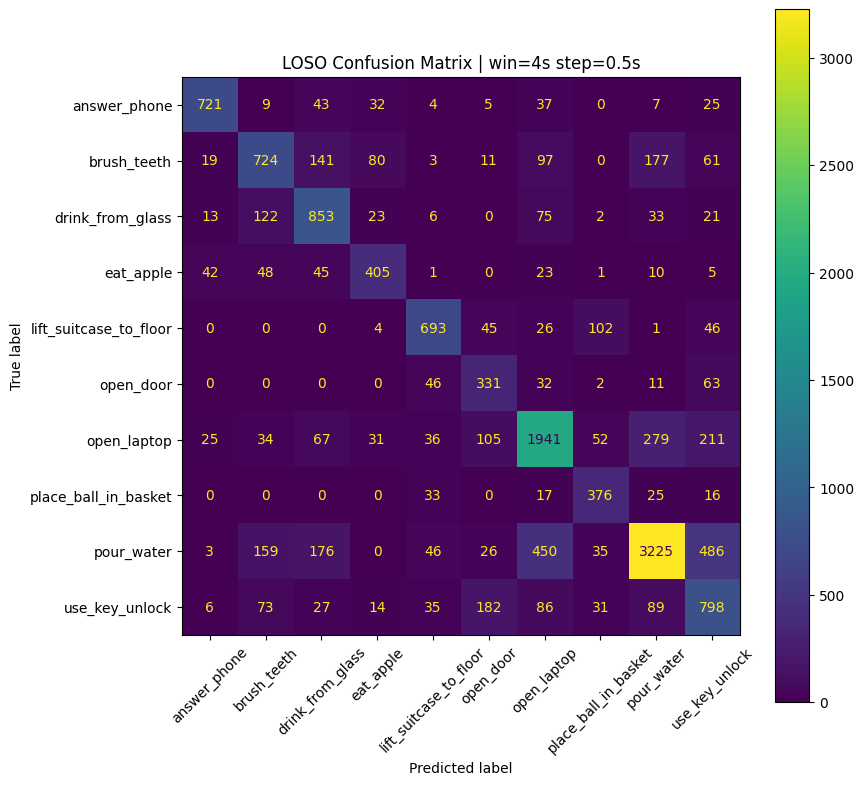

Saved summary CSV: experiment_results/channel_combo_ablation__combo__n-2__angularVelocity-jointAngle__win-4s__step-0.5s__20260403_194752__summary.csv
Saved per-fold CSV: experiment_results/channel_combo_ablation__combo__n-2__angularVelocity-jointAngle__win-4s__step-0.5s__20260403_194752__folds.csv

Channel combo run 13/63
Using 2 channel(s): ['angularVelocity', 'jointAngleXZY']
No cached dataset found. Building dataset from MVNX files...
Kept files: 1420 | Skipped files (allowed but failed): 88
X: (14521, 240, 24) y: (14521,) groups: (14521,)
Saved dataset cache to: cached_datasets/dataset_ULF_in_ADL__ch-angularVelocity_jointAngleXZY__win-4s__step-0.5s__tasks-11-12-13-16-20-21-23-24-28-29.npz
Channel combo (2): angularVelocity + jointAngleXZY dataset loaded.
Dataset shape: (14521, 240, 24)
Unique subjects: 25
Class counts: {np.str_('answer_phone'): np.int64(883), np.str_('brush_teeth'): np.int64(1313), np.str_('drink_from_glass'): np.int64(1148), np.str_('eat_apple'): np.int64(580), np

,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
0,1,H01,4.0,0.5,0.875,10981,2987,553,19,5,9,0.677268,0.708861,0.708744
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,10,0.677764,0.909774,0.946712
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,10,0.648748,0.871194,0.848376
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,12,0.636836,0.897810,0.782803
4,5,H05,4.0,0.5,0.875,10888,3274,359,19,5,15,0.689982,0.830084,0.847557
5,6,P02,4.0,0.5,0.875,10563,3274,684,19,5,10,0.672877,0.754386,0.756099
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,10,0.664936,0.957784,0.938332
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,20,0.671961,0.925373,0.931569
8,9,P05,4.0,0.5,0.875,9883,3274,1364,19,5,9,0.620342,0.303519,0.329684
9,10,P06,4.0,0.5,0.875,9883,3758,880,19,5,12,0.613624,0.447727,0.453052



LOSO SUMMARY
Overall window-level accuracy: 0.6996
Overall window-level macro F1: 0.6932
Mean fold accuracy: 0.7505 ± 0.1810
Mean fold macro F1: 0.7264 ± 0.1751

Per-fold results:


,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
12,13,P10,4.0,0.5,0.875,10012,4093,416,19,5,7,0.536526,0.966346,0.967022
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,10,0.664936,0.957784,0.938332
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,20,0.671961,0.925373,0.931569
23,24,P29,4.0,0.5,0.875,10705,3408,408,19,5,20,0.641138,0.911765,0.907247
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,10,0.677764,0.909774,0.946712
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,12,0.636836,0.897810,0.782803
14,15,P16,4.0,0.5,0.875,9822,4093,606,19,5,14,0.602736,0.886139,0.825765
16,17,P19,4.0,0.5,0.875,10184,4093,244,19,5,10,0.588566,0.877049,0.750015
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,10,0.648748,0.871194,0.848376
21,22,P25,4.0,0.5,0.875,10625,3408,488,19,5,20,0.588322,0.856557,0.828494



Classification report across all LOSO test folds:
                        precision    recall  f1-score   support

          answer_phone      0.830     0.784     0.806       883
           brush_teeth      0.646     0.516     0.573      1313
      drink_from_glass      0.738     0.738     0.738      1148
             eat_apple      0.738     0.753     0.746       580
lift_suitcase_to_floor      0.825     0.828     0.826       917
             open_door      0.621     0.518     0.565       485
           open_laptop      0.687     0.725     0.706      2781
  place_ball_in_basket      0.680     0.769     0.722       467
            pour_water      0.804     0.715     0.757      4606
        use_key_unlock      0.411     0.618     0.493      1341

              accuracy                          0.700     14521
             macro avg      0.698     0.696     0.693     14521
          weighted avg      0.716     0.700     0.704     14521



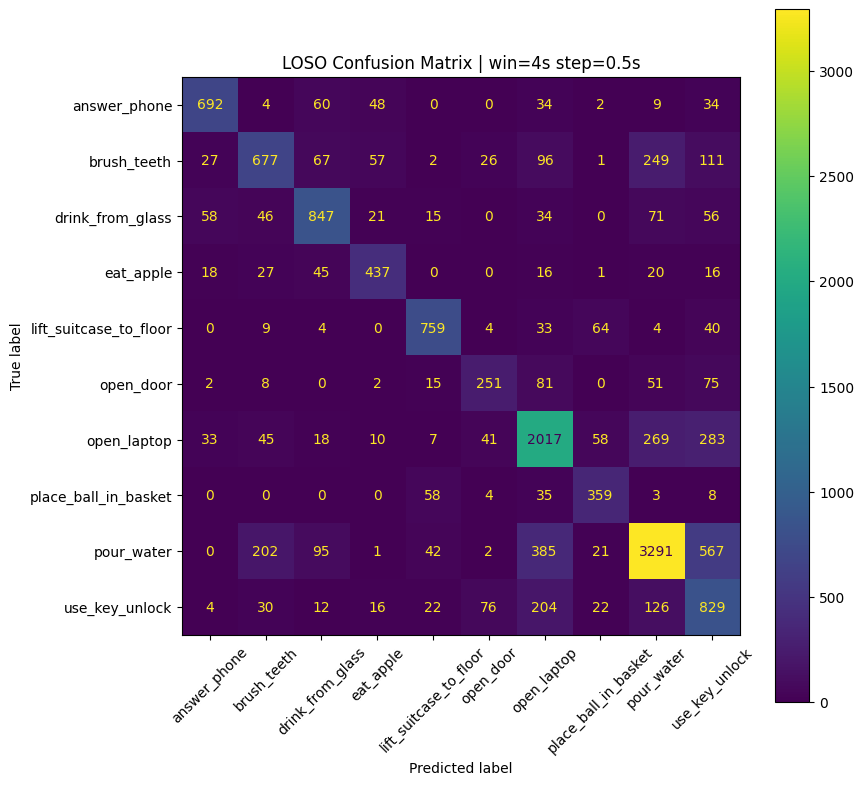

Saved summary CSV: experiment_results/channel_combo_ablation__combo__n-2__angularVelocity-jointAngleXZY__win-4s__step-0.5s__20260403_200539__summary.csv
Saved per-fold CSV: experiment_results/channel_combo_ablation__combo__n-2__angularVelocity-jointAngleXZY__win-4s__step-0.5s__20260403_200539__folds.csv

Channel combo run 14/63
Using 2 channel(s): ['angularVelocity', 'acceleration']
No cached dataset found. Building dataset from MVNX files...
Kept files: 1420 | Skipped files (allowed but failed): 88
X: (14521, 240, 24) y: (14521,) groups: (14521,)
Saved dataset cache to: cached_datasets/dataset_ULF_in_ADL__ch-angularVelocity_acceleration__win-4s__step-0.5s__tasks-11-12-13-16-20-21-23-24-28-29.npz
Channel combo (2): angularVelocity + acceleration dataset loaded.
Dataset shape: (14521, 240, 24)
Unique subjects: 25
Class counts: {np.str_('answer_phone'): np.int64(883), np.str_('brush_teeth'): np.int64(1313), np.str_('drink_from_glass'): np.int64(1148), np.str_('eat_apple'): np.int64(580),

,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
0,1,H01,4.0,0.5,0.875,10981,2987,553,19,5,13,0.805490,0.770344,0.759499
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,14,0.797190,0.879699,0.825928
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,20,0.809407,0.960187,0.959076
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,16,0.787721,0.981752,0.949510
4,5,H05,4.0,0.5,0.875,10888,3274,359,19,5,19,0.819792,0.894150,0.880636
5,6,P02,4.0,0.5,0.875,10563,3274,684,19,5,20,0.810629,0.866959,0.863004
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,20,0.814905,0.970976,0.963102
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,19,0.793525,0.910448,0.896651
8,9,P05,4.0,0.5,0.875,9883,3274,1364,19,5,20,0.811546,0.507331,0.551412
9,10,P06,4.0,0.5,0.875,9883,3758,880,19,5,20,0.705695,0.797727,0.744591



LOSO SUMMARY
Overall window-level accuracy: 0.8180
Overall window-level macro F1: 0.8018
Mean fold accuracy: 0.8511 ± 0.1304
Mean fold macro F1: 0.8207 ± 0.1561

Per-fold results:


,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
12,13,P10,4.0,0.5,0.875,10012,4093,416,19,5,20,0.690447,0.995192,0.995570
16,17,P19,4.0,0.5,0.875,10184,4093,244,19,5,20,0.708282,0.987705,0.941788
23,24,P29,4.0,0.5,0.875,10705,3408,408,19,5,20,0.761737,0.982843,0.988090
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,16,0.787721,0.981752,0.949510
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,20,0.814905,0.970976,0.963102
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,20,0.809407,0.960187,0.959076
18,19,P21,4.0,0.5,0.875,10500,3525,496,19,5,19,0.738723,0.957661,0.958972
21,22,P25,4.0,0.5,0.875,10625,3408,488,19,5,18,0.747066,0.946721,0.936925
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,19,0.793525,0.910448,0.896651
14,15,P16,4.0,0.5,0.875,9822,4093,606,19,5,17,0.703885,0.894389,0.832239



Classification report across all LOSO test folds:
                        precision    recall  f1-score   support

          answer_phone      0.849     0.804     0.826       883
           brush_teeth      0.799     0.657     0.721      1313
      drink_from_glass      0.769     0.903     0.831      1148
             eat_apple      0.877     0.774     0.822       580
lift_suitcase_to_floor      0.926     0.808     0.863       917
             open_door      0.849     0.744     0.793       485
           open_laptop      0.838     0.864     0.851      2781
  place_ball_in_basket      0.769     0.814     0.791       467
            pour_water      0.863     0.868     0.865      4606
        use_key_unlock      0.614     0.699     0.654      1341

              accuracy                          0.818     14521
             macro avg      0.815     0.794     0.802     14521
          weighted avg      0.822     0.818     0.818     14521



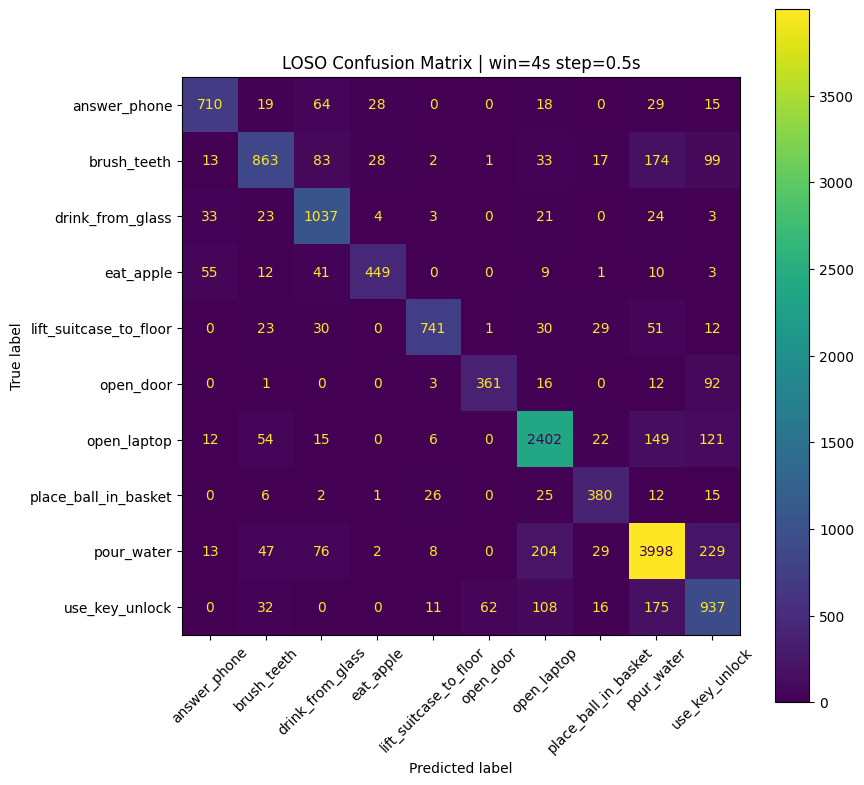

Saved summary CSV: experiment_results/channel_combo_ablation__combo__n-2__angularVelocity-acceleration__win-4s__step-0.5s__20260403_202637__summary.csv
Saved per-fold CSV: experiment_results/channel_combo_ablation__combo__n-2__angularVelocity-acceleration__win-4s__step-0.5s__20260403_202637__folds.csv

Channel combo run 15/63
Using 2 channel(s): ['angularVelocity', 'sensorFreeAcceleration']
No cached dataset found. Building dataset from MVNX files...
Kept files: 1420 | Skipped files (allowed but failed): 88
X: (14521, 240, 24) y: (14521,) groups: (14521,)
Saved dataset cache to: cached_datasets/dataset_ULF_in_ADL__ch-angularVelocity_sensorFreeAcceleration__win-4s__step-0.5s__tasks-11-12-13-16-20-21-23-24-28-29.npz
Channel combo (2): angularVelocity + sensorFreeAcceleration dataset loaded.
Dataset shape: (14521, 240, 24)
Unique subjects: 25
Class counts: {np.str_('answer_phone'): np.int64(883), np.str_('brush_teeth'): np.int64(1313), np.str_('drink_from_glass'): np.int64(1148), np.str_(

,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
0,1,H01,4.0,0.5,0.875,10981,2987,553,19,5,20,0.829930,0.817360,0.801137
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,18,0.815516,0.928571,0.881607
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,20,0.815822,0.950820,0.957721
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,20,0.828039,0.981752,0.958377
4,5,H05,4.0,0.5,0.875,10888,3274,359,19,5,20,0.825596,0.849582,0.853649
5,6,P02,4.0,0.5,0.875,10563,3274,684,19,5,13,0.768784,0.770468,0.776704
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,20,0.776726,0.965699,0.955609
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,15,0.791692,0.929104,0.936925
8,9,P05,4.0,0.5,0.875,9883,3274,1364,19,5,18,0.820709,0.574047,0.554653
9,10,P06,4.0,0.5,0.875,9883,3758,880,19,5,20,0.703832,0.818182,0.779035



LOSO SUMMARY
Overall window-level accuracy: 0.8287
Overall window-level macro F1: 0.8152
Mean fold accuracy: 0.8599 ± 0.1161
Mean fold macro F1: 0.8339 ± 0.1452

Per-fold results:


,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
16,17,P19,4.0,0.5,0.875,10184,4093,244,19,5,20,0.728805,1.000000,1.000000
23,24,P29,4.0,0.5,0.875,10705,3408,408,19,5,20,0.755282,0.997549,0.998556
12,13,P10,4.0,0.5,0.875,10012,4093,416,19,5,12,0.698998,0.983173,0.979973
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,20,0.828039,0.981752,0.958377
18,19,P21,4.0,0.5,0.875,10500,3525,496,19,5,20,0.723404,0.975806,0.975579
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,20,0.776726,0.965699,0.955609
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,20,0.815822,0.950820,0.957721
21,22,P25,4.0,0.5,0.875,10625,3408,488,19,5,19,0.747946,0.940574,0.925679
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,15,0.791692,0.929104,0.936925
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,18,0.815516,0.928571,0.881607



Classification report across all LOSO test folds:
                        precision    recall  f1-score   support

          answer_phone      0.865     0.743     0.800       883
           brush_teeth      0.851     0.710     0.774      1313
      drink_from_glass      0.766     0.899     0.827      1148
             eat_apple      0.851     0.800     0.825       580
lift_suitcase_to_floor      0.893     0.828     0.859       917
             open_door      0.878     0.784     0.828       485
           open_laptop      0.833     0.883     0.857      2781
  place_ball_in_basket      0.809     0.807     0.808       467
            pour_water      0.847     0.875     0.861      4606
        use_key_unlock      0.718     0.708     0.713      1341

              accuracy                          0.829     14521
             macro avg      0.831     0.804     0.815     14521
          weighted avg      0.830     0.829     0.828     14521



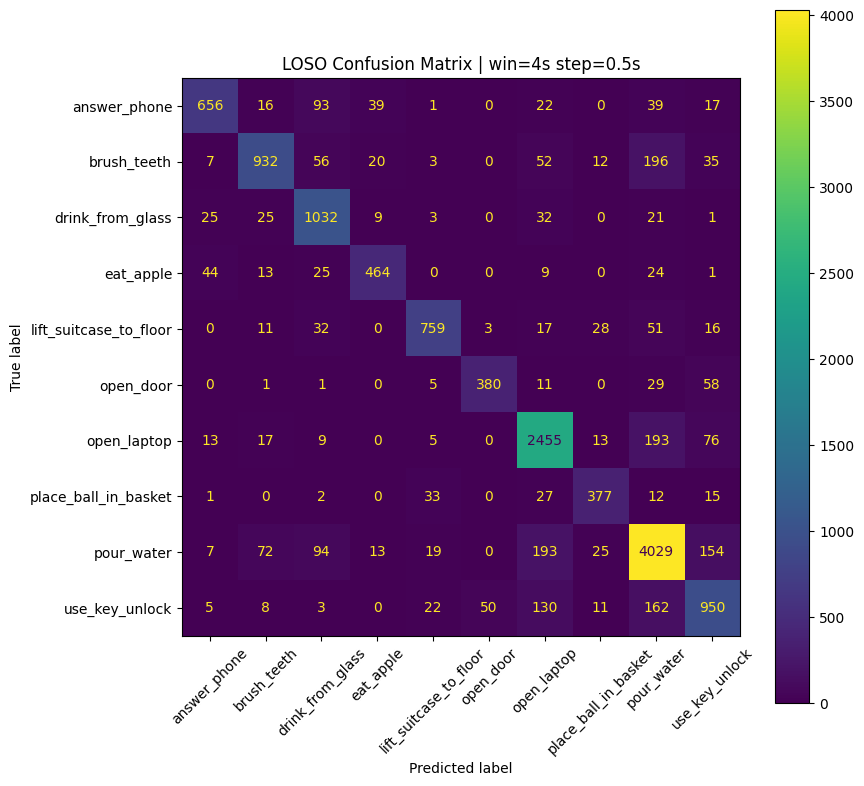

Saved summary CSV: experiment_results/channel_combo_ablation__combo__n-2__angularVelocity-sensorFreeAcceleration__win-4s__step-0.5s__20260403_204721__summary.csv
Saved per-fold CSV: experiment_results/channel_combo_ablation__combo__n-2__angularVelocity-sensorFreeAcceleration__win-4s__step-0.5s__20260403_204721__folds.csv

Channel combo run 16/63
Using 2 channel(s): ['jointAngle', 'jointAngleXZY']
No cached dataset found. Building dataset from MVNX files...
Kept files: 1420 | Skipped files (allowed but failed): 88
X: (14521, 240, 24) y: (14521,) groups: (14521,)
Saved dataset cache to: cached_datasets/dataset_ULF_in_ADL__ch-jointAngle_jointAngleXZY__win-4s__step-0.5s__tasks-11-12-13-16-20-21-23-24-28-29.npz
Channel combo (2): jointAngle + jointAngleXZY dataset loaded.
Dataset shape: (14521, 240, 24)
Unique subjects: 25
Class counts: {np.str_('answer_phone'): np.int64(883), np.str_('brush_teeth'): np.int64(1313), np.str_('drink_from_glass'): np.int64(1148), np.str_('eat_apple'): np.int64

,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
0,1,H01,4.0,0.5,0.875,10981,2987,553,19,5,9,0.594911,0.692586,0.632852
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,7,0.589798,0.751880,0.689166
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,10,0.576970,0.880562,0.776451
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,7,0.593158,0.843066,0.691216
4,5,H05,4.0,0.5,0.875,10888,3274,359,19,5,9,0.564142,0.621170,0.574137
5,6,P02,4.0,0.5,0.875,10563,3274,684,19,5,7,0.595907,0.666667,0.699745
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,7,0.606903,0.759894,0.725149
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,8,0.601100,0.770522,0.786791
8,9,P05,4.0,0.5,0.875,9883,3274,1364,19,5,18,0.579414,0.252933,0.184437
9,10,P06,4.0,0.5,0.875,9883,3758,880,19,5,7,0.539383,0.455682,0.430883



LOSO SUMMARY
Overall window-level accuracy: 0.6407
Overall window-level macro F1: 0.6093
Mean fold accuracy: 0.6902 ± 0.1703
Mean fold macro F1: 0.6337 ± 0.1835

Per-fold results:


,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
12,13,P10,4.0,0.5,0.875,10012,4093,416,19,5,9,0.487173,0.942308,0.925573
23,24,P29,4.0,0.5,0.875,10705,3408,408,19,5,11,0.534331,0.936275,0.925289
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,10,0.576970,0.880562,0.776451
16,17,P19,4.0,0.5,0.875,10184,4093,244,19,5,7,0.488883,0.872951,0.834838
21,22,P25,4.0,0.5,0.875,10625,3408,488,19,5,14,0.536385,0.870902,0.812457
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,7,0.593158,0.843066,0.691216
20,21,P24,4.0,0.5,0.875,10512,3408,601,19,5,7,0.482394,0.816972,0.700901
13,14,P12,4.0,0.5,0.875,9687,4093,741,19,5,8,0.508918,0.773279,0.773864
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,8,0.601100,0.770522,0.786791
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,7,0.606903,0.759894,0.725149



Classification report across all LOSO test folds:
                        precision    recall  f1-score   support

          answer_phone      0.762     0.741     0.751       883
           brush_teeth      0.565     0.474     0.516      1313
      drink_from_glass      0.727     0.630     0.675      1148
             eat_apple      0.535     0.659     0.590       580
lift_suitcase_to_floor      0.599     0.749     0.666       917
             open_door      0.511     0.542     0.526       485
           open_laptop      0.684     0.616     0.648      2781
  place_ball_in_basket      0.425     0.732     0.538       467
            pour_water      0.773     0.704     0.737      4606
        use_key_unlock      0.399     0.503     0.445      1341

              accuracy                          0.641     14521
             macro avg      0.598     0.635     0.609     14521
          weighted avg      0.658     0.641     0.645     14521



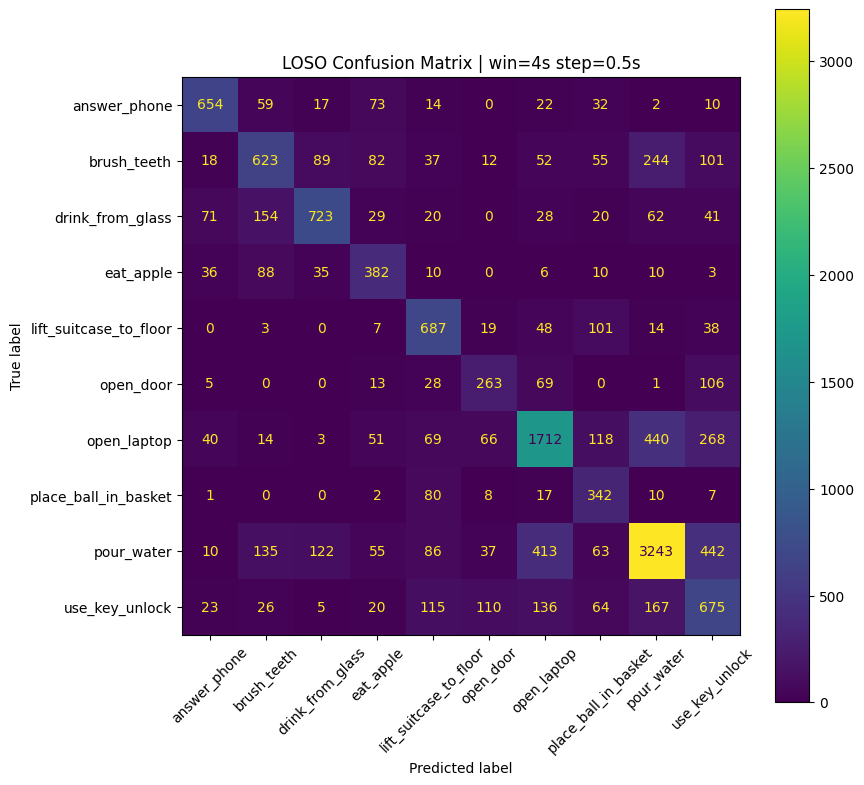

Saved summary CSV: experiment_results/channel_combo_ablation__combo__n-2__jointAngle-jointAngleXZY__win-4s__step-0.5s__20260403_210213__summary.csv
Saved per-fold CSV: experiment_results/channel_combo_ablation__combo__n-2__jointAngle-jointAngleXZY__win-4s__step-0.5s__20260403_210213__folds.csv

Channel combo run 17/63
Using 2 channel(s): ['jointAngle', 'acceleration']
No cached dataset found. Building dataset from MVNX files...
Kept files: 1420 | Skipped files (allowed but failed): 88
X: (14521, 240, 24) y: (14521,) groups: (14521,)
Saved dataset cache to: cached_datasets/dataset_ULF_in_ADL__ch-jointAngle_acceleration__win-4s__step-0.5s__tasks-11-12-13-16-20-21-23-24-28-29.npz
Channel combo (2): jointAngle + acceleration dataset loaded.
Dataset shape: (14521, 240, 24)
Unique subjects: 25
Class counts: {np.str_('answer_phone'): np.int64(883), np.str_('brush_teeth'): np.int64(1313), np.str_('drink_from_glass'): np.int64(1148), np.str_('eat_apple'): np.int64(580), np.str_('lift_suitcase_t

,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
0,1,H01,4.0,0.5,0.875,10981,2987,553,19,5,8,0.659190,0.605787,0.530473
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,9,0.659743,0.879699,0.847401
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,16,0.668907,0.943794,0.912847
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,8,0.616066,0.937956,0.754856
4,5,H05,4.0,0.5,0.875,10888,3274,359,19,5,9,0.651191,0.629526,0.637108
5,6,P02,4.0,0.5,0.875,10563,3274,684,19,5,15,0.645388,0.845029,0.850490
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,8,0.659438,0.907652,0.886817
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,8,0.596213,0.744403,0.742543
8,9,P05,4.0,0.5,0.875,9883,3274,1364,19,5,8,0.598962,0.248534,0.250995
9,10,P06,4.0,0.5,0.875,9883,3758,880,19,5,11,0.566259,0.470455,0.408887



LOSO SUMMARY
Overall window-level accuracy: 0.7010
Overall window-level macro F1: 0.6789
Mean fold accuracy: 0.7499 ± 0.1807
Mean fold macro F1: 0.7131 ± 0.1964

Per-fold results:


,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
23,24,P29,4.0,0.5,0.875,10705,3408,408,19,5,20,0.571596,0.955882,0.961048
16,17,P19,4.0,0.5,0.875,10184,4093,244,19,5,13,0.572441,0.950820,0.977346
12,13,P10,4.0,0.5,0.875,10012,4093,416,19,5,11,0.568776,0.947115,0.963489
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,16,0.668907,0.943794,0.912847
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,8,0.616066,0.937956,0.754856
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,8,0.659438,0.907652,0.886817
21,22,P25,4.0,0.5,0.875,10625,3408,488,19,5,18,0.579812,0.887295,0.888646
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,9,0.659743,0.879699,0.847401
20,21,P24,4.0,0.5,0.875,10512,3408,601,19,5,11,0.525822,0.873544,0.824013
14,15,P16,4.0,0.5,0.875,9822,4093,606,19,5,12,0.545810,0.863036,0.828770



Classification report across all LOSO test folds:
                        precision    recall  f1-score   support

          answer_phone      0.823     0.792     0.807       883
           brush_teeth      0.653     0.555     0.600      1313
      drink_from_glass      0.692     0.740     0.715      1148
             eat_apple      0.625     0.686     0.654       580
lift_suitcase_to_floor      0.727     0.815     0.768       917
             open_door      0.573     0.604     0.588       485
           open_laptop      0.775     0.663     0.715      2781
  place_ball_in_basket      0.555     0.694     0.617       467
            pour_water      0.813     0.725     0.767      4606
        use_key_unlock      0.459     0.711     0.558      1341

              accuracy                          0.701     14521
             macro avg      0.670     0.699     0.679     14521
          weighted avg      0.720     0.701     0.706     14521



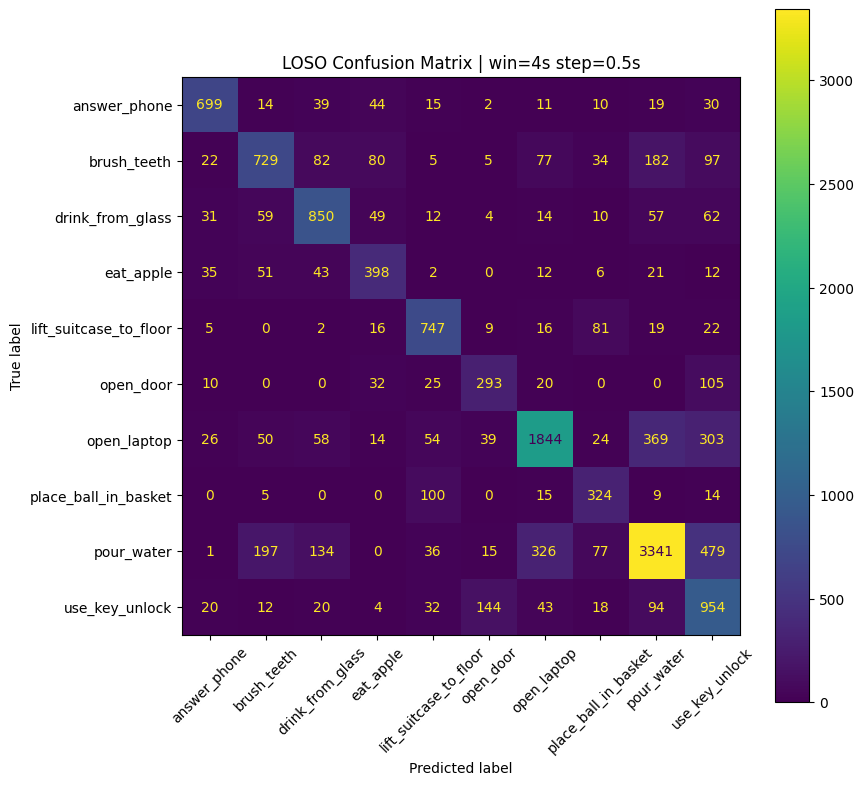

Saved summary CSV: experiment_results/channel_combo_ablation__combo__n-2__jointAngle-acceleration__win-4s__step-0.5s__20260403_211922__summary.csv
Saved per-fold CSV: experiment_results/channel_combo_ablation__combo__n-2__jointAngle-acceleration__win-4s__step-0.5s__20260403_211922__folds.csv

Channel combo run 18/63
Using 2 channel(s): ['jointAngle', 'sensorFreeAcceleration']
No cached dataset found. Building dataset from MVNX files...
Kept files: 1420 | Skipped files (allowed but failed): 88
X: (14521, 240, 24) y: (14521,) groups: (14521,)
Saved dataset cache to: cached_datasets/dataset_ULF_in_ADL__ch-jointAngle_sensorFreeAcceleration__win-4s__step-0.5s__tasks-11-12-13-16-20-21-23-24-28-29.npz
Channel combo (2): jointAngle + sensorFreeAcceleration dataset loaded.
Dataset shape: (14521, 240, 24)
Unique subjects: 25
Class counts: {np.str_('answer_phone'): np.int64(883), np.str_('brush_teeth'): np.int64(1313), np.str_('drink_from_glass'): np.int64(1148), np.str_('eat_apple'): np.int64(58

,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
0,1,H01,4.0,0.5,0.875,10981,2987,553,19,5,18,0.648477,0.679928,0.669141
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,13,0.660354,0.864662,0.826239
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,10,0.644472,0.925059,0.925861
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,9,0.667685,0.974453,0.785000
4,5,H05,4.0,0.5,0.875,10888,3274,359,19,5,8,0.647221,0.699164,0.730252
5,6,P02,4.0,0.5,0.875,10563,3274,684,19,5,9,0.646915,0.750000,0.755136
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,13,0.617288,0.915567,0.860445
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,10,0.639585,0.867537,0.887403
8,9,P05,4.0,0.5,0.875,9883,3274,1364,19,5,7,0.663714,0.294721,0.274245
9,10,P06,4.0,0.5,0.875,9883,3758,880,19,5,9,0.540713,0.465909,0.474271



LOSO SUMMARY
Overall window-level accuracy: 0.7061
Overall window-level macro F1: 0.6853
Mean fold accuracy: 0.7510 ± 0.1899
Mean fold macro F1: 0.7284 ± 0.1923

Per-fold results:


,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
23,24,P29,4.0,0.5,0.875,10705,3408,408,19,5,20,0.659038,0.987745,0.990027
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,9,0.667685,0.974453,0.785000
12,13,P10,4.0,0.5,0.875,10012,4093,416,19,5,20,0.567554,0.968750,0.970586
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,10,0.644472,0.925059,0.925861
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,13,0.617288,0.915567,0.860445
16,17,P19,4.0,0.5,0.875,10184,4093,244,19,5,9,0.549230,0.909836,0.959937
20,21,P24,4.0,0.5,0.875,10512,3408,601,19,5,10,0.545188,0.893511,0.882542
21,22,P25,4.0,0.5,0.875,10625,3408,488,19,5,14,0.562207,0.875000,0.854869
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,10,0.639585,0.867537,0.887403
22,23,P28,4.0,0.5,0.875,10051,3408,1062,19,5,16,0.575704,0.865348,0.867717



Classification report across all LOSO test folds:
                        precision    recall  f1-score   support

          answer_phone      0.835     0.813     0.824       883
           brush_teeth      0.739     0.568     0.643      1313
      drink_from_glass      0.665     0.710     0.687      1148
             eat_apple      0.600     0.707     0.649       580
lift_suitcase_to_floor      0.726     0.758     0.742       917
             open_door      0.595     0.689     0.639       485
           open_laptop      0.796     0.703     0.746      2781
  place_ball_in_basket      0.454     0.865     0.595       467
            pour_water      0.830     0.703     0.761      4606
        use_key_unlock      0.475     0.702     0.567      1341

              accuracy                          0.706     14521
             macro avg      0.672     0.722     0.685     14521
          weighted avg      0.734     0.706     0.712     14521



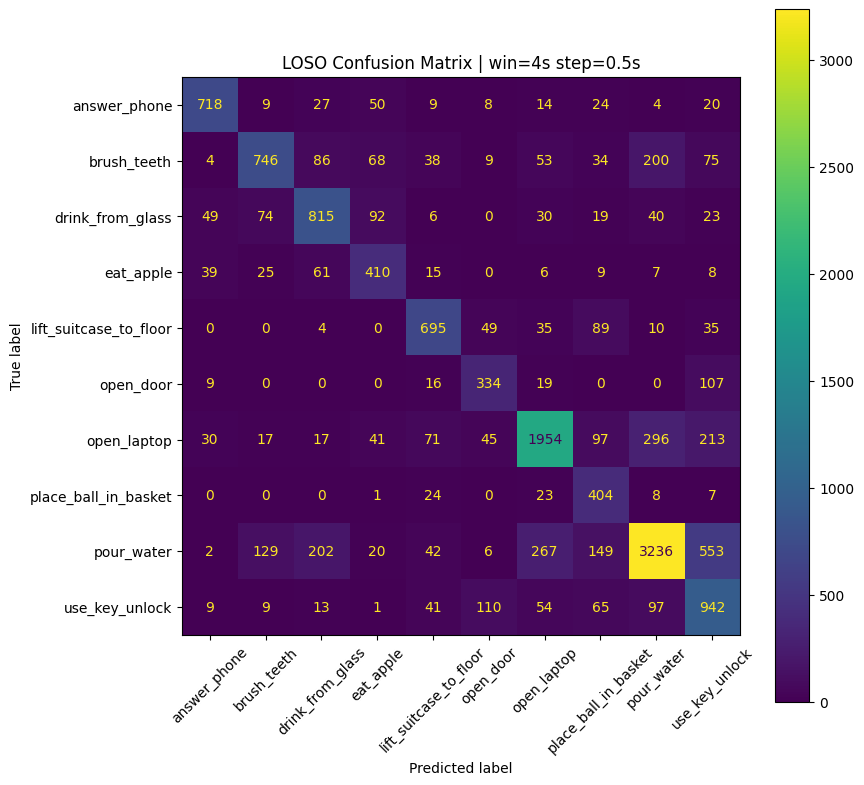

Saved summary CSV: experiment_results/channel_combo_ablation__combo__n-2__jointAngle-sensorFreeAcceleration__win-4s__step-0.5s__20260403_213607__summary.csv
Saved per-fold CSV: experiment_results/channel_combo_ablation__combo__n-2__jointAngle-sensorFreeAcceleration__win-4s__step-0.5s__20260403_213607__folds.csv

Channel combo run 19/63
Using 2 channel(s): ['jointAngleXZY', 'acceleration']
No cached dataset found. Building dataset from MVNX files...
Kept files: 1420 | Skipped files (allowed but failed): 88
X: (14521, 240, 24) y: (14521,) groups: (14521,)
Saved dataset cache to: cached_datasets/dataset_ULF_in_ADL__ch-jointAngleXZY_acceleration__win-4s__step-0.5s__tasks-11-12-13-16-20-21-23-24-28-29.npz
Channel combo (2): jointAngleXZY + acceleration dataset loaded.
Dataset shape: (14521, 240, 24)
Unique subjects: 25
Class counts: {np.str_('answer_phone'): np.int64(883), np.str_('brush_teeth'): np.int64(1313), np.str_('drink_from_glass'): np.int64(1148), np.str_('eat_apple'): np.int64(580

,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
0,1,H01,4.0,0.5,0.875,10981,2987,553,19,5,8,0.655842,0.533454,0.464068
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,11,0.625840,0.808271,0.839974
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,8,0.618815,0.880562,0.859275
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,18,0.616371,0.916058,0.778613
4,5,H05,4.0,0.5,0.875,10888,3274,359,19,5,20,0.641112,0.849582,0.833929
5,6,P02,4.0,0.5,0.875,10563,3274,684,19,5,10,0.597434,0.603801,0.594173
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,14,0.632254,0.868074,0.830628
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,11,0.627062,0.929104,0.932775
8,9,P05,4.0,0.5,0.875,9883,3274,1364,19,5,14,0.618815,0.316716,0.331216
9,10,P06,4.0,0.5,0.875,9883,3758,880,19,5,9,0.528739,0.450000,0.444484



LOSO SUMMARY
Overall window-level accuracy: 0.6718
Overall window-level macro F1: 0.6572
Mean fold accuracy: 0.7211 ± 0.1813
Mean fold macro F1: 0.6874 ± 0.1828

Per-fold results:


,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
12,13,P10,4.0,0.5,0.875,10012,4093,416,19,5,14,0.508918,0.968750,0.966279
16,17,P19,4.0,0.5,0.875,10184,4093,244,19,5,20,0.513315,0.946721,0.860010
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,11,0.627062,0.929104,0.932775
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,18,0.616371,0.916058,0.778613
23,24,P29,4.0,0.5,0.875,10705,3408,408,19,5,9,0.497653,0.914216,0.881961
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,8,0.618815,0.880562,0.859275
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,14,0.632254,0.868074,0.830628
21,22,P25,4.0,0.5,0.875,10625,3408,488,19,5,14,0.609742,0.856557,0.842990
4,5,H05,4.0,0.5,0.875,10888,3274,359,19,5,20,0.641112,0.849582,0.833929
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,11,0.625840,0.808271,0.839974



Classification report across all LOSO test folds:
                        precision    recall  f1-score   support

          answer_phone      0.802     0.749     0.774       883
           brush_teeth      0.656     0.539     0.592      1313
      drink_from_glass      0.640     0.688     0.663      1148
             eat_apple      0.522     0.560     0.540       580
lift_suitcase_to_floor      0.755     0.788     0.771       917
             open_door      0.663     0.584     0.621       485
           open_laptop      0.715     0.679     0.697      2781
  place_ball_in_basket      0.663     0.724     0.692       467
            pour_water      0.785     0.691     0.735      4606
        use_key_unlock      0.394     0.638     0.487      1341

              accuracy                          0.672     14521
             macro avg      0.659     0.664     0.657     14521
          weighted avg      0.693     0.672     0.678     14521



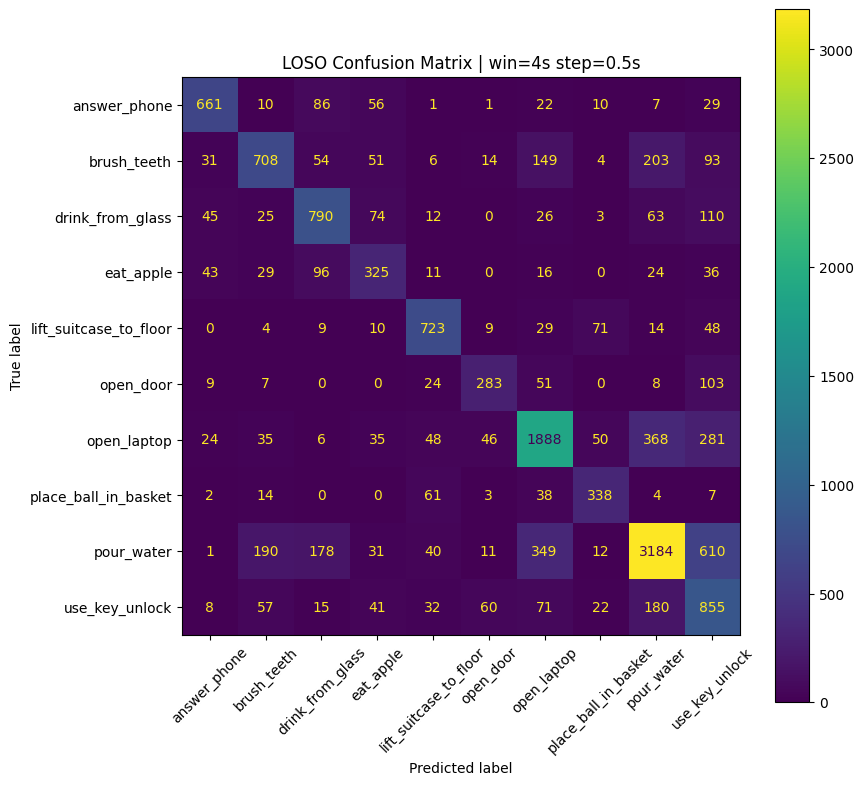

Saved summary CSV: experiment_results/channel_combo_ablation__combo__n-2__jointAngleXZY-acceleration__win-4s__step-0.5s__20260403_215337__summary.csv
Saved per-fold CSV: experiment_results/channel_combo_ablation__combo__n-2__jointAngleXZY-acceleration__win-4s__step-0.5s__20260403_215337__folds.csv

Channel combo run 20/63
Using 2 channel(s): ['jointAngleXZY', 'sensorFreeAcceleration']
No cached dataset found. Building dataset from MVNX files...
Kept files: 1420 | Skipped files (allowed but failed): 88
X: (14521, 240, 24) y: (14521,) groups: (14521,)
Saved dataset cache to: cached_datasets/dataset_ULF_in_ADL__ch-jointAngleXZY_sensorFreeAcceleration__win-4s__step-0.5s__tasks-11-12-13-16-20-21-23-24-28-29.npz
Channel combo (2): jointAngleXZY + sensorFreeAcceleration dataset loaded.
Dataset shape: (14521, 240, 24)
Unique subjects: 25
Class counts: {np.str_('answer_phone'): np.int64(883), np.str_('brush_teeth'): np.int64(1313), np.str_('drink_from_glass'): np.int64(1148), np.str_('eat_apple

,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
0,1,H01,4.0,0.5,0.875,10981,2987,553,19,5,17,0.655507,0.703436,0.700388
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,20,0.631949,0.748120,0.734542
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,16,0.630422,0.953162,0.925830
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,11,0.657911,0.879562,0.710791
4,5,H05,4.0,0.5,0.875,10888,3274,359,19,5,12,0.659743,0.766017,0.737829
5,6,P02,4.0,0.5,0.875,10563,3274,684,19,5,16,0.627673,0.653509,0.646280
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,9,0.635308,0.899736,0.896465
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,17,0.658522,0.884328,0.899416
8,9,P05,4.0,0.5,0.875,9883,3274,1364,19,5,16,0.635003,0.324047,0.290938
9,10,P06,4.0,0.5,0.875,9883,3758,880,19,5,10,0.587813,0.396591,0.364841



LOSO SUMMARY
Overall window-level accuracy: 0.6821
Overall window-level macro F1: 0.6518
Mean fold accuracy: 0.7292 ± 0.1775
Mean fold macro F1: 0.6851 ± 0.1830

Per-fold results:


,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
12,13,P10,4.0,0.5,0.875,10012,4093,416,19,5,13,0.515514,0.963942,0.963677
23,24,P29,4.0,0.5,0.875,10705,3408,408,19,5,20,0.605340,0.958333,0.954954
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,16,0.630422,0.953162,0.925830
16,17,P19,4.0,0.5,0.875,10184,4093,244,19,5,18,0.494014,0.950820,0.854313
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,9,0.635308,0.899736,0.896465
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,17,0.658522,0.884328,0.899416
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,11,0.657911,0.879562,0.710791
21,22,P25,4.0,0.5,0.875,10625,3408,488,19,5,17,0.609448,0.823770,0.757851
14,15,P16,4.0,0.5,0.875,9822,4093,606,19,5,16,0.529196,0.793729,0.772624
22,23,P28,4.0,0.5,0.875,10051,3408,1062,19,5,17,0.627641,0.787194,0.731968



Classification report across all LOSO test folds:
                        precision    recall  f1-score   support

          answer_phone      0.737     0.757     0.747       883
           brush_teeth      0.625     0.568     0.595      1313
      drink_from_glass      0.739     0.631     0.680      1148
             eat_apple      0.485     0.519     0.501       580
lift_suitcase_to_floor      0.645     0.815     0.720       917
             open_door      0.557     0.581     0.569       485
           open_laptop      0.777     0.717     0.746      2781
  place_ball_in_basket      0.665     0.760     0.709       467
            pour_water      0.782     0.712     0.745      4606
        use_key_unlock      0.434     0.603     0.504      1341

              accuracy                          0.682     14521
             macro avg      0.645     0.666     0.652     14521
          weighted avg      0.697     0.682     0.686     14521



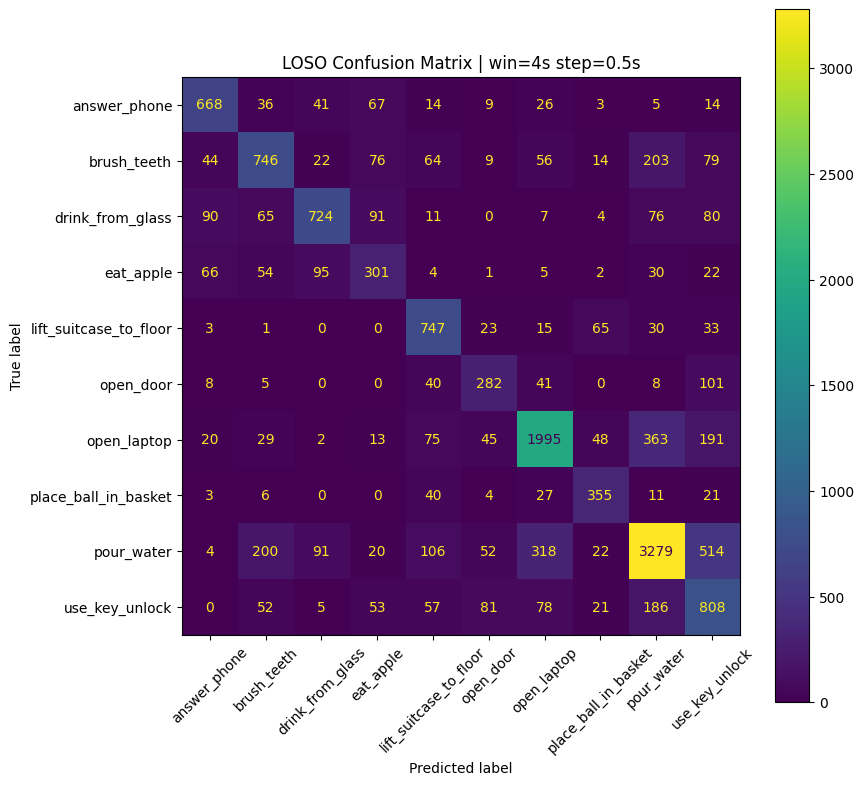

Saved summary CSV: experiment_results/channel_combo_ablation__combo__n-2__jointAngleXZY-sensorFreeAcceleration__win-4s__step-0.5s__20260403_221237__summary.csv
Saved per-fold CSV: experiment_results/channel_combo_ablation__combo__n-2__jointAngleXZY-sensorFreeAcceleration__win-4s__step-0.5s__20260403_221237__folds.csv

Channel combo run 21/63
Using 2 channel(s): ['acceleration', 'sensorFreeAcceleration']
No cached dataset found. Building dataset from MVNX files...
Kept files: 1420 | Skipped files (allowed but failed): 88
X: (14521, 240, 24) y: (14521,) groups: (14521,)
Saved dataset cache to: cached_datasets/dataset_ULF_in_ADL__ch-acceleration_sensorFreeAcceleration__win-4s__step-0.5s__tasks-11-12-13-16-20-21-23-24-28-29.npz
Channel combo (2): acceleration + sensorFreeAcceleration dataset loaded.
Dataset shape: (14521, 240, 24)
Unique subjects: 25
Class counts: {np.str_('answer_phone'): np.int64(883), np.str_('brush_teeth'): np.int64(1313), np.str_('drink_from_glass'): np.int64(1148), n

,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
0,1,H01,4.0,0.5,0.875,10981,2987,553,19,5,20,0.781051,0.873418,0.799831
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,15,0.755651,0.800752,0.791992
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,15,0.699756,0.908665,0.876593
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,20,0.766646,0.963504,0.922275
4,5,H05,4.0,0.5,0.875,10888,3274,359,19,5,20,0.744960,0.727019,0.779324
5,6,P02,4.0,0.5,0.875,10563,3274,684,19,5,20,0.751680,0.786550,0.765724
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,20,0.776726,0.902375,0.832556
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,20,0.748320,0.826493,0.792406
8,9,P05,4.0,0.5,0.875,9883,3274,1364,19,5,15,0.749847,0.460411,0.408082
9,10,P06,4.0,0.5,0.875,9883,3758,880,19,5,20,0.644492,0.609091,0.585148



LOSO SUMMARY
Overall window-level accuracy: 0.7419
Overall window-level macro F1: 0.7155
Mean fold accuracy: 0.7772 ± 0.1504
Mean fold macro F1: 0.7384 ± 0.1832

Per-fold results:


,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
16,17,P19,4.0,0.5,0.875,10184,4093,244,19,5,20,0.653555,0.979508,0.963722
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,20,0.766646,0.963504,0.922275
21,22,P25,4.0,0.5,0.875,10625,3408,488,19,5,20,0.691901,0.944672,0.954000
23,24,P29,4.0,0.5,0.875,10705,3408,408,19,5,20,0.722711,0.943627,0.943143
20,21,P24,4.0,0.5,0.875,10512,3408,601,19,5,20,0.724178,0.943428,0.910550
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,15,0.699756,0.908665,0.876593
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,20,0.776726,0.902375,0.832556
12,13,P10,4.0,0.5,0.875,10012,4093,416,19,5,20,0.655998,0.894231,0.891976
0,1,H01,4.0,0.5,0.875,10981,2987,553,19,5,20,0.781051,0.873418,0.799831
18,19,P21,4.0,0.5,0.875,10500,3525,496,19,5,12,0.646241,0.836694,0.821087



Classification report across all LOSO test folds:
                        precision    recall  f1-score   support

          answer_phone      0.703     0.634     0.667       883
           brush_teeth      0.637     0.602     0.619      1313
      drink_from_glass      0.682     0.743     0.711      1148
             eat_apple      0.690     0.588     0.635       580
lift_suitcase_to_floor      0.796     0.785     0.790       917
             open_door      0.831     0.751     0.789       485
           open_laptop      0.795     0.860     0.826      2781
  place_ball_in_basket      0.792     0.724     0.756       467
            pour_water      0.797     0.790     0.793      4606
        use_key_unlock      0.558     0.579     0.569      1341

              accuracy                          0.742     14521
             macro avg      0.728     0.706     0.716     14521
          weighted avg      0.742     0.742     0.741     14521



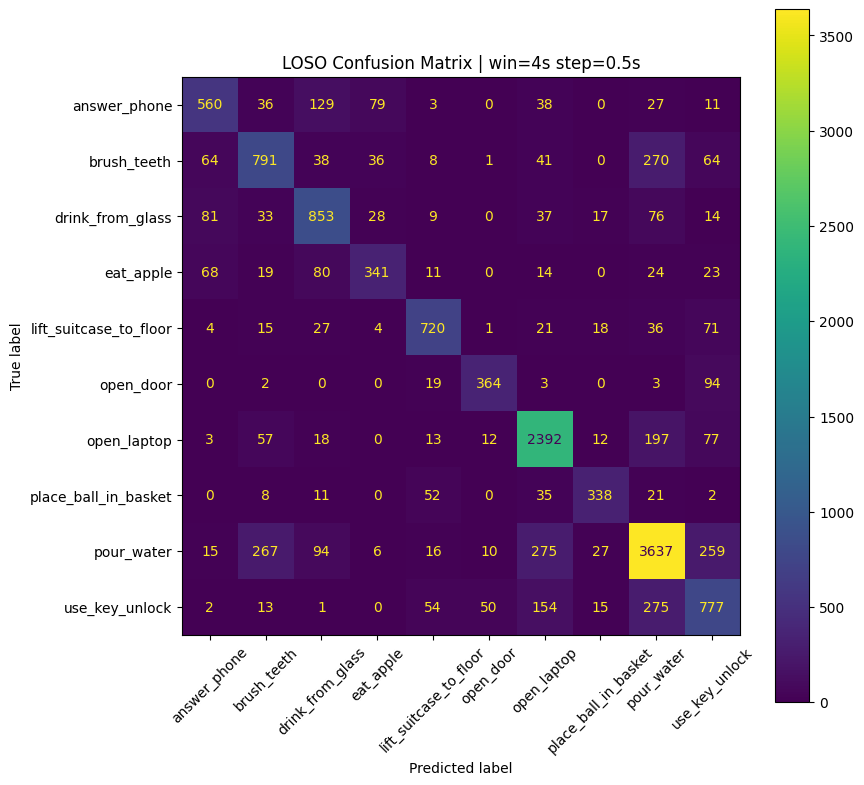

Saved summary CSV: experiment_results/channel_combo_ablation__combo__n-2__acceleration-sensorFreeAcceleration__win-4s__step-0.5s__20260403_223351__summary.csv
Saved per-fold CSV: experiment_results/channel_combo_ablation__combo__n-2__acceleration-sensorFreeAcceleration__win-4s__step-0.5s__20260403_223351__folds.csv

Channel combo run 22/63
Using 3 channel(s): ['velocity', 'angularVelocity', 'jointAngle']
No cached dataset found. Building dataset from MVNX files...
Kept files: 1420 | Skipped files (allowed but failed): 88
X: (14521, 240, 36) y: (14521,) groups: (14521,)
Saved dataset cache to: cached_datasets/dataset_ULF_in_ADL__ch-velocity_angularVelocity_jointAngle__win-4s__step-0.5s__tasks-11-12-13-16-20-21-23-24-28-29.npz
Channel combo (3): velocity + angularVelocity + jointAngle dataset loaded.
Dataset shape: (14521, 240, 36)
Unique subjects: 25
Class counts: {np.str_('answer_phone'): np.int64(883), np.str_('brush_teeth'): np.int64(1313), np.str_('drink_from_glass'): np.int64(1148)

,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
0,1,H01,4.0,0.5,0.875,10981,2987,553,19,5,7,0.692668,0.654611,0.619638
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,9,0.666768,0.913534,0.914249
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,15,0.686927,0.950820,0.924375
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,9,0.724801,0.956204,0.856543
4,5,H05,4.0,0.5,0.875,10888,3274,359,19,5,10,0.693952,0.760446,0.772276
5,6,P02,4.0,0.5,0.875,10563,3274,684,19,5,10,0.666768,0.790936,0.830283
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,9,0.712889,0.949868,0.955802
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,10,0.700367,0.899254,0.909375
8,9,P05,4.0,0.5,0.875,9883,3274,1364,19,5,20,0.690593,0.289589,0.226838
9,10,P06,4.0,0.5,0.875,9883,3758,880,19,5,11,0.606972,0.457955,0.496278



LOSO SUMMARY
Overall window-level accuracy: 0.7185
Overall window-level macro F1: 0.7118
Mean fold accuracy: 0.7661 ± 0.1792
Mean fold macro F1: 0.7434 ± 0.1848

Per-fold results:


,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
12,13,P10,4.0,0.5,0.875,10012,4093,416,19,5,11,0.618373,0.978365,0.979687
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,9,0.724801,0.956204,0.856543
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,15,0.686927,0.950820,0.924375
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,9,0.712889,0.949868,0.955802
23,24,P29,4.0,0.5,0.875,10705,3408,408,19,5,20,0.631455,0.924020,0.905568
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,9,0.666768,0.913534,0.914249
20,21,P24,4.0,0.5,0.875,10512,3408,601,19,5,15,0.607394,0.906822,0.891777
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,10,0.700367,0.899254,0.909375
21,22,P25,4.0,0.5,0.875,10625,3408,488,19,5,11,0.586561,0.893443,0.842393
16,17,P19,4.0,0.5,0.875,10184,4093,244,19,5,9,0.624725,0.885246,0.809939



Classification report across all LOSO test folds:
                        precision    recall  f1-score   support

          answer_phone      0.876     0.841     0.858       883
           brush_teeth      0.554     0.602     0.577      1313
      drink_from_glass      0.750     0.767     0.758      1148
             eat_apple      0.882     0.709     0.786       580
lift_suitcase_to_floor      0.598     0.855     0.703       917
             open_door      0.729     0.637     0.680       485
           open_laptop      0.801     0.722     0.759      2781
  place_ball_in_basket      0.673     0.696     0.684       467
            pour_water      0.824     0.719     0.768      4606
        use_key_unlock      0.468     0.650     0.544      1341

              accuracy                          0.718     14521
             macro avg      0.715     0.720     0.712     14521
          weighted avg      0.740     0.718     0.724     14521



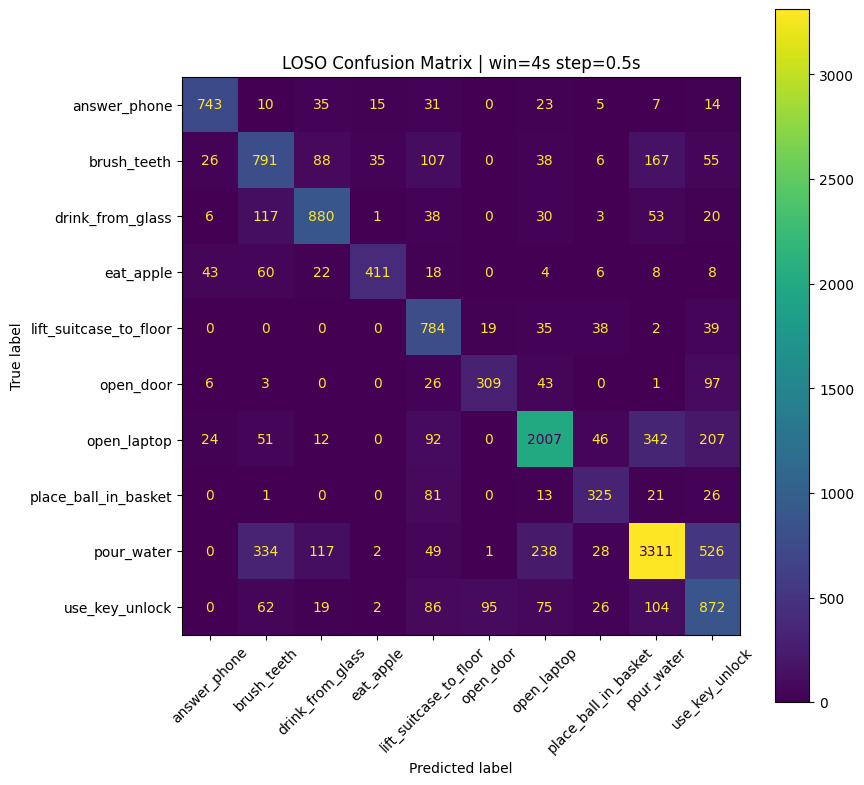

Saved summary CSV: experiment_results/channel_combo_ablation__combo__n-3__velocity-angularVelocity-jointAngle__win-4s__step-0.5s__20260403_225206__summary.csv
Saved per-fold CSV: experiment_results/channel_combo_ablation__combo__n-3__velocity-angularVelocity-jointAngle__win-4s__step-0.5s__20260403_225206__folds.csv

Channel combo run 23/63
Using 3 channel(s): ['velocity', 'angularVelocity', 'jointAngleXZY']
No cached dataset found. Building dataset from MVNX files...
Kept files: 1420 | Skipped files (allowed but failed): 88
X: (14521, 240, 36) y: (14521,) groups: (14521,)
Saved dataset cache to: cached_datasets/dataset_ULF_in_ADL__ch-velocity_angularVelocity_jointAngleXZY__win-4s__step-0.5s__tasks-11-12-13-16-20-21-23-24-28-29.npz
Channel combo (3): velocity + angularVelocity + jointAngleXZY dataset loaded.
Dataset shape: (14521, 240, 36)
Unique subjects: 25
Class counts: {np.str_('answer_phone'): np.int64(883), np.str_('brush_teeth'): np.int64(1313), np.str_('drink_from_glass'): np.in

,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
0,1,H01,4.0,0.5,0.875,10981,2987,553,19,5,10,0.668899,0.766727,0.740956
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,11,0.669517,0.947368,0.924589
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,14,0.669212,0.960187,0.960881
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,9,0.695480,0.974453,0.916053
4,5,H05,4.0,0.5,0.875,10888,3274,359,19,5,9,0.671350,0.752089,0.803962
5,6,P02,4.0,0.5,0.875,10563,3274,684,19,5,17,0.678070,0.717836,0.742249
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,18,0.699756,0.902375,0.888731
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,20,0.670434,0.854478,0.878859
8,9,P05,4.0,0.5,0.875,9883,3274,1364,19,5,12,0.676848,0.331378,0.301457
9,10,P06,4.0,0.5,0.875,9883,3758,880,19,5,17,0.609101,0.393182,0.359130



LOSO SUMMARY
Overall window-level accuracy: 0.7252
Overall window-level macro F1: 0.7216
Mean fold accuracy: 0.7732 ± 0.1783
Mean fold macro F1: 0.7522 ± 0.1900

Per-fold results:


,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,9,0.695480,0.974453,0.916053
23,24,P29,4.0,0.5,0.875,10705,3408,408,19,5,20,0.637617,0.963235,0.964214
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,14,0.669212,0.960187,0.960881
12,13,P10,4.0,0.5,0.875,10012,4093,416,19,5,9,0.616418,0.951923,0.937991
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,11,0.669517,0.947368,0.924589
21,22,P25,4.0,0.5,0.875,10625,3408,488,19,5,20,0.675763,0.936475,0.943238
16,17,P19,4.0,0.5,0.875,10184,4093,244,19,5,12,0.606645,0.918033,0.840040
14,15,P16,4.0,0.5,0.875,9822,4093,606,19,5,15,0.565844,0.904290,0.856731
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,18,0.699756,0.902375,0.888731
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,20,0.670434,0.854478,0.878859



Classification report across all LOSO test folds:
                        precision    recall  f1-score   support

          answer_phone      0.743     0.810     0.775       883
           brush_teeth      0.723     0.538     0.617      1313
      drink_from_glass      0.731     0.778     0.754      1148
             eat_apple      0.806     0.686     0.741       580
lift_suitcase_to_floor      0.784     0.816     0.800       917
             open_door      0.780     0.674     0.723       485
           open_laptop      0.678     0.794     0.731      2781
  place_ball_in_basket      0.774     0.713     0.742       467
            pour_water      0.823     0.723     0.770      4606
        use_key_unlock      0.495     0.650     0.562      1341

              accuracy                          0.725     14521
             macro avg      0.734     0.718     0.722     14521
          weighted avg      0.738     0.725     0.727     14521



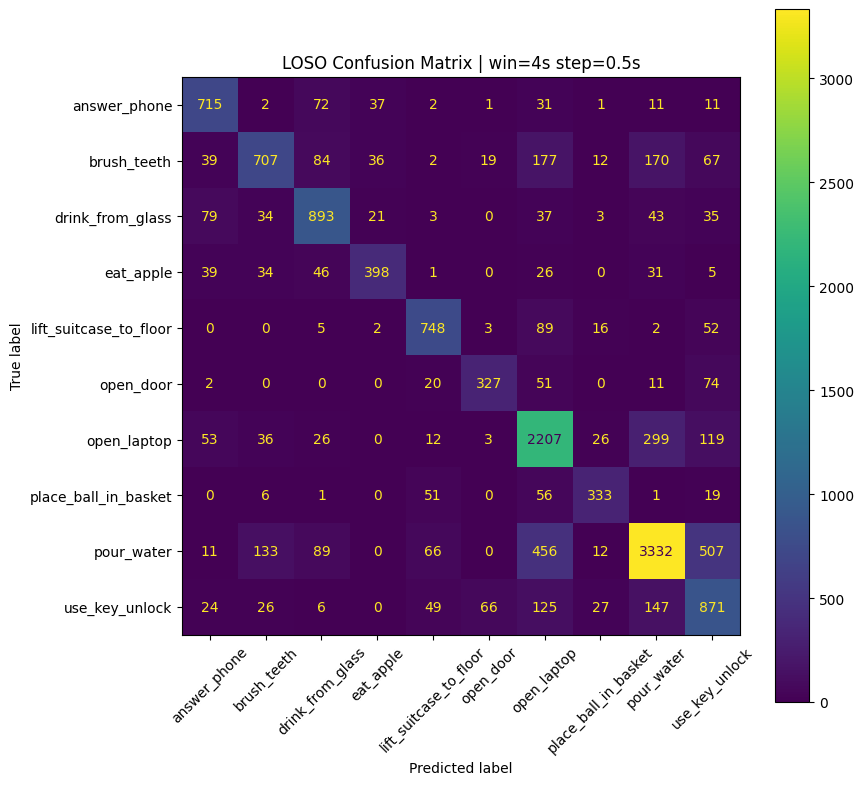

Saved summary CSV: experiment_results/channel_combo_ablation__combo__n-3__velocity-angularVelocity-jointAngleXZY__win-4s__step-0.5s__20260403_231212__summary.csv
Saved per-fold CSV: experiment_results/channel_combo_ablation__combo__n-3__velocity-angularVelocity-jointAngleXZY__win-4s__step-0.5s__20260403_231212__folds.csv

Channel combo run 24/63
Using 3 channel(s): ['velocity', 'angularVelocity', 'acceleration']
No cached dataset found. Building dataset from MVNX files...
Kept files: 1420 | Skipped files (allowed but failed): 88
X: (14521, 240, 36) y: (14521,) groups: (14521,)
Saved dataset cache to: cached_datasets/dataset_ULF_in_ADL__ch-velocity_angularVelocity_acceleration__win-4s__step-0.5s__tasks-11-12-13-16-20-21-23-24-28-29.npz
Channel combo (3): velocity + angularVelocity + acceleration dataset loaded.
Dataset shape: (14521, 240, 36)
Unique subjects: 25
Class counts: {np.str_('answer_phone'): np.int64(883), np.str_('brush_teeth'): np.int64(1313), np.str_('drink_from_glass'): np

,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
0,1,H01,4.0,0.5,0.875,10981,2987,553,19,5,11,0.781051,0.739602,0.735520
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,18,0.816738,0.936090,0.926296
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,20,0.777947,0.934426,0.945376
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,15,0.814905,0.989051,0.954453
4,5,H05,4.0,0.5,0.875,10888,3274,359,19,5,16,0.796274,0.827298,0.840547
5,6,P02,4.0,0.5,0.875,10563,3274,684,19,5,20,0.807575,0.877193,0.871722
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,20,0.795357,0.965699,0.952856
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,15,0.785278,0.927239,0.932195
8,9,P05,4.0,0.5,0.875,9883,3274,1364,19,5,20,0.803299,0.442082,0.432356
9,10,P06,4.0,0.5,0.875,9883,3758,880,19,5,10,0.641565,0.712500,0.674174



LOSO SUMMARY
Overall window-level accuracy: 0.7941
Overall window-level macro F1: 0.7852
Mean fold accuracy: 0.8267 ± 0.1638
Mean fold macro F1: 0.8068 ± 0.1798

Per-fold results:


,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,15,0.814905,0.989051,0.954453
16,17,P19,4.0,0.5,0.875,10184,4093,244,19,5,17,0.695578,0.983607,0.878703
12,13,P10,4.0,0.5,0.875,10012,4093,416,19,5,20,0.701686,0.980769,0.982624
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,20,0.795357,0.965699,0.952856
23,24,P29,4.0,0.5,0.875,10705,3408,408,19,5,20,0.734155,0.950980,0.963996
18,19,P21,4.0,0.5,0.875,10500,3525,496,19,5,17,0.725106,0.945565,0.926306
21,22,P25,4.0,0.5,0.875,10625,3408,488,19,5,20,0.728286,0.942623,0.950324
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,18,0.816738,0.936090,0.926296
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,20,0.777947,0.934426,0.945376
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,15,0.785278,0.927239,0.932195



Classification report across all LOSO test folds:
                        precision    recall  f1-score   support

          answer_phone      0.878     0.740     0.803       883
           brush_teeth      0.819     0.602     0.694      1313
      drink_from_glass      0.712     0.860     0.779      1148
             eat_apple      0.872     0.776     0.821       580
lift_suitcase_to_floor      0.897     0.791     0.841       917
             open_door      0.875     0.753     0.809       485
           open_laptop      0.784     0.860     0.820      2781
  place_ball_in_basket      0.842     0.790     0.815       467
            pour_water      0.860     0.835     0.847      4606
        use_key_unlock      0.554     0.712     0.623      1341

              accuracy                          0.794     14521
             macro avg      0.809     0.772     0.785     14521
          weighted avg      0.806     0.794     0.796     14521



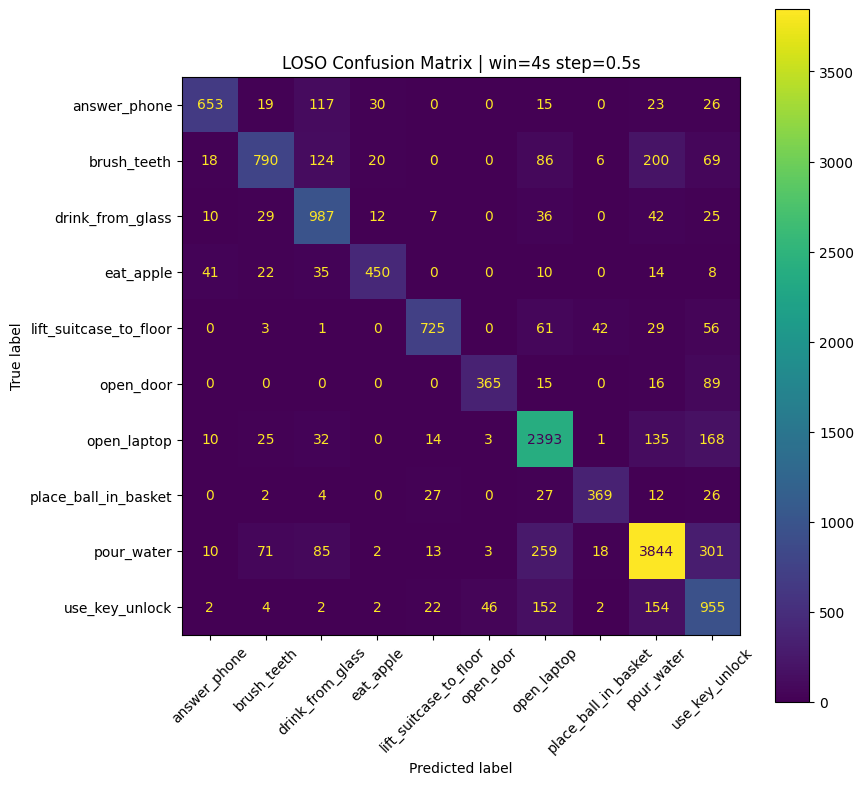

Saved summary CSV: experiment_results/channel_combo_ablation__combo__n-3__velocity-angularVelocity-acceleration__win-4s__step-0.5s__20260403_233408__summary.csv
Saved per-fold CSV: experiment_results/channel_combo_ablation__combo__n-3__velocity-angularVelocity-acceleration__win-4s__step-0.5s__20260403_233408__folds.csv

Channel combo run 25/63
Using 3 channel(s): ['velocity', 'angularVelocity', 'sensorFreeAcceleration']
No cached dataset found. Building dataset from MVNX files...
Kept files: 1420 | Skipped files (allowed but failed): 88
X: (14521, 240, 36) y: (14521,) groups: (14521,)
Saved dataset cache to: cached_datasets/dataset_ULF_in_ADL__ch-velocity_angularVelocity_sensorFreeAcceleration__win-4s__step-0.5s__tasks-11-12-13-16-20-21-23-24-28-29.npz
Channel combo (3): velocity + angularVelocity + sensorFreeAcceleration dataset loaded.
Dataset shape: (14521, 240, 36)
Unique subjects: 25
Class counts: {np.str_('answer_phone'): np.int64(883), np.str_('brush_teeth'): np.int64(1313), np.

,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
0,1,H01,4.0,0.5,0.875,10981,2987,553,19,5,20,0.821225,0.878843,0.855020
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,20,0.818265,0.947368,0.963438
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,15,0.767868,0.953162,0.947976
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,18,0.787721,0.952555,0.911479
4,5,H05,4.0,0.5,0.875,10888,3274,359,19,5,20,0.810018,0.824513,0.834410
5,6,P02,4.0,0.5,0.875,10563,3274,684,19,5,13,0.802382,0.878655,0.885772
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,20,0.810935,0.952507,0.935653
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,19,0.808186,0.914179,0.909145
8,9,P05,4.0,0.5,0.875,9883,3274,1364,19,5,13,0.780391,0.439883,0.416844
9,10,P06,4.0,0.5,0.875,9883,3758,880,19,5,15,0.679351,0.789773,0.738113



LOSO SUMMARY
Overall window-level accuracy: 0.8030
Overall window-level macro F1: 0.7923
Mean fold accuracy: 0.8367 ± 0.1557
Mean fold macro F1: 0.8147 ± 0.1860

Per-fold results:


,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
12,13,P10,4.0,0.5,0.875,10012,4093,416,19,5,20,0.700709,0.990385,0.989146
16,17,P19,4.0,0.5,0.875,10184,4093,244,19,5,20,0.703640,0.979508,0.965745
23,24,P29,4.0,0.5,0.875,10705,3408,408,19,5,17,0.752641,0.975490,0.983120
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,15,0.767868,0.953162,0.947976
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,18,0.787721,0.952555,0.911479
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,20,0.810935,0.952507,0.935653
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,20,0.818265,0.947368,0.963438
21,22,P25,4.0,0.5,0.875,10625,3408,488,19,5,11,0.723298,0.938525,0.946515
14,15,P16,4.0,0.5,0.875,9822,4093,606,19,5,18,0.683606,0.929043,0.889517
18,19,P21,4.0,0.5,0.875,10500,3525,496,19,5,14,0.712624,0.925403,0.919763



Classification report across all LOSO test folds:
                        precision    recall  f1-score   support

          answer_phone      0.912     0.772     0.836       883
           brush_teeth      0.795     0.619     0.696      1313
      drink_from_glass      0.762     0.861     0.808      1148
             eat_apple      0.903     0.771     0.832       580
lift_suitcase_to_floor      0.904     0.818     0.859       917
             open_door      0.811     0.751     0.779       485
           open_laptop      0.823     0.855     0.839      2781
  place_ball_in_basket      0.818     0.771     0.794       467
            pour_water      0.827     0.857     0.842      4606
        use_key_unlock      0.590     0.695     0.638      1341

              accuracy                          0.803     14521
             macro avg      0.814     0.777     0.792     14521
          weighted avg      0.809     0.803     0.803     14521



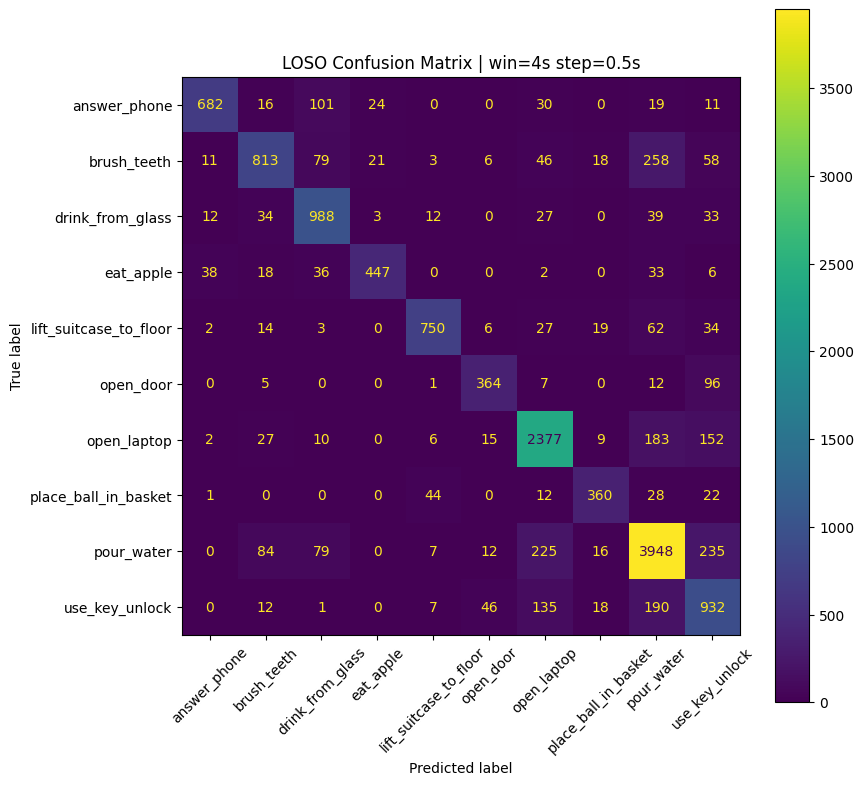

Saved summary CSV: experiment_results/channel_combo_ablation__combo__n-3__velocity-angularVelocity-sensorFreeAcceleration__win-4s__step-0.5s__20260403_235546__summary.csv
Saved per-fold CSV: experiment_results/channel_combo_ablation__combo__n-3__velocity-angularVelocity-sensorFreeAcceleration__win-4s__step-0.5s__20260403_235546__folds.csv

Channel combo run 26/63
Using 3 channel(s): ['velocity', 'jointAngle', 'jointAngleXZY']
No cached dataset found. Building dataset from MVNX files...
Kept files: 1420 | Skipped files (allowed but failed): 88
X: (14521, 240, 36) y: (14521,) groups: (14521,)
Saved dataset cache to: cached_datasets/dataset_ULF_in_ADL__ch-velocity_jointAngle_jointAngleXZY__win-4s__step-0.5s__tasks-11-12-13-16-20-21-23-24-28-29.npz
Channel combo (3): velocity + jointAngle + jointAngleXZY dataset loaded.
Dataset shape: (14521, 240, 36)
Unique subjects: 25
Class counts: {np.str_('answer_phone'): np.int64(883), np.str_('brush_teeth'): np.int64(1313), np.str_('drink_from_glass

,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
0,1,H01,4.0,0.5,0.875,10981,2987,553,19,5,8,0.664546,0.723327,0.637210
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,12,0.640501,0.860902,0.818015
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,13,0.678375,0.913349,0.875181
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,8,0.617593,0.916058,0.780813
4,5,H05,4.0,0.5,0.875,10888,3274,359,19,5,7,0.672266,0.676880,0.712278
5,6,P02,4.0,0.5,0.875,10563,3274,684,19,5,18,0.628589,0.725146,0.708453
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,8,0.633476,0.939314,0.944754
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,8,0.620953,0.772388,0.757503
8,9,P05,4.0,0.5,0.875,9883,3274,1364,19,5,13,0.652108,0.247067,0.246471
9,10,P06,4.0,0.5,0.875,9883,3758,880,19,5,8,0.558808,0.435227,0.462447



LOSO SUMMARY
Overall window-level accuracy: 0.6882
Overall window-level macro F1: 0.6638
Mean fold accuracy: 0.7405 ± 0.1731
Mean fold macro F1: 0.7071 ± 0.1720

Per-fold results:


,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
12,13,P10,4.0,0.5,0.875,10012,4093,416,19,5,13,0.559492,0.968750,0.976671
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,8,0.633476,0.939314,0.944754
16,17,P19,4.0,0.5,0.875,10184,4093,244,19,5,8,0.564134,0.934426,0.865594
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,8,0.617593,0.916058,0.780813
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,13,0.678375,0.913349,0.875181
23,24,P29,4.0,0.5,0.875,10705,3408,408,19,5,9,0.557512,0.892157,0.866462
21,22,P25,4.0,0.5,0.875,10625,3408,488,19,5,20,0.582746,0.866803,0.842557
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,12,0.640501,0.860902,0.818015
14,15,P16,4.0,0.5,0.875,9822,4093,606,19,5,15,0.556804,0.820132,0.753983
20,21,P24,4.0,0.5,0.875,10512,3408,601,19,5,7,0.545775,0.798669,0.718135



Classification report across all LOSO test folds:
                        precision    recall  f1-score   support

          answer_phone      0.854     0.763     0.806       883
           brush_teeth      0.649     0.483     0.554      1313
      drink_from_glass      0.735     0.720     0.727      1148
             eat_apple      0.485     0.681     0.567       580
lift_suitcase_to_floor      0.657     0.817     0.728       917
             open_door      0.575     0.567     0.571       485
           open_laptop      0.810     0.679     0.739      2781
  place_ball_in_basket      0.674     0.745     0.708       467
            pour_water      0.791     0.738     0.763      4606
        use_key_unlock      0.392     0.600     0.474      1341

              accuracy                          0.688     14521
             macro avg      0.662     0.679     0.664     14521
          weighted avg      0.713     0.688     0.695     14521



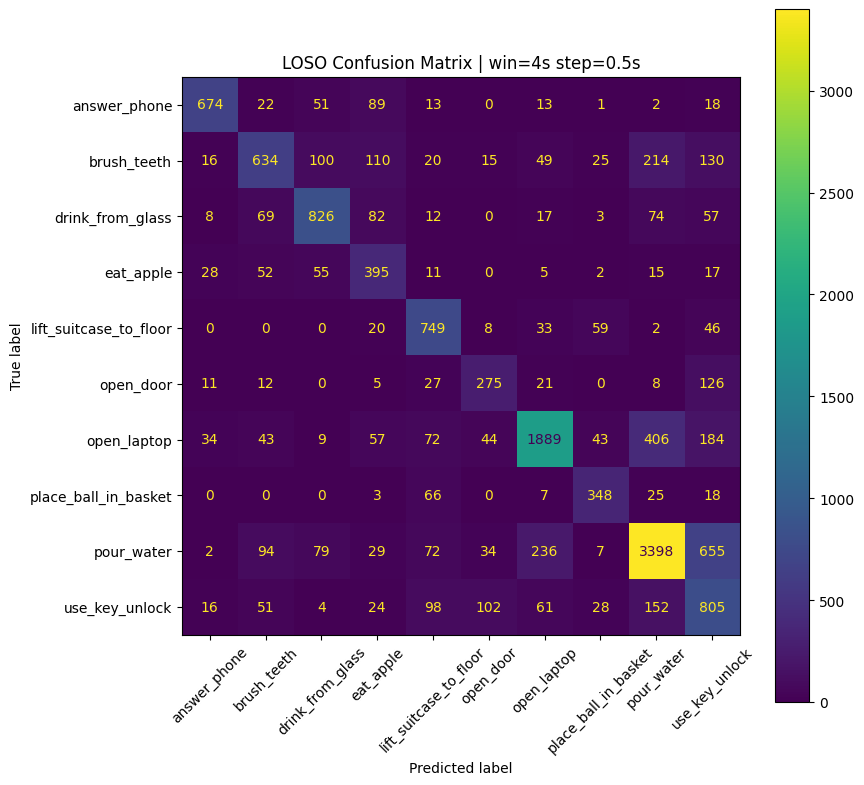

Saved summary CSV: experiment_results/channel_combo_ablation__combo__n-3__velocity-jointAngle-jointAngleXZY__win-4s__step-0.5s__20260404_001317__summary.csv
Saved per-fold CSV: experiment_results/channel_combo_ablation__combo__n-3__velocity-jointAngle-jointAngleXZY__win-4s__step-0.5s__20260404_001317__folds.csv

Channel combo run 27/63
Using 3 channel(s): ['velocity', 'jointAngle', 'acceleration']
No cached dataset found. Building dataset from MVNX files...
Kept files: 1420 | Skipped files (allowed but failed): 88
X: (14521, 240, 36) y: (14521,) groups: (14521,)
Saved dataset cache to: cached_datasets/dataset_ULF_in_ADL__ch-velocity_jointAngle_acceleration__win-4s__step-0.5s__tasks-11-12-13-16-20-21-23-24-28-29.npz
Channel combo (3): velocity + jointAngle + acceleration dataset loaded.
Dataset shape: (14521, 240, 36)
Unique subjects: 25
Class counts: {np.str_('answer_phone'): np.int64(883), np.str_('brush_teeth'): np.int64(1313), np.str_('drink_from_glass'): np.int64(1148), np.str_('ea

,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
0,1,H01,4.0,0.5,0.875,10981,2987,553,19,5,7,0.662203,0.678119,0.628178
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,18,0.667685,0.917293,0.939441
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,15,0.701588,0.946136,0.924327
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,14,0.660660,0.985401,0.922644
4,5,H05,4.0,0.5,0.875,10888,3274,359,19,5,9,0.654856,0.785515,0.813579
5,6,P02,4.0,0.5,0.875,10563,3274,684,19,5,8,0.675015,0.779240,0.780545
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,15,0.678681,0.968338,0.973566
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,13,0.654551,0.886194,0.903357
8,9,P05,4.0,0.5,0.875,9883,3274,1364,19,5,20,0.680513,0.288856,0.299036
9,10,P06,4.0,0.5,0.875,9883,3758,880,19,5,19,0.601384,0.445455,0.519891



LOSO SUMMARY
Overall window-level accuracy: 0.7154
Overall window-level macro F1: 0.6998
Mean fold accuracy: 0.7663 ± 0.1858
Mean fold macro F1: 0.7454 ± 0.1883

Per-fold results:


,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,14,0.660660,0.985401,0.922644
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,15,0.678681,0.968338,0.973566
12,13,P10,4.0,0.5,0.875,10012,4093,416,19,5,19,0.633032,0.947115,0.936147
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,15,0.701588,0.946136,0.924327
21,22,P25,4.0,0.5,0.875,10625,3408,488,19,5,13,0.612089,0.938525,0.916998
23,24,P29,4.0,0.5,0.875,10705,3408,408,19,5,20,0.635270,0.933824,0.910940
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,18,0.667685,0.917293,0.939441
16,17,P19,4.0,0.5,0.875,10184,4093,244,19,5,10,0.587589,0.905738,0.841584
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,13,0.654551,0.886194,0.903357
20,21,P24,4.0,0.5,0.875,10512,3408,601,19,5,20,0.601819,0.871880,0.809986



Classification report across all LOSO test folds:
                        precision    recall  f1-score   support

          answer_phone      0.870     0.734     0.796       883
           brush_teeth      0.605     0.590     0.598      1313
      drink_from_glass      0.630     0.760     0.689      1148
             eat_apple      0.681     0.703     0.692       580
lift_suitcase_to_floor      0.723     0.857     0.784       917
             open_door      0.714     0.699     0.706       485
           open_laptop      0.781     0.723     0.751      2781
  place_ball_in_basket      0.579     0.764     0.659       467
            pour_water      0.820     0.732     0.774      4606
        use_key_unlock      0.498     0.611     0.549      1341

              accuracy                          0.715     14521
             macro avg      0.690     0.717     0.700     14521
          weighted avg      0.728     0.715     0.719     14521



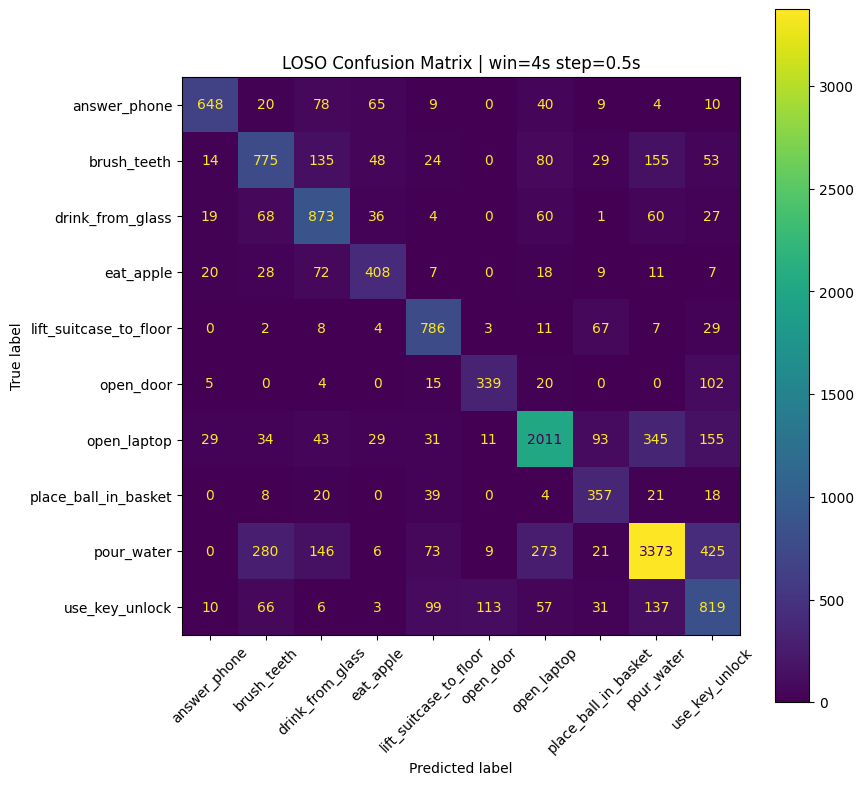

Saved summary CSV: experiment_results/channel_combo_ablation__combo__n-3__velocity-jointAngle-acceleration__win-4s__step-0.5s__20260404_003306__summary.csv
Saved per-fold CSV: experiment_results/channel_combo_ablation__combo__n-3__velocity-jointAngle-acceleration__win-4s__step-0.5s__20260404_003306__folds.csv

Channel combo run 28/63
Using 3 channel(s): ['velocity', 'jointAngle', 'sensorFreeAcceleration']
No cached dataset found. Building dataset from MVNX files...
Kept files: 1420 | Skipped files (allowed but failed): 88
X: (14521, 240, 36) y: (14521,) groups: (14521,)
Saved dataset cache to: cached_datasets/dataset_ULF_in_ADL__ch-velocity_jointAngle_sensorFreeAcceleration__win-4s__step-0.5s__tasks-11-12-13-16-20-21-23-24-28-29.npz
Channel combo (3): velocity + jointAngle + sensorFreeAcceleration dataset loaded.
Dataset shape: (14521, 240, 36)
Unique subjects: 25
Class counts: {np.str_('answer_phone'): np.int64(883), np.str_('brush_teeth'): np.int64(1313), np.str_('drink_from_glass'):

,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
0,1,H01,4.0,0.5,0.875,10981,2987,553,19,5,20,0.695347,0.824593,0.788307
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,16,0.668296,0.947368,0.960299
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,12,0.660965,0.878220,0.883332
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,20,0.682651,0.956204,0.813871
4,5,H05,4.0,0.5,0.875,10888,3274,359,19,5,10,0.673183,0.623955,0.645387
5,6,P02,4.0,0.5,0.875,10563,3274,684,19,5,10,0.656384,0.773392,0.812222
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,14,0.646915,0.981530,0.978132
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,11,0.683873,0.871269,0.872929
8,9,P05,4.0,0.5,0.875,9883,3274,1364,19,5,15,0.687538,0.269062,0.285959
9,10,P06,4.0,0.5,0.875,9883,3758,880,19,5,12,0.537254,0.442045,0.408549



LOSO SUMMARY
Overall window-level accuracy: 0.7066
Overall window-level macro F1: 0.6830
Mean fold accuracy: 0.7595 ± 0.1876
Mean fold macro F1: 0.7360 ± 0.1978

Per-fold results:


,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
23,24,P29,4.0,0.5,0.875,10705,3408,408,19,5,20,0.578345,0.990196,0.995105
12,13,P10,4.0,0.5,0.875,10012,4093,416,19,5,12,0.579037,0.987981,0.989901
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,14,0.646915,0.981530,0.978132
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,20,0.682651,0.956204,0.813871
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,16,0.668296,0.947368,0.960299
16,17,P19,4.0,0.5,0.875,10184,4093,244,19,5,15,0.568776,0.922131,0.970231
20,21,P24,4.0,0.5,0.875,10512,3408,601,19,5,18,0.556045,0.891847,0.840455
21,22,P25,4.0,0.5,0.875,10625,3408,488,19,5,17,0.637911,0.885246,0.868321
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,12,0.660965,0.878220,0.883332
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,11,0.683873,0.871269,0.872929



Classification report across all LOSO test folds:
                        precision    recall  f1-score   support

          answer_phone      0.910     0.792     0.847       883
           brush_teeth      0.674     0.585     0.626      1313
      drink_from_glass      0.625     0.753     0.684      1148
             eat_apple      0.577     0.695     0.631       580
lift_suitcase_to_floor      0.755     0.761     0.758       917
             open_door      0.679     0.563     0.616       485
           open_laptop      0.805     0.694     0.745      2781
  place_ball_in_basket      0.487     0.797     0.604       467
            pour_water      0.799     0.733     0.765      4606
        use_key_unlock      0.483     0.652     0.555      1341

              accuracy                          0.707     14521
             macro avg      0.679     0.703     0.683     14521
          weighted avg      0.727     0.707     0.712     14521



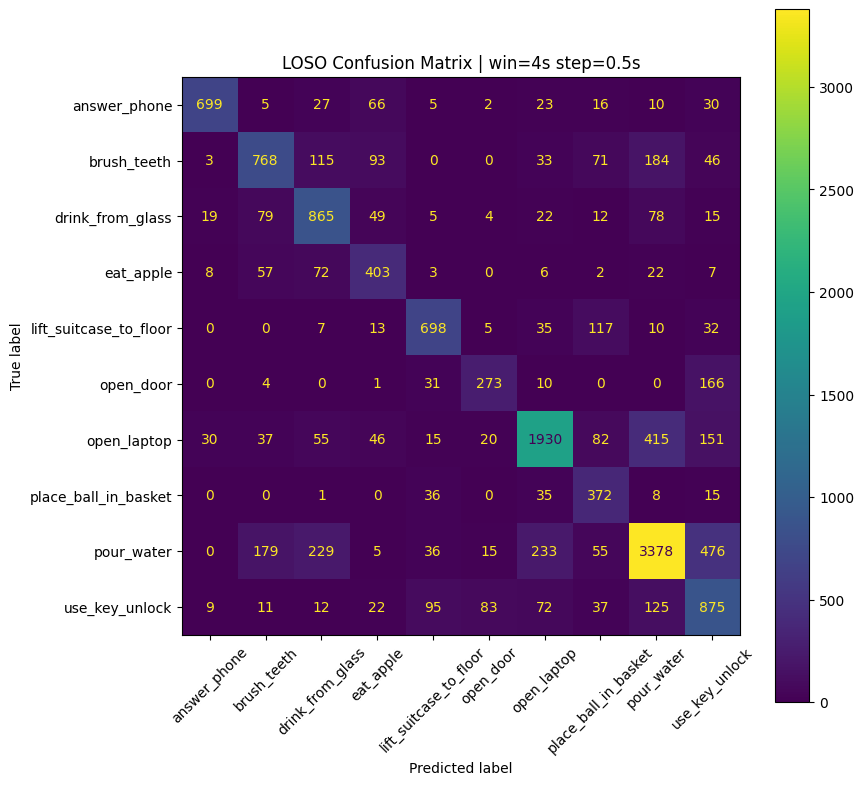

Saved summary CSV: experiment_results/channel_combo_ablation__combo__n-3__velocity-jointAngle-sensorFreeAcceleration__win-4s__step-0.5s__20260404_005241__summary.csv
Saved per-fold CSV: experiment_results/channel_combo_ablation__combo__n-3__velocity-jointAngle-sensorFreeAcceleration__win-4s__step-0.5s__20260404_005241__folds.csv

Channel combo run 29/63
Using 3 channel(s): ['velocity', 'jointAngleXZY', 'acceleration']
No cached dataset found. Building dataset from MVNX files...
Kept files: 1420 | Skipped files (allowed but failed): 88
X: (14521, 240, 36) y: (14521,) groups: (14521,)
Saved dataset cache to: cached_datasets/dataset_ULF_in_ADL__ch-velocity_jointAngleXZY_acceleration__win-4s__step-0.5s__tasks-11-12-13-16-20-21-23-24-28-29.npz
Channel combo (3): velocity + jointAngleXZY + acceleration dataset loaded.
Dataset shape: (14521, 240, 36)
Unique subjects: 25
Class counts: {np.str_('answer_phone'): np.int64(883), np.str_('brush_teeth'): np.int64(1313), np.str_('drink_from_glass'): 

,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
0,1,H01,4.0,0.5,0.875,10981,2987,553,19,5,11,0.656177,0.784810,0.784476
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,11,0.654246,0.879699,0.933564
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,11,0.662492,0.934426,0.916763
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,11,0.641723,0.890511,0.703213
4,5,H05,4.0,0.5,0.875,10888,3274,359,19,5,16,0.681124,0.813370,0.844384
5,6,P02,4.0,0.5,0.875,10563,3274,684,19,5,11,0.652413,0.616959,0.619724
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,11,0.636836,0.907652,0.863567
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,13,0.640806,0.925373,0.921584
8,9,P05,4.0,0.5,0.875,9883,3274,1364,19,5,20,0.676848,0.339443,0.360463
9,10,P06,4.0,0.5,0.875,9883,3758,880,19,5,14,0.598191,0.417045,0.375751



LOSO SUMMARY
Overall window-level accuracy: 0.6958
Overall window-level macro F1: 0.6819
Mean fold accuracy: 0.7467 ± 0.1814
Mean fold macro F1: 0.7134 ± 0.1857

Per-fold results:


,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
12,13,P10,4.0,0.5,0.875,10012,4093,416,19,5,20,0.563157,0.975962,0.974822
23,24,P29,4.0,0.5,0.875,10705,3408,408,19,5,20,0.601819,0.960784,0.942939
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,11,0.662492,0.934426,0.916763
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,13,0.640806,0.925373,0.921584
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,11,0.636836,0.907652,0.863567
16,17,P19,4.0,0.5,0.875,10184,4093,244,19,5,11,0.540679,0.901639,0.742217
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,11,0.641723,0.890511,0.703213
21,22,P25,4.0,0.5,0.875,10625,3408,488,19,5,20,0.636737,0.885246,0.849040
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,11,0.654246,0.879699,0.933564
14,15,P16,4.0,0.5,0.875,9822,4093,606,19,5,11,0.557049,0.854785,0.761976



Classification report across all LOSO test folds:
                        precision    recall  f1-score   support

          answer_phone      0.834     0.776     0.804       883
           brush_teeth      0.680     0.564     0.617      1313
      drink_from_glass      0.739     0.704     0.721      1148
             eat_apple      0.564     0.571     0.567       580
lift_suitcase_to_floor      0.858     0.804     0.830       917
             open_door      0.755     0.553     0.638       485
           open_laptop      0.696     0.714     0.705      2781
  place_ball_in_basket      0.642     0.726     0.681       467
            pour_water      0.785     0.730     0.756      4606
        use_key_unlock      0.413     0.632     0.499      1341

              accuracy                          0.696     14521
             macro avg      0.697     0.677     0.682     14521
          weighted avg      0.714     0.696     0.701     14521



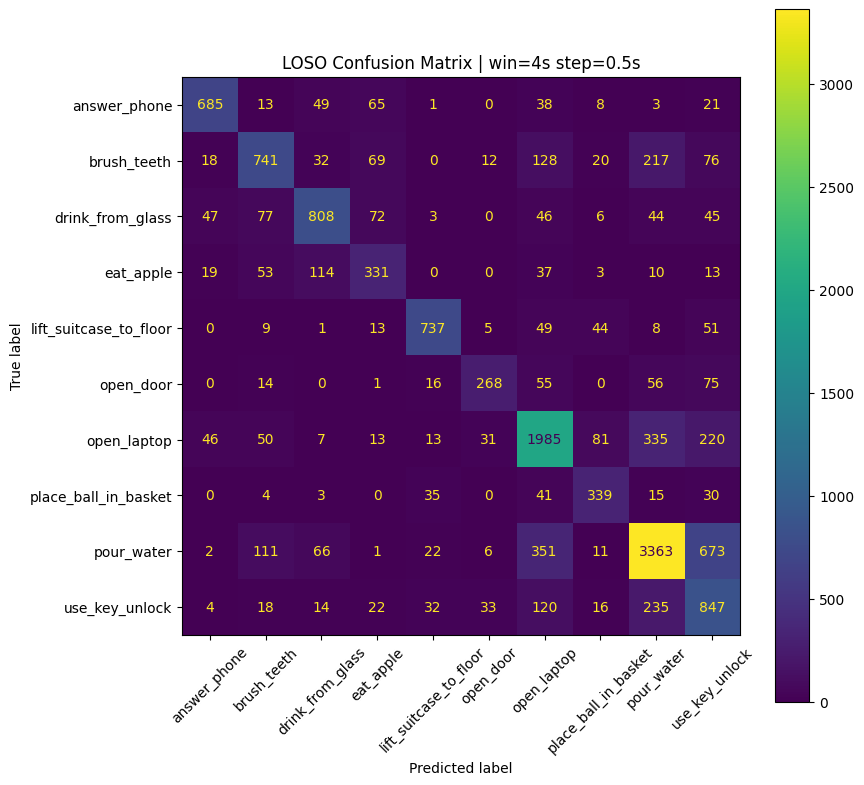

Saved summary CSV: experiment_results/channel_combo_ablation__combo__n-3__velocity-jointAngleXZY-acceleration__win-4s__step-0.5s__20260404_011228__summary.csv
Saved per-fold CSV: experiment_results/channel_combo_ablation__combo__n-3__velocity-jointAngleXZY-acceleration__win-4s__step-0.5s__20260404_011228__folds.csv

Channel combo run 30/63
Using 3 channel(s): ['velocity', 'jointAngleXZY', 'sensorFreeAcceleration']
No cached dataset found. Building dataset from MVNX files...
Kept files: 1420 | Skipped files (allowed but failed): 88
X: (14521, 240, 36) y: (14521,) groups: (14521,)
Saved dataset cache to: cached_datasets/dataset_ULF_in_ADL__ch-velocity_jointAngleXZY_sensorFreeAcceleration__win-4s__step-0.5s__tasks-11-12-13-16-20-21-23-24-28-29.npz
Channel combo (3): velocity + jointAngleXZY + sensorFreeAcceleration dataset loaded.
Dataset shape: (14521, 240, 36)
Unique subjects: 25
Class counts: {np.str_('answer_phone'): np.int64(883), np.str_('brush_teeth'): np.int64(1313), np.str_('drin

,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
0,1,H01,4.0,0.5,0.875,10981,2987,553,19,5,10,0.682959,0.703436,0.703313
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,19,0.689371,0.943609,0.963046
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,12,0.662798,0.943794,0.937820
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,9,0.676237,0.978102,0.915674
4,5,H05,4.0,0.5,0.875,10888,3274,359,19,5,10,0.667685,0.752089,0.794719
5,6,P02,4.0,0.5,0.875,10563,3274,684,19,5,16,0.672572,0.678363,0.649249
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,15,0.700061,0.873351,0.819941
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,18,0.662492,0.906716,0.930888
8,9,P05,4.0,0.5,0.875,9883,3274,1364,19,5,15,0.629811,0.329179,0.337866
9,10,P06,4.0,0.5,0.875,9883,3758,880,19,5,16,0.572645,0.398864,0.383444



LOSO SUMMARY
Overall window-level accuracy: 0.6954
Overall window-level macro F1: 0.6740
Mean fold accuracy: 0.7501 ± 0.1757
Mean fold macro F1: 0.7098 ± 0.1879

Per-fold results:


,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,9,0.676237,0.978102,0.915674
23,24,P29,4.0,0.5,0.875,10705,3408,408,19,5,20,0.620305,0.960784,0.942424
12,13,P10,4.0,0.5,0.875,10012,4093,416,19,5,10,0.541412,0.947115,0.940330
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,12,0.662798,0.943794,0.937820
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,19,0.689371,0.943609,0.963046
16,17,P19,4.0,0.5,0.875,10184,4093,244,19,5,17,0.551674,0.918033,0.771084
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,18,0.662492,0.906716,0.930888
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,15,0.700061,0.873351,0.819941
21,22,P25,4.0,0.5,0.875,10625,3408,488,19,5,14,0.637911,0.866803,0.823872
13,14,P12,4.0,0.5,0.875,9687,4093,741,19,5,20,0.566088,0.815115,0.819574



Classification report across all LOSO test folds:
                        precision    recall  f1-score   support

          answer_phone      0.781     0.736     0.758       883
           brush_teeth      0.700     0.532     0.605      1313
      drink_from_glass      0.716     0.695     0.705      1148
             eat_apple      0.582     0.628     0.604       580
lift_suitcase_to_floor      0.827     0.819     0.823       917
             open_door      0.591     0.569     0.580       485
           open_laptop      0.723     0.728     0.725      2781
  place_ball_in_basket      0.595     0.756     0.666       467
            pour_water      0.774     0.725     0.749      4606
        use_key_unlock      0.452     0.628     0.525      1341

              accuracy                          0.695     14521
             macro avg      0.674     0.682     0.674     14521
          weighted avg      0.707     0.695     0.698     14521



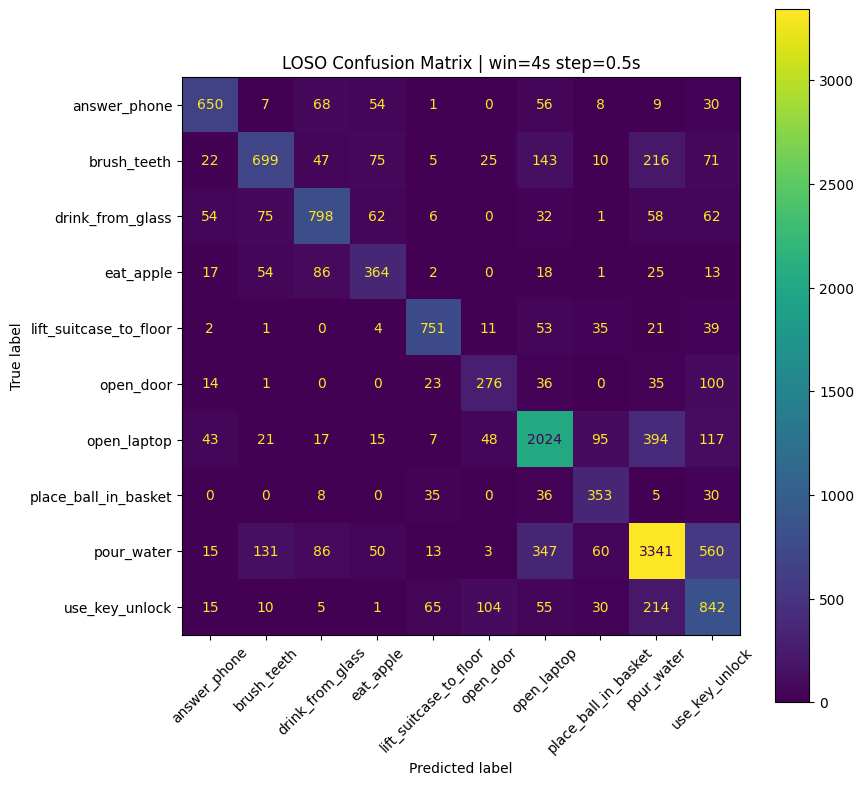

Saved summary CSV: experiment_results/channel_combo_ablation__combo__n-3__velocity-jointAngleXZY-sensorFreeAcceleration__win-4s__step-0.5s__20260404_013200__summary.csv
Saved per-fold CSV: experiment_results/channel_combo_ablation__combo__n-3__velocity-jointAngleXZY-sensorFreeAcceleration__win-4s__step-0.5s__20260404_013200__folds.csv

Channel combo run 31/63
Using 3 channel(s): ['velocity', 'acceleration', 'sensorFreeAcceleration']
No cached dataset found. Building dataset from MVNX files...
Kept files: 1420 | Skipped files (allowed but failed): 88
X: (14521, 240, 36) y: (14521,) groups: (14521,)
Saved dataset cache to: cached_datasets/dataset_ULF_in_ADL__ch-velocity_acceleration_sensorFreeAcceleration__win-4s__step-0.5s__tasks-11-12-13-16-20-21-23-24-28-29.npz
Channel combo (3): velocity + acceleration + sensorFreeAcceleration dataset loaded.
Dataset shape: (14521, 240, 36)
Unique subjects: 25
Class counts: {np.str_('answer_phone'): np.int64(883), np.str_('brush_teeth'): np.int64(131

,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
0,1,H01,4.0,0.5,0.875,10981,2987,553,19,5,20,0.774356,0.723327,0.692937
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,20,0.789859,0.936090,0.956451
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,20,0.778558,0.946136,0.942185
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,18,0.750153,0.937956,0.913623
4,5,H05,4.0,0.5,0.875,10888,3274,359,19,5,20,0.773671,0.824513,0.862312
5,6,P02,4.0,0.5,0.875,10563,3274,684,19,5,20,0.768173,0.817251,0.804540
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,20,0.793219,0.878628,0.801821
7,8,P04,4.0,0.5,0.875,10711,3274,536,19,5,20,0.777947,0.863806,0.820058
8,9,P05,4.0,0.5,0.875,9883,3274,1364,19,5,20,0.754429,0.390029,0.364766
9,10,P06,4.0,0.5,0.875,9883,3758,880,19,5,16,0.648483,0.676136,0.644065



LOSO SUMMARY
Overall window-level accuracy: 0.7637
Overall window-level macro F1: 0.7418
Mean fold accuracy: 0.7957 ± 0.1586
Mean fold macro F1: 0.7623 ± 0.1878

Per-fold results:


,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
18,19,P21,4.0,0.5,0.875,10500,3525,496,19,5,15,0.670355,0.953629,0.953152
2,3,H03,4.0,0.5,0.875,10820,3274,427,19,5,20,0.778558,0.946136,0.942185
3,4,H04,4.0,0.5,0.875,10973,3274,274,19,5,18,0.750153,0.937956,0.913623
1,2,H02,4.0,0.5,0.875,10981,3274,266,19,5,20,0.789859,0.936090,0.956451
16,17,P19,4.0,0.5,0.875,10184,4093,244,19,5,20,0.642072,0.934426,0.876391
12,13,P10,4.0,0.5,0.875,10012,4093,416,19,5,13,0.626680,0.920673,0.896304
23,24,P29,4.0,0.5,0.875,10705,3408,408,19,5,13,0.672829,0.916667,0.931796
20,21,P24,4.0,0.5,0.875,10512,3408,601,19,5,20,0.711561,0.913478,0.867815
21,22,P25,4.0,0.5,0.875,10625,3408,488,19,5,14,0.682218,0.889344,0.874231
6,7,P03,4.0,0.5,0.875,10868,3274,379,19,5,20,0.793219,0.878628,0.801821



Classification report across all LOSO test folds:
                        precision    recall  f1-score   support

          answer_phone      0.772     0.650     0.706       883
           brush_teeth      0.856     0.624     0.722      1313
      drink_from_glass      0.595     0.826     0.692      1148
             eat_apple      0.737     0.603     0.664       580
lift_suitcase_to_floor      0.889     0.843     0.865       917
             open_door      0.803     0.645     0.715       485
           open_laptop      0.829     0.811     0.820      2781
  place_ball_in_basket      0.920     0.739     0.819       467
            pour_water      0.818     0.822     0.820      4606
        use_key_unlock      0.524     0.690     0.595      1341

              accuracy                          0.764     14521
             macro avg      0.774     0.725     0.742     14521
          weighted avg      0.780     0.764     0.766     14521



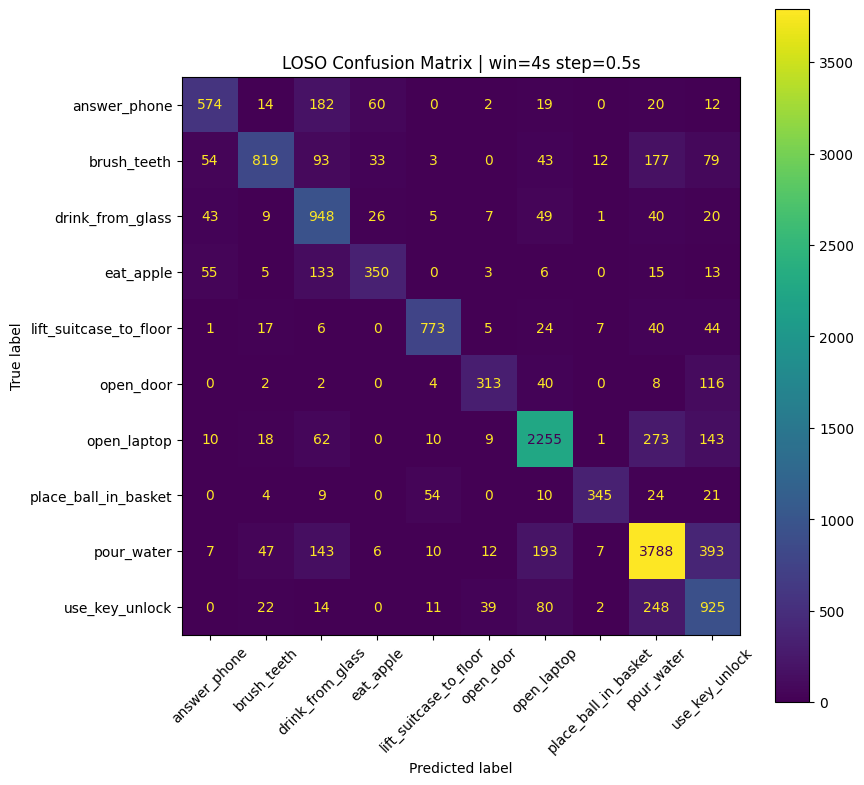

Saved summary CSV: experiment_results/channel_combo_ablation__combo__n-3__velocity-acceleration-sensorFreeAcceleration__win-4s__step-0.5s__20260404_015408__summary.csv
Saved per-fold CSV: experiment_results/channel_combo_ablation__combo__n-3__velocity-acceleration-sensorFreeAcceleration__win-4s__step-0.5s__20260404_015408__folds.csv

Channel combo run 32/63
Using 3 channel(s): ['angularVelocity', 'jointAngle', 'jointAngleXZY']
No cached dataset found. Building dataset from MVNX files...


In [ ]:
from sklearn.metrics import f1_score

def run_loso_experiment(
    X,
    y,
    groups,
    study_name: str,
    win_len_s: float,
    step_s: float,
    plot_first_fold_curves: bool = PLOT_FIRST_FOLD_CURVES,
    loso_max_folds = LOSO_MAX_FOLDS,
    save_per_fold_csv: bool = SAVE_PER_FOLD_CSV,
    results_dir: str = RESULTS_DIR,
):
    labels, lab2i, i2lab, y_i = encode_labels(y)
    all_loso_splits = build_loso_splits(X, y_i, groups, max_folds=loso_max_folds)

    print(f"Total LOSO folds to run: {len(all_loso_splits)}")
    print("Classes:", labels)
    print("Subjects:", sorted(np.unique(groups)))

    fold_rows = []
    all_y_true = []
    all_y_pred = []
    first_fold_history = None

    for fold_idx, (trainval_idx, test_idx) in enumerate(all_loso_splits, start=1):
        held_out_subject = np.unique(groups[test_idx])
        if len(held_out_subject) != 1:
            raise RuntimeError("LOSO fold should contain exactly one held-out subject.")
        held_out_subject = held_out_subject[0]

        print("=" * 90)
        print(f"LOSO fold {fold_idx}/{len(all_loso_splits)} | test subject: {held_out_subject}")

        # Outer split: one subject held out for test
        X_trainval_raw, X_test_raw = X[trainval_idx], X[test_idx]
        y_trainval_i, y_test_i = y_i[trainval_idx], y_i[test_idx]
        g_trainval, g_test = groups[trainval_idx], groups[test_idx]

        # Inner grouped split for validation (training subjects only)
        train_sub_idx, val_sub_idx = make_grouped_train_val_split(g_trainval, val_size=VAL_SIZE, random_state=RANDOM_STATE)

        X_train_raw, X_val_raw = X_trainval_raw[train_sub_idx], X_trainval_raw[val_sub_idx]
        y_train_i, y_val_i = y_trainval_i[train_sub_idx], y_trainval_i[val_sub_idx]
        g_train, g_val = g_trainval[train_sub_idx], g_trainval[val_sub_idx]

        print(f"Train subjects: {sorted(np.unique(g_train))}")
        print(f"Val subjects:   {sorted(np.unique(g_val))}")
        print(f"Test subject:   {sorted(np.unique(g_test))}")

        # Fit normalization on TRAIN ONLY, then apply to val/test
        mu, sd = fit_channel_zscore(X_train_raw)
        X_train = apply_channel_zscore(X_train_raw, mu, sd)
        X_val   = apply_channel_zscore(X_val_raw, mu, sd)
        X_test  = apply_channel_zscore(X_test_raw, mu, sd)

        # Leakage checks
        report_split_integrity("train", X_train, g_train, trainval_idx[train_sub_idx],
                            "val", X_val, g_val, trainval_idx[val_sub_idx])
        report_split_integrity("train", X_train, g_train, trainval_idx[train_sub_idx],
                            "test", X_test, g_test, test_idx)
        report_split_integrity("val", X_val, g_val, trainval_idx[val_sub_idx],
                            "test", X_test, g_test, test_idx)

        train_ds, val_ds, test_ds, train_loader, val_loader, test_loader = make_loaders(
            X_train, y_train_i, X_val, y_val_i, X_test, y_test_i
        )

        model, criterion, optimizer = build_model_and_training_objects(
            in_channels=train_ds.X.shape[1],
            y_train_i=y_train_i,
        )

        train_losses, val_losses, test_losses = [], [], []
        train_accs, val_accs, test_accs = [], [], []

        epochs_ran = 0
        best_val_acc = -1.0
        best_state = None
        patience_counter = 0

        for epoch in range(1, EPOCHS + 1):
            epochs_ran = epoch
            model.train()
            total_loss = 0.0
            ys, ps = [], []

            for xb, yb in train_loader:
                xb = xb.to(device)
                yb = yb.to(device)

                optimizer.zero_grad()
                logits = model(xb)
                loss = criterion(logits, yb)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

                total_loss += loss.item() * xb.size(0)
                pred = torch.argmax(logits, dim=1)
                ys.append(yb.cpu().numpy())
                ps.append(pred.detach().cpu().numpy())

            train_loss = total_loss / len(train_loader.dataset)
            train_acc = accuracy_score(np.concatenate(ys), np.concatenate(ps))

            val_loss, val_acc = run_eval_loss_acc(model, val_loader, criterion)
            test_loss, test_acc = run_eval_loss_acc(model, test_loader, criterion)

            train_losses.append(train_loss)
            val_losses.append(val_loss)
            test_losses.append(test_loss)

            train_accs.append(train_acc)
            val_accs.append(val_acc)
            test_accs.append(test_acc)

            print(
                f"Epoch {epoch:02d} | "
                f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
                f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | "
                f"test_loss={test_loss:.4f} test_acc={test_acc:.4f}"
            )

            improvement = val_acc - best_val_acc
            if improvement > EARLY_STOPPING_MIN_DELTA:
                best_val_acc = val_acc
                best_state = copy.deepcopy(model.state_dict())
                patience_counter = 0
            else:
                patience_counter += 1
                print(
                    f"  No validation improvement greater than {EARLY_STOPPING_MIN_DELTA:.4f}. "
                    f"Patience: {patience_counter}/{EARLY_STOPPING_PATIENCE}"
                )
                if patience_counter >= EARLY_STOPPING_PATIENCE:
                    print(f"Early stopping triggered at epoch {epoch}.")
                    break

        if best_state is not None:
            model.load_state_dict(best_state)

        y_true_fold, y_pred_fold = eval_model(model, test_loader)

        fold_acc = accuracy_score(y_true_fold, y_pred_fold)
        fold_macro_f1 = f1_score(y_true_fold, y_pred_fold, average="macro", zero_division=0)

        fold_rows.append({
            "fold": fold_idx,
            "test_subject": held_out_subject,
            "win_len_s": win_len_s,
            "step_s": step_s,
            "overlap_fraction": window_overlap_fraction(win_len_s, step_s),
            "n_train_windows": len(train_ds),
            "n_val_windows": len(val_ds),
            "n_test_windows": len(test_ds),
            "n_train_subjects": len(np.unique(g_train)),
            "n_val_subjects": len(np.unique(g_val)),
            "epochs_ran": epochs_ran,
            "best_val_acc": best_val_acc,
            "test_acc": fold_acc,
            "test_macro_f1": fold_macro_f1,
        })

        all_y_true.append(y_true_fold)
        all_y_pred.append(y_pred_fold)

        print(f"Fold {fold_idx} complete | subject={held_out_subject} | "
            f"test_acc={fold_acc:.4f} | test_macro_f1={fold_macro_f1:.4f}")

        if first_fold_history is None:
            first_fold_history = {
                "epochs_ran": epochs_ran,
                "train_losses": train_losses.copy(),
                "val_losses": val_losses.copy(),
                "test_losses": test_losses.copy(),
                "train_accs": train_accs.copy(),
                "val_accs": val_accs.copy(),
                "test_accs": test_accs.copy(),
                "subject": held_out_subject,
            }

    results_df = pd.DataFrame(fold_rows)
    display(results_df)

    all_y_true = np.concatenate(all_y_true)
    all_y_pred = np.concatenate(all_y_pred)

    overall_acc = accuracy_score(all_y_true, all_y_pred)
    overall_macro_f1 = f1_score(all_y_true, all_y_pred, average="macro", zero_division=0)
    mean_fold_acc = results_df["test_acc"].mean()
    std_fold_acc = results_df["test_acc"].std(ddof=1) if len(results_df) > 1 else 0.0
    mean_fold_macro_f1 = results_df["test_macro_f1"].mean()
    std_fold_macro_f1 = results_df["test_macro_f1"].std(ddof=1) if len(results_df) > 1 else 0.0
    mean_epochs_ran = results_df["epochs_ran"].mean()
    mean_best_val_acc = results_df["best_val_acc"].mean()

    print("\n" + "=" * 90)
    print("LOSO SUMMARY")
    print(f"Overall window-level accuracy: {overall_acc:.4f}")
    print(f"Overall window-level macro F1: {overall_macro_f1:.4f}")
    print(f"Mean fold accuracy: {mean_fold_acc:.4f} ± {std_fold_acc:.4f}")
    print(f"Mean fold macro F1: {mean_fold_macro_f1:.4f} ± {std_fold_macro_f1:.4f}")

    print("\nPer-fold results:")
    display(results_df.sort_values("test_acc", ascending=False))

    print("\nClassification report across all LOSO test folds:")
    print(classification_report(all_y_true, all_y_pred, target_names=labels, digits=3, zero_division=0))

    cm = confusion_matrix(all_y_true, all_y_pred, labels=list(range(len(labels))))
    disp = ConfusionMatrixDisplay(cm, display_labels=labels)
    fig, ax = plt.subplots(figsize=(9, 9))
    disp.plot(ax=ax, xticks_rotation=45)
    plt.title(f"LOSO Confusion Matrix | win={win_len_s:g}s step={step_s:g}s")
    plt.show()

    if plot_first_fold_curves and first_fold_history is not None:
        epochs = range(1, first_fold_history["epochs_ran"] + 1)

        plt.figure(figsize=(7, 5))
        plt.plot(epochs, first_fold_history["train_losses"], label="Train loss")
        plt.plot(epochs, first_fold_history["val_losses"], label="Val loss")
        plt.plot(epochs, first_fold_history["test_losses"], label="Test loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title(f"TCN Loss vs Epoch | First LOSO fold ({first_fold_history['subject']})")
        plt.legend()
        plt.grid(True)
        plt.show()

        plt.figure(figsize=(7, 5))
        plt.plot(epochs, first_fold_history["train_accs"], label="Train acc")
        plt.plot(epochs, first_fold_history["val_accs"], label="Val acc")
        plt.plot(epochs, first_fold_history["test_accs"], label="Test acc")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.title(f"TCN Accuracy vs Epoch | First LOSO fold ({first_fold_history['subject']})")
        plt.legend()
        plt.grid(True)
        plt.show()

    results_stem = make_results_stem(study_name=study_name, win_len_s=win_len_s, step_s=step_s, results_dir=results_dir)
    summary_row = pd.DataFrame([{
        "study_name": study_name,
        "win_len_s": win_len_s,
        "step_s": step_s,
        "overlap_fraction": window_overlap_fraction(win_len_s, step_s),
        "n_total_windows": len(y),
        "n_subjects": len(np.unique(groups)),
        "n_classes": len(labels),
        "cache_path": make_dataset_cache_path(DATA_ROOT, CHANNELS, win_len_s, step_s, ALLOWED_TASKS, CACHE_DIR),
        "loso_folds_ran": len(results_df),
        "overall_acc": overall_acc,
        "overall_macro_f1": overall_macro_f1,
        "mean_fold_acc": mean_fold_acc,
        "std_fold_acc": std_fold_acc,
        "mean_fold_macro_f1": mean_fold_macro_f1,
        "std_fold_macro_f1": std_fold_macro_f1,
        "mean_epochs_ran": mean_epochs_ran,
        "mean_best_val_acc": mean_best_val_acc,
    }])

    summary_csv = results_stem + "__summary.csv"
    folds_csv = results_stem + "__folds.csv"
    summary_row.to_csv(summary_csv, index=False)
    if save_per_fold_csv:
        results_df.to_csv(folds_csv, index=False)

    print(f"Saved summary CSV: {summary_csv}")
    if save_per_fold_csv:
        print(f"Saved per-fold CSV: {folds_csv}")

    return {
        "summary_row": summary_row,
        "fold_results": results_df,
        "all_y_true": all_y_true,
        "all_y_pred": all_y_pred,
        "summary_csv": summary_csv,
        "folds_csv": folds_csv if save_per_fold_csv else None,
    }


from itertools import combinations


def make_channel_combo_list(channels=None, min_size: int = 1, max_size: int = None):
    """
    Return all unique channel combinations from size min_size to max_size inclusive.
    """
    if channels is None:
        channels = CHANNELS
    channels = list(channels)

    if max_size is None:
        max_size = len(channels)

    if min_size < 1:
        raise ValueError("min_size must be >= 1")
    if max_size < min_size:
        raise ValueError("max_size must be >= min_size")

    combos = []
    for r in range(min_size, max_size + 1):
        for combo in combinations(channels, r):
            combos.append(list(combo))
    return combos


def short_combo_name(channels):
    """
    Compact readable tag for filenames.
    """
    return "-".join(channels)


def run_channel_combination_sweep(
    combo_channels=None,
    win_len_s: float = WIN_LEN_S,
    step_s: float = STEP_S,
    min_combo_size: int = 1,
    max_combo_size: int = None,
    use_dataset_cache: bool = USE_DATASET_CACHE,
    force_rebuild_dataset: bool = FORCE_REBUILD_DATASET,
    loso_max_folds = LOSO_MAX_FOLDS,
    results_dir: str = RESULTS_DIR,
):
    """
    Run all channel combinations from size min_combo_size to max_combo_size.
    For 6 channels and min=1/max=6, this yields 63 runs.
    """
    if combo_channels is None:
        combo_channels = CHANNELS

    combo_channels = list(combo_channels)
    if len(combo_channels) < 1:
        raise ValueError("Need at least 1 channel for combination sweep.")
    if max_combo_size is None:
        max_combo_size = len(combo_channels)

    all_combos = make_channel_combo_list(
        channels=combo_channels,
        min_size=min_combo_size,
        max_size=max_combo_size,
    )

    print("\n" + "#" * 100)
    print("RUNNING CHANNEL COMBINATION SWEEP")
    print(f"Fixed window length: {win_len_s:g}s")
    print(f"Fixed step size: {step_s:g}s")
    print(f"Candidate channels ({len(combo_channels)}): {combo_channels}")
    print(f"Combination sizes: {min_combo_size} to {max_combo_size}")
    print(f"Total combinations to run: {len(all_combos)}")

    sweep_rows = []
    sweep_outputs = {}

    for run_idx, channels_this_run in enumerate(all_combos, start=1):
        combo_size = len(channels_this_run)
        combo_tag = short_combo_name(channels_this_run)

        study_name = (
            f"{RESULTS_BASENAME}"
            f"__combo"
            f"__n-{combo_size}"
            f"__{combo_tag}"
        )

        print("\n" + "=" * 100)
        print(f"Channel combo run {run_idx}/{len(all_combos)}")
        print(f"Using {combo_size} channel(s): {channels_this_run}")

        X, y, groups, dataset_cache_path = load_or_build_dataset(
            DATA_ROOT,
            win_len_s=win_len_s,
            step_s=step_s,
            channels=channels_this_run,
            use_cache=use_dataset_cache,
            force_rebuild=force_rebuild_dataset,
        )
        summarize_dataset(
            X, y, groups,
            prefix=f"Channel combo ({combo_size}): {' + '.join(channels_this_run)}"
        )

        run_out = run_loso_experiment(
            X=X,
            y=y,
            groups=groups,
            study_name=study_name,
            win_len_s=win_len_s,
            step_s=step_s,
            plot_first_fold_curves=False,
            loso_max_folds=loso_max_folds,
            save_per_fold_csv=SAVE_PER_FOLD_CSV,
            results_dir=results_dir,
        )

        summary_row = run_out["summary_row"].copy()
        summary_row["combo_size"] = combo_size
        summary_row["channels_used"] = "|".join(channels_this_run)
        summary_row["channels_used_readable"] = ", ".join(channels_this_run)
        summary_row["combo_tag"] = combo_tag
        summary_row["dataset_cache_path"] = dataset_cache_path

        sweep_rows.append(summary_row)
        sweep_outputs[tuple(channels_this_run)] = {
            "channels_used": channels_this_run,
            "dataset_cache_path": dataset_cache_path,
            "run_out": run_out,
        }

    sweep_df = pd.DataFrame(sweep_rows)

    sort_cols = [c for c in ["mean_fold_acc", "overall_acc", "mean_fold_macro_f1", "overall_macro_f1"] if c in sweep_df.columns]
    if sort_cols:
        ascending = [False] * len(sort_cols)
        sweep_df = sweep_df.sort_values(by=sort_cols, ascending=ascending).reset_index(drop=True)

    os.makedirs(results_dir, exist_ok=True)
    sweep_csv = os.path.join(
        results_dir,
        (
            f"{RESULTS_BASENAME}"
            f"__channel_combo_summary"
            f"__win-{win_len_s:g}s"
            f"__step-{step_s:g}s.csv"
        )
    )
    sweep_df.to_csv(sweep_csv, index=False)

    print("\n" + "#" * 100)
    print("CHANNEL COMBINATION SWEEP COMPLETE")
    print(f"Saved sweep summary CSV: {sweep_csv}")
    display(sweep_df)

    if len(sweep_df) > 0:
        print("\nTop 10 combinations by mean fold accuracy:")
        display(sweep_df.head(10))

    return sweep_df, sweep_outputs, sweep_csv


# Run the fixed 6-channel combination sweep once.
channel_combo_results_df, channel_combo_outputs, channel_combo_csv = run_channel_combination_sweep(
    combo_channels=CHANNELS,
    win_len_s=WIN_LEN_S,
    step_s=STEP_S,
    min_combo_size=1,
    max_combo_size=len(CHANNELS),
)

print("\nChannel combination sweep complete.")
display(channel_combo_results_df.head(20))
print(f"Combined summary CSV: {channel_combo_csv}")
